In [13]:
#!/usr/bin/python
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# For thesis stuff (not necessary for LRT calculations)
import xarray as xr
import sys
from scipy.interpolate import interp1d
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/start_here/')
import pipeline_fxn_lib as pipelinelib
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/LRT/')
import LRT_fxnlib as LRTlib

In [2]:
plt.rcParams["font.family"] = "FreeSerif"
plt.rcParams["mathtext.fontset"] = "cm"

habits = ["ghm", "solid-column"]
models = ["CoCiP", "APCEMM", "LLES"]
hours = [0, 12]
habit_colors = {
    "ghm": "tab:blue",
    "solid-column": "tab:orange"
}
model_styles = {
    "CoCiP": ":",
    "APCEMM": "-",
    "LLES": "--"
}

# Function Library

In [3]:
def energy_forcing(rf_net, time, width, u):
    rf_net = np.asarray(rf_net)
    time = np.asarray(time)
    width = np.asarray(width)
    u = float(u)

    dt = np.diff(time) * 3600  # seconds
    seg_length = u * dt
    avg_rf = 0.5 * (rf_net[:-1] + rf_net[1:])
    avg_width = 0.5 * (width[:-1] + width[1:])
    energy = avg_rf * avg_width * seg_length

    # Return cumulative sum (additive)
    return np.cumsum(energy)

def calculate_sauter_mean(particle_sizes, frequencies):
    """
    Calculates the Sauter Mean Diameter (D[3,2]) for a particle size distribution.
    """
    particle_sizes = np.array(particle_sizes)
    frequencies = np.array(frequencies)
    third_moment = np.sum(particle_sizes ** 3 * frequencies)
    second_moment = np.sum(particle_sizes ** 2 * frequencies)
    sauter_mean = third_moment / second_moment
    return sauter_mean

def predict_IWC(T_amb, RHi_amb):
    # From ACCRI Theme 4: Contrails and Contrail-Specific Microphysics
    # T in Kelvin, RHi in %
    # IWC in g/m^3
    a0 = 1.1168
    a1 = 0.05592
    a2 = -0.0006265

    IWC = (RHi_amb/100 - 1)* np.exp(a0 + a1*(T_amb-273.15) + a2*(T_amb-273.15)**2)

    return IWC


# Specify test conditions and import contrail data

In [4]:
#######################################################################################################################
# Main script
#######################################################################################################################
test_id = '110T218L25'
print(f"Running LRT calculations for: {test_id}")

Running LRT calculations for: 110T218L25


In [ ]:
### COCIP BYPASS DATASET ###
# Open each CoCiP bypass dataset
cocip_ds = xr.open_dataset(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/{test_id}/{test_id}-bypass.nc")
cocip_tau = cocip_ds['tau_contrail'].values
cocip_times = cocip_ds['age_hours'].values # Time in hours
cocip_radii = cocip_ds['r_ice_vol'].values*1e6 # [um]
cocip_depth = cocip_ds['depth'].values # [m]
cocip_width = cocip_ds['width'].values # [m]
cocip_internal_RF_LW = cocip_ds['rf_lw'].values # [W/m^2]
cocip_iwc = cocip_ds['iwc'].values * cocip_ds['rho_air'] *1e3 # [kg ice/ kg air] * [kg air/m3] * 1e3 # Convert to [g/m^3]
cocip_qsat = cocip_ds['q_sat'].values # [kg h20/kg air]
cocip_temperature = cocip_ds['air_temperature'].values # [K]
cocip_area_eff = cocip_ds['area_eff'].values # [m2]
cocip_q = cocip_ds['specific_humidity'].values # [kg h20/kg air]

### APCEMM BYPASS DATASET ###
APCEMM_data = pipelinelib.read_apcemm_data(
    f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/epm_bypass/{test_id}/outputs')
APCEMM_ds = APCEMM_data.ds_t
n_bins = 38

# Extract integrated optical depth and width, handle erroneous values
APCEMM_intOD = np.zeros(len(APCEMM_ds))
APCEMM_widths = np.zeros(len(APCEMM_ds)) # [m]
APCEMM_depth = np.zeros(len(APCEMM_ds)) # [m]
APCEMM_radii_bins = APCEMM_ds[0]['r'].values*1e6 # [um]
APCEMM_radii_counts = np.zeros((n_bins, len(APCEMM_ds)))
APCEMM_IWC_avg = np.zeros(len(APCEMM_ds)) # [g/m^3]

for i in range(len(APCEMM_ds)):
    width = APCEMM_ds[i]['width'].values.item()
    if i > 0 and width == 0:
        width = APCEMM_widths[i-1]
    APCEMM_widths[i] = width

    APCEMM_radii_counts[:, i] = APCEMM_ds[i]["Overall size distribution"].values
    APCEMM_depth[i] = APCEMM_ds[i]['depth'].values.item()

    val = APCEMM_ds[i]["intOD"].values.item()
    if val > 1200 and 0 < i < len(APCEMM_ds) - 1:
        prev_val = APCEMM_ds[i - 1]["intOD"].values.item()
        next_val = APCEMM_ds[i + 1]["intOD"].values.item()
        val = (prev_val + next_val) / 2
    APCEMM_intOD[i] = val

    APCEMM_IWC = APCEMM_ds[i]['IWC'].values * 1e3  # [kg/m³] → [g/m³]
    APCEMM_IWC_masked = np.where(APCEMM_IWC > 1e-3, APCEMM_IWC, np.nan)
    APCEMM_IWC_avg[i] = np.nanmean(APCEMM_IWC_masked) # Average IWC, ignoring nans

APCEMM_radii = np.zeros(len(APCEMM_ds))
for p in range(len(APCEMM_ds)):
    APCEMM_radii[p] = calculate_sauter_mean(APCEMM_radii_bins, APCEMM_radii_counts[:, p])

# Calculate tau and times
APCEMM_tau = np.array([intOD / width for intOD, width in zip(APCEMM_intOD, APCEMM_widths)])
APCEMM_times = np.arange(len(APCEMM_tau)) * 10 / 60  # time in hours (10 min per step)

### LES DATASET ###
# Import surface areas from csv
ice_surface_area = pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/ice_surface_area/{test_id}_S.csv", header=None) # time [hr], surface area [m^2/m^2]

# Import contrail depth from digitized LLES data
LLES_depths = pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/contrail_depth/{test_id}_D.csv", header=None) # time [hr], depth [m]

# Import contrail width from digitized LLES data
LLES_widths = pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/contrail_width/{test_id}_W.csv", header=None) # time [hr], width [m]

LLES_times = ice_surface_area[0]

# Fit the data points to a smoothed curve
LLES_width_coeffs = np.polyfit(LLES_widths[0], LLES_widths[1], deg=8)
LLES_width_polynomial = np.poly1d(LLES_width_coeffs)
LLES_widths_fitted = LLES_width_polynomial(LLES_times[LLES_times <= LLES_widths[0].values[-1]])

LLES_depth_coeffs = np.polyfit(LLES_depths[0], LLES_depths[1], deg=2)
LLES_depth_polynomial = np.poly1d(LLES_depth_coeffs)
LLES_depths_fitted = LLES_depth_polynomial(LLES_times[LLES_times <= LLES_depths[0].values[-1]])
LLES_ice_mass = pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/ice_mass/{test_id}.csv", header=None)

# Calculate the vertical integrated optical depth for each time step with an associated contrail width
def calculate_LLES_tau(S, W):
    tau = 0.5*S/W
    return tau

# LLES tau calculation, from Lewellen 2014 part 1
LLES_tau = calculate_LLES_tau(ice_surface_area[1][ice_surface_area[0] <= 12], LLES_widths_fitted)


/tmp/ipykernel_589309/1685917999.py:48: RuntimeWarning: Mean of empty slice
  APCEMM_IWC_avg[i] = np.nanmean(APCEMM_IWC_masked) # Average IWC, ignoring nans
/home/chinahg/.conda/envs/contrails/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3457: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


# RF Calculations

## Independent scattering approximation

### CoCiP

In [ ]:
# ### LW CALCULATION FOR COCIP DATASET ###

# print("Calculating LW RF for CoCiP dataset...")
# for i in range(len(cocip_times)):
#     # Find the corresponding habit weights for the crystal radii
#     cocip_habit_weights = get_weights(cocip_radii[i])
#     # Get indices of non-zero weights
#     nonzero_indices = np.where(cocip_habit_weights != 0)[0]
#     print(f"nonzero_indices: {nonzero_indices}, cocip_habit_weights: {cocip_habit_weights}, cocip_radii: {cocip_radii[i]:.3f} [m]")
#     # The number of simulations to run is the number of non-zero weights
#     num_sims = np.sum(np.array(cocip_habit_weights) != 0)

#     print(f"Habits to simulate for time {cocip_times[i]} hours: {[habit_indices[k] for k, w in enumerate(cocip_habit_weights) if w != 0]}")

#     # Define LW inputs
#     LW_contrail_options_cocip, LW_clearsky_options_cocip = make_LW_options()
#     # Modify the tau in the LW options
#     LW_contrail_options_cocip.loc[LW_contrail_options_cocip["Name"] == "ic_modify", "Value"] = f"tau set {cocip_tau[i]}"

#     for j in range(num_sims):
#         current_habit = habit_indices[nonzero_indices[j]]

#         # Modify the ice habit in the LW options
#         LW_contrail_options_cocip.loc[LW_contrail_options_cocip["Name"] == "ic_habit", "Value"] = current_habit
    
#         # LW flux calculation
#         LW_RF_cocip = np.zeros(len(cocip_tau))
#         print(f"Calculating LW RF for CoCiP dataset, time {cocip_times[i]} hours, habit {current_habit}...")
#         LW_RF_cocip[i] += cocip_habit_weights[nonzero_indices[j]] * np.abs(LRTlib.calculate_LW_Flux(LW_contrail_options_cocip, True) - LRTlib.calculate_LW_Flux(LW_clearsky_options_cocip, False))

# print("LW RF calculation complete.")

# # Save the times and LW radiation forcing values to a csv
# LW_RF_cocip_df = pd.DataFrame({
#     "Contrail_Age_hours": cocip_times,
#     "LW_Radiative_Forcing_mW_m2": LW_RF_cocip
# })

# # Save to csv
# LW_RF_cocip_df.to_csv(
#     f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/{test_id}/LW_RF_cocip.csv",
#     index=False
# )
# print(f"LW RF results saved to /home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/{test_id}/LW_RF_cocip.csv.")

# ### SW CALCULATION FOR COCIP DATASET ###
# print("Calculating SW RF for CoCiP dataset...")
# SW_RF_cocip = np.zeros(len(cocip_tau))
# for i in range(len(cocip_times)):
#     # Find the corresponding habit weights for the crystal radii
#     cocip_habit_weights = get_weights(cocip_radii[i])
#     # Get indices of non-zero weights
#     nonzero_indices = np.where(cocip_habit_weights != 0)[0]
#     print(f"nonzero_indices: {nonzero_indices}, cocip_habit_weights: {cocip_habit_weights}, cocip_radii: {cocip_radii[i]:.3f} [m]")
#     num_sims = np.sum(np.array(cocip_habit_weights) != 0)
#     print(f"Habits to simulate for time {cocip_times[i]} hours: {[habit_indices[k] for k, w in enumerate(cocip_habit_weights) if w != 0]}")

#     # Define SW inputs
#     SW_contrail_options_cocip, SW_clearsky_options_cocip = make_SW_options(LW_contrail_options_cocip)
#     # Modify the tau in the SW options
#     SW_contrail_options_cocip.loc[SW_contrail_options_cocip["Name"] == "ic_modify", "Value"] = f"tau set {cocip_tau[i]}"

#     for j in range(num_sims):
#         current_habit = habit_indices[nonzero_indices[j]]
#         # Modify the ice habit in the SW options
#         SW_contrail_options_cocip.loc[SW_contrail_options_cocip["Name"] == "ic_habit", "Value"] = current_habit

#         print(f"Calculating SW RF for CoCiP dataset, time {cocip_times[i]} hours, habit {current_habit}...")
#         SW_RF_cocip[i] += cocip_habit_weights[nonzero_indices[j]] * np.abs(
#             LRTlib.calculate_SW_Flux(SW_contrail_options_cocip, True) - LRTlib.calculate_SW_Flux(SW_clearsky_options_cocip, False)
#         )

# print("SW RF calculation complete.")

# # Save the times and SW radiation forcing values to a csv
# SW_RF_cocip_df = pd.DataFrame({
#     "Contrail_Age_hours": cocip_times,
#     "SW_Radiative_Forcing_mW_m2": SW_RF_cocip
# })

# # Save to csv
# SW_RF_cocip_df.to_csv(
#     f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/{test_id}/SW_RF_cocip.csv",
#     index=False
# )
# print(f"SW RF results saved to /home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/{test_id}/SW_RF_cocip.csv.")


### APCEMM

In [ ]:
# # Calculate the effective radius using the mode of the non-zero values of reported effective radius
# time_len = len(APCEMM_times)
# APCEMM_radii = np.zeros(time_len)
# for p in range(time_len):
#     effective_radius_data = APCEMM_ds[p]['Effective radius'].values
#     nonzero_values = effective_radius_data[effective_radius_data > 0]
#     nonzero_values_flat = nonzero_values.flatten()

#     # Calculate histogram and mode using bin counts
#     bin_edges = np.linspace(nonzero_values_flat.min(), nonzero_values_flat.max(), 100)
#     hist, edges = np.histogram(nonzero_values_flat, bins=bin_edges)
#     max_bin_index = np.argmax(hist)
#     mode_value = (edges[max_bin_index] + edges[max_bin_index + 1]) / 2
#     print("Mode effective radius (excluding zeros):", mode_value)

#     APCEMM_radii[p] = mode_value # in [m]

# ### LW CALCULATION FOR APCEMM DATASET ###
# print("Calculating LW RF for APCEMM dataset...")
# LW_RF_APCEMM = np.zeros(len(APCEMM_tau))
# for i in range(time_len):
#     APCEMM_habit_weights = get_weights(APCEMM_radii[i]) # input should be in [m]
#     nonzero_indices = np.where(APCEMM_habit_weights != 0)[0]
#     num_sims = np.sum(np.array(APCEMM_habit_weights) != 0)
#     print(f"nonzero_indices: {nonzero_indices}, APCEMM_habit_weights: {APCEMM_habit_weights}, APCEMM_radii: {APCEMM_radii[i]:.3f} [m]")
#     print(f"Habits to simulate for time {APCEMM_times[i]} hours: {[habit_indices[k] for k, w in enumerate(APCEMM_habit_weights) if w != 0]}")

#     LW_contrail_options_APCEMM, LW_clearsky_options_APCEMM = make_LW_options()
#     LW_contrail_options_APCEMM.loc[LW_contrail_options_APCEMM["Name"] == "ic_modify", "Value"] = f"tau set {APCEMM_tau[i]}"

#     for j in range(num_sims):
#         current_habit = habit_indices[nonzero_indices[j]]
#         LW_contrail_options_APCEMM.loc[LW_contrail_options_APCEMM["Name"] == "ic_habit", "Value"] = current_habit
#         print(f"Calculating LW RF for APCEMM dataset, time {APCEMM_times[i]} hours, habit {current_habit}...")
#         LW_RF_APCEMM[i] += APCEMM_habit_weights[nonzero_indices[j]] * np.abs(
#             LRTlib.calculate_LW_Flux(LW_contrail_options_APCEMM, True) - LRTlib.calculate_LW_Flux(LW_clearsky_options_APCEMM, False)
#         )

# print("LW RF calculation complete.")

# LW_RF_APCEMM_df = pd.DataFrame({
#     "Contrail_Age_hours": APCEMM_times,
#     "LW_Radiative_Forcing_mW_m2": LW_RF_APCEMM
# })
# LW_RF_APCEMM_df.to_csv(
#     f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/epm_bypass/{test_id}/LW_RF_APCEMM.csv",
#     index=False
# )
# print(f"LW RF results saved to /home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/epm_bypass/{test_id}/LW_RF_APCEMM.csv.")

# ### SW CALCULATION FOR APCEMM DATASET ###
# print("Calculating SW RF for APCEMM dataset...")
# SW_RF_APCEMM = np.zeros(len(APCEMM_tau))
# for i in range(len(APCEMM_tau)):
#     APCEMM_habit_weights = get_weights(APCEMM_radii[i])
#     nonzero_indices = np.where(APCEMM_habit_weights != 0)[0]
#     num_sims = np.sum(np.array(APCEMM_habit_weights) != 0)
#     print(f"nonzero_indices: {nonzero_indices}, APCEMM_habit_weights: {APCEMM_habit_weights}, APCEMM_radii: {APCEMM_radii[i]:.3f} [m]")
#     print(f"Habits to simulate for time {APCEMM_times[i]} hours: {[habit_indices[k] for k, w in enumerate(APCEMM_habit_weights) if w != 0]}")

#     SW_contrail_options_APCEMM, SW_clearsky_options_APCEMM = make_SW_options(LW_contrail_options_APCEMM)
#     SW_contrail_options_APCEMM.loc[SW_contrail_options_APCEMM["Name"] == "ic_modify", "Value"] = f"tau set {APCEMM_tau[i]}"

#     for j in range(num_sims):
#         current_habit = habit_indices[nonzero_indices[j]]
#         SW_contrail_options_APCEMM.loc[SW_contrail_options_APCEMM["Name"] == "ic_habit", "Value"] = current_habit
#         print(f"Calculating SW RF for APCEMM dataset, time {APCEMM_times[i]} hours, habit {current_habit}...")
#         SW_RF_APCEMM[i] += APCEMM_habit_weights[nonzero_indices[j]] * np.abs(
#             LRTlib.calculate_SW_Flux(SW_contrail_options_APCEMM, True) - LRTlib.calculate_SW_Flux(SW_clearsky_options_APCEMM, False)
#         )

# print("SW RF calculation complete.")

# SW_RF_APCEMM_df = pd.DataFrame({
#     "Contrail_Age_hours": APCEMM_times,
#     "SW_Radiative_Forcing_mW_m2": SW_RF_APCEMM
# })
# SW_RF_APCEMM_df.to_csv(
#     f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/epm_bypass/{test_id}/SW_RF_APCEMM.csv",
#     index=False
# )
# print(f"SW RF results saved to /home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/epm_bypass/{test_id}/SW_RF_APCEMM.csv.")


### LLES

In [ ]:
# ### LES DATASET ###
# # Import surface areas from csv
# ice_surface_area = pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/ice_surface_area/{test_id}_S.csv", header=None)
# # Import contrail width from digitized LLES data
# LES_contrail_widths = pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/contrail_width/{test_id}_W.csv", header=None)
# print("Number of data points in ice surface area:", ice_surface_area.shape[0])

# # Fit the 6 data points to a smoothed curve
# LES_width_coeffs = np.polyfit(LES_contrail_widths[0], LES_contrail_widths[1], deg=8)
# LES_width_polynomial = np.poly1d(LES_width_coeffs)
# LES_times = np.linspace(0,12,75)
# LES_contrail_widths_fitted = LES_width_polynomial(LES_times)

# # LLES tau calculation, from Lewellen 2014 part 1
# LES_tau = calculate_LLES_tau(ice_surface_area[1], LES_contrail_widths_fitted)

# LES_radii = 

# ### LW CALCULATION FOR LES DATASET ###
# print("Calculating LW RF for LES dataset...")
# LW_RF_LES = np.zeros(len(LES_times))
# for i in range(len(LES_times)):
#     LES_habit_weights = get_weights(LES_radii[i])
#     nonzero_indices = np.where(LES_habit_weights != 0)[0]
#     num_sims = np.sum(np.array(LES_habit_weights) != 0)
#     print(f"nonzero_indices: {nonzero_indices}, LES_habit_weights: {LES_habit_weights}, LES_radii: {LES_radii[i]:.3f} [m]")
#     print(f"Habits to simulate for time {LES_times[i]} hours: {[habit_indices[k] for k, w in enumerate(LES_habit_weights) if w != 0]}")

#     LW_contrail_options_LES, LW_clearsky_options_LES = make_LW_options()
#     LW_contrail_options_LES.loc[LW_contrail_options_LES["Name"] == "ic_modify", "Value"] = f"tau set {LES_tau[i]}"

#     for j in range(num_sims):
#         current_habit = habit_indices[nonzero_indices[j]]
#         LW_contrail_options_LES.loc[LW_contrail_options_LES["Name"] == "ic_habit", "Value"] = current_habit
#         print(f"Calculating LW RF for LES dataset, time {LES_times[i]} hours, habit {current_habit}...")
#         LW_RF_LES[i] += LES_habit_weights[nonzero_indices[j]] * np.abs(
#             LRTlib.calculate_LW_Flux(LW_contrail_options_LES, True) - LRTlib.calculate_LW_Flux(LW_clearsky_options_LES, False)
#         )

# print("LW RF calculation complete.")

# LW_RF_LES_df = pd.DataFrame({
#     "Contrail_Age_hours": LES_times,
#     "LW_Radiative_Forcing_mW_m2": LW_RF_LES
# })
# LW_RF_LES_df.to_csv(
#     "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/LW_RF_LES.csv",
#     index=False
# )
# print("LW RF results saved to /home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/LW_RF_LES.csv.")

# ### SW CALCULATION FOR LES DATASET ###
# print("Calculating SW RF for LES dataset...")
# SW_RF_LES = np.zeros(len(LES_tau))
# for i in range(len(LES_tau)):
#     LES_habit_weights = get_weights(LES_radii[i])
#     nonzero_indices = np.where(LES_habit_weights != 0)[0]
#     num_sims = np.sum(np.array(LES_habit_weights) != 0)
#     print(f"nonzero_indices: {nonzero_indices}, LES_habit_weights: {LES_habit_weights}, LES_radii: {LES_radii[i]:.3f} [m]")
#     print(f"Habits to simulate for time {LES_times[i]} hours: {[habit_indices[k] for k, w in enumerate(LES_habit_weights) if w != 0]}")

#     SW_contrail_options_LES, SW_clearsky_options_LES = make_SW_options(LW_contrail_options_LES)
#     SW_contrail_options_LES.loc[SW_contrail_options_LES["Name"] == "ic_modify", "Value"] = f"tau set {LES_tau[i]}"

#     for j in range(num_sims):
#         current_habit = habit_indices[nonzero_indices[j]]
#         SW_contrail_options_LES.loc[SW_contrail_options_LES["Name"] == "ic_habit", "Value"] = current_habit
#         print(f"Calculating SW RF for LES dataset, time {LES_times[i]} hours, habit {current_habit}...")
#         SW_RF_LES[i] += LES_habit_weights[nonzero_indices[j]] * np.abs(
#             LRTlib.calculate_SW_Flux(SW_contrail_options_LES, True) - LRTlib.calculate_SW_Flux(SW_clearsky_options_LES, False)
#         )

# print("SW RF calculation complete.")

# SW_RF_LES_df = pd.DataFrame({
#     "Contrail_Age_hours": LES_times,
#     "SW_Radiative_Forcing_mW_m2": SW_RF_LES
# })
# SW_RF_LES_df.to_csv(
#     "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/SW_RF_LES.csv",
#     index=False
# )
# print("SW RF results saved to /home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/SW_RF_LES.csv.")

# Plot RF Results

## Import LW and SW Results

In [ ]:
lw_files = {}
sw_files = {}

for habit in habits:
    lw_files[habit] = {}
    sw_files[habit] = {}
    for hour in hours:
        hour_str = f"{hour}h"
        lw_files[habit][hour] = {
            "CoCiP": pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/{test_id}/testing/LW_RF_cocip_{habit}_{hour_str}.csv"),
            "APCEMM": pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/epm_bypass/{test_id}/LW_RF_APCEMM_{habit}_{hour_str}.csv"),
            "LLES": pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/RF/LW_RF_LLES_{habit}_{hour_str}.csv")
        }
        sw_files[habit][hour] = {
            "CoCiP": pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/{test_id}/testing/SW_RF_cocip_{habit}_{hour_str}.csv"),
            "APCEMM": pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/epm_bypass/{test_id}/SW_RF_APCEMM_{habit}_{hour_str}.csv"),
            "LLES": pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/RF/SW_RF_LLES_{habit}_{hour_str}.csv")
        }


## All 3 Comparison

### Habit testing

In [ ]:
fig_lw, ax_lw = plt.subplots(figsize=(10, 6), dpi=300)

for habit in habits:
    # APCEMM
    lw_apcemm = lw_files[habit][0]["APCEMM"]
    ax_lw.plot(
        lw_apcemm["Contrail_Age_hours"], lw_apcemm["LW_Radiative_Forcing_W_m2"],
        linestyle=model_styles["APCEMM"], color=habit_colors[habit],
        label=f"APCEMM {habit}"
    )
    # CoCiP
    lw_cocip = lw_files[habit][0]["CoCiP"]
    ax_lw.plot(
        lw_cocip["Contrail_Age_hours"], lw_cocip["LW_Radiative_Forcing_W_m2"],
        linestyle=model_styles["CoCiP"], color=habit_colors[habit],
        label=f"CoCiP {habit}"
    )
    # LLES
    lw_lles = lw_files[habit][0]["LLES"]
    ax_lw.plot(
        lw_lles["Contrail_Age_hours"], lw_lles["LW_Radiative_Forcing_W_m2"],
        linestyle=model_styles["LLES"], color=habit_colors[habit],
        label=f"LLES {habit}"
    )

ax_lw.set_xlabel("Contrail Age [hours]")
ax_lw.set_ylabel("LW Radiative Forcing [W/m²]")
ax_lw.set_title("LW Radiative Forcing vs Contrail Age (APCEMM, CoCiP, LLES)\nHabits: ghm & solid-column, Hour: 0")
ax_lw.legend()
plt.tight_layout()
plt.show()


In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6), dpi=300, sharex=True)

for habit in habits:
    for model in models:
        lw_df = lw_files[habit][hour][model]
        sw_df = sw_files[habit][hour][model]
        axs[0].plot(
            lw_df["Contrail_Age_hours"], lw_df["LW_Radiative_Forcing_W_m2"],
            linestyle=model_styles[model], color=habit_colors[habit],
            label=f"{model} {habit}"
        )
        axs[1].plot(
            sw_df["Contrail_Age_hours"], sw_df["SW_Radiative_Forcing_W_m2"],
            linestyle=model_styles[model], color=habit_colors[habit],
            label=f"{model} {habit}"
        )

axs[0].set_title("LW Radiative Forcing (Noon)")
axs[0].set_ylabel("LW RF [W/m²]")
axs[1].set_title("SW Radiative Forcing (Noon)")
axs[1].set_ylabel("SW RF [W/m²]")

for ax in axs:
    ax.set_xlabel("Contrail Age [hours]")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(16, 8), dpi=300, sharex=True)

for col, model in enumerate(models):
    # LW subplot
    for habit in habits:
        lw_file = lw_files[habit][hour][model]
        axs[0, col].plot(
            lw_file["Contrail_Age_hours"], lw_file["LW_Radiative_Forcing_W_m2"],
            label=f"{habit}", color=habit_colors[habit], linestyle=model_styles[model]
        )
    axs[0, col].set_title(f"{model} LW Forcing (Noon)")
    axs[0, col].set_ylabel("LW RF [W/m²]")
    axs[0, col].legend()
    # SW subplot
    for habit in habits:
        sw_file = sw_files[habit][hour][model]
        axs[1, col].plot(
            sw_file["Contrail_Age_hours"], sw_file["SW_Radiative_Forcing_W_m2"],
            label=f"{habit}", color=habit_colors[habit], linestyle=model_styles[model]
        )
    axs[1, col].set_title(f"{model} SW Forcing (Noon)")
    axs[1, col].set_ylabel("SW RF [W/m²]")
    axs[1, col].legend()

for ax in axs[1, :]:
    ax.set_xlabel("Contrail Age [hours]")

plt.tight_layout()
plt.show()

### GHM only

In [ ]:
fig_diff, axs_diff = plt.subplots(1, 1, figsize=(10, 6), dpi=300, sharex=True)

habit = 'ghm'
hour = 0

lw_cocip = lw_files[habit][hour]["CoCiP"]
sw_cocip = sw_files[habit][hour]["CoCiP"]
lw_apcemm = lw_files[habit][hour]["APCEMM"]
sw_apcemm = sw_files[habit][hour]["APCEMM"]
lw_lles = lw_files[habit][hour]["LLES"]
sw_lles = sw_files[habit][hour]["LLES"]

diff_cocip = lw_cocip["LW_Radiative_Forcing_W_m2"] - sw_cocip["SW_Radiative_Forcing_W_m2"]
diff_apcemm = lw_apcemm["LW_Radiative_Forcing_W_m2"] - sw_apcemm["SW_Radiative_Forcing_W_m2"]
diff_lles = lw_lles["LW_Radiative_Forcing_W_m2"] - sw_lles["SW_Radiative_Forcing_W_m2"]

axs_diff.plot(
    lw_cocip["Contrail_Age_hours"], diff_cocip,
    linestyle=model_styles["CoCiP"], color=habit_colors[habit],
    label="CoCiP"
)
axs_diff.plot(
    lw_apcemm["Contrail_Age_hours"], diff_apcemm,
    linestyle=model_styles["APCEMM"], color=habit_colors[habit],
    label="APCEMM"
)
axs_diff.plot(
    lw_lles["Contrail_Age_hours"], diff_lles,
    linestyle=model_styles["LLES"], color=habit_colors[habit],
    label="LLES"
)

axs_diff.set_ylim(0, 60)
axs_diff.set_xlabel("Contrail Age [hours]")
axs_diff.set_ylabel("Radiative Forcing [W/m²]")
axs_diff.set_title("Radiative Forcing vs Mature Contrail Age\nMidnight, Over Ocean, Habit: ghm")
axs_diff.legend(loc="center left", bbox_to_anchor=(0.1, 0.5), fontsize="small", ncol=2)
plt.tight_layout()
plt.show()


## Calculate the EF for the contrail slice at midnight

In [ ]:
# Calculate EF (Effective Forcing) for CoCiP, APCEMM, LLES at midnight for habit 'ghm'
habit = "ghm"
hour = 0  # midnight

u = 237  # example wind speed in m/s

# Get midnight dataframes for habit 'ghm'
lw_cocip_midnight = lw_files[habit][hour]["CoCiP"]
sw_cocip_midnight = sw_files[habit][hour]["CoCiP"]
lw_apcemm_midnight = lw_files[habit][hour]["APCEMM"]
sw_apcemm_midnight = sw_files[habit][hour]["APCEMM"]
lw_lles_midnight = lw_files[habit][hour]["LLES"]
sw_lles_midnight = sw_files[habit][hour]["LLES"]

# Calculate time steps in seconds
dt_cocip = np.diff(lw_cocip_midnight["Contrail_Age_hours"]) * 3600
dt_apcemm = np.diff(lw_apcemm_midnight["Contrail_Age_hours"]) * 3600
dt_lles = np.diff(lw_lles_midnight["Contrail_Age_hours"]) * 3600

# Calculate net radiative forcing (LW - SW)
rf_net_cocip = lw_cocip_midnight["LW_Radiative_Forcing_W_m2"] - sw_cocip_midnight["SW_Radiative_Forcing_W_m2"]
rf_net_apcemm = lw_apcemm_midnight["LW_Radiative_Forcing_W_m2"] - sw_apcemm_midnight["SW_Radiative_Forcing_W_m2"]
rf_net_lles = lw_lles_midnight["LW_Radiative_Forcing_W_m2"] - sw_lles_midnight["SW_Radiative_Forcing_W_m2"]

LLES_RF_length = len(rf_net_lles) # lacking data past 12 hours for LLES (PDF only goes to 12 hours)

# Times and widths for each model
cocip_times = lw_cocip_midnight["Contrail_Age_hours"]

APCEMM_times = lw_apcemm_midnight["Contrail_Age_hours"]

LLES_times = lw_lles_midnight["Contrail_Age_hours"]

# Calculate EF for each model
EF_cocip = energy_forcing(rf_net_cocip, cocip_times, cocip_width, u)
EF_apcemm = energy_forcing(rf_net_apcemm, APCEMM_times, APCEMM_widths, u)
EF_lles = energy_forcing(rf_net_lles, LLES_times, LLES_widths_fitted, u)

# Calculate the hour when each EF reaches 95% of its final value
hour_cocip_95 = cocip_times[np.where(EF_cocip >= 0.95 * EF_cocip[-1])[0][0]]
hour_apcemm_95 = APCEMM_times[np.where(EF_apcemm >= 0.95 * EF_apcemm[-1])[0][0]]
hour_lles_95 = LLES_times[np.where(EF_lles >= 0.95 * EF_lles[-1])[0][0]]

In [ ]:
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(EF_cocip, label=f"CoCiP EF (95% at {hour_cocip_95:.1f}h)", linestyle=model_styles["CoCiP"], color='red')
plt.plot(EF_apcemm, label=f"APCEMM EF (95% at {hour_apcemm_95:.1f}h)", linestyle=model_styles["APCEMM"], color='red')
plt.plot(EF_lles, label=f"LLES EF (95% at {hour_lles_95:.1f}h)", linestyle=model_styles["LLES"], color='red')

# Find index where each EF reaches 95% of its final value
def find_95_idx(EF):
    return np.argmax(EF >= 0.95 * EF[-1])

idx_cocip_95 = find_95_idx(EF_cocip)
idx_apcemm_95 = find_95_idx(EF_apcemm)
idx_lles_95 = find_95_idx(EF_lles)

# Plot vertical lines without text annotations
plt.axvline(idx_cocip_95, color='black', linestyle=":", alpha=0.5)
plt.axvline(idx_apcemm_95, color='black', linestyle="-", alpha=0.5)
plt.axvline(idx_lles_95, color='black', linestyle="--", alpha=0.5)

plt.xlabel("Time Step")
plt.ylabel("Energy Forcing [J]")
plt.title("Energy Forcing (EF) vs Time Step\nMidnight, Habit: ghm")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
fig_diff, axs_diff = plt.subplots(1, 1, figsize=(10, 6), dpi=300, sharex=True)

habit = 'ghm'
hour = 0

lw_cocip = lw_files[habit][hour]["CoCiP"]
sw_cocip = sw_files[habit][hour]["CoCiP"]
lw_apcemm = lw_files[habit][hour]["APCEMM"]
sw_apcemm = sw_files[habit][hour]["APCEMM"]
lw_lles = lw_files[habit][hour]["LLES"]
sw_lles = sw_files[habit][hour]["LLES"]

diff_cocip = lw_cocip["LW_Radiative_Forcing_W_m2"] - sw_cocip["SW_Radiative_Forcing_W_m2"]
diff_apcemm = lw_apcemm["LW_Radiative_Forcing_W_m2"] - sw_apcemm["SW_Radiative_Forcing_W_m2"]
diff_lles = lw_lles["LW_Radiative_Forcing_W_m2"] - sw_lles["SW_Radiative_Forcing_W_m2"]

axs_diff.plot(
    lw_cocip["Contrail_Age_hours"], diff_cocip,
    linestyle=model_styles["CoCiP"], color='red',
    label="CoCiP"
)
axs_diff.plot(
    lw_apcemm["Contrail_Age_hours"], diff_apcemm,
    linestyle=model_styles["APCEMM"], color='red',
    label="APCEMM"
)
axs_diff.plot(
    lw_lles["Contrail_Age_hours"], diff_lles,
    linestyle=model_styles["LLES"], color='red',
    label="LLES"
)

# Add vertical lines for 95% EF with legend labels
axs_diff.axvline(lw_cocip["Contrail_Age_hours"].iloc[idx_cocip_95], color='black', linestyle=":", alpha=0.5, label=f"CoCiP 95% EF ({lw_cocip['Contrail_Age_hours'].iloc[idx_cocip_95]:.1f}h)")
axs_diff.axvline(lw_apcemm["Contrail_Age_hours"].iloc[idx_apcemm_95], color='black', linestyle="-", alpha=0.5, label=f"APCEMM 95% EF ({lw_apcemm['Contrail_Age_hours'].iloc[idx_apcemm_95]:.1f}h)")
axs_diff.axvline(lw_lles["Contrail_Age_hours"].iloc[idx_lles_95], color='black', linestyle="--", alpha=0.5, label=f"LLES 95% EF ({lw_lles['Contrail_Age_hours'].iloc[idx_lles_95]:.1f}h)")

axs_diff.set_ylim(0, 60)
axs_diff.set_xlabel("Contrail Age [hours]")
axs_diff.set_ylabel("Radiative Forcing [W/m²]")
axs_diff.set_title("Radiative Forcing vs Mature Contrail Age\n 110% RHi 218K, Midnight, Over Ocean, Habit: ghm")
axs_diff.legend(loc="center right", fontsize="small", ncol=2)
plt.tight_layout()
plt.show()


# Compare IWC and tau radiative forcing

## APCEMM IWC vs Tau Inputs

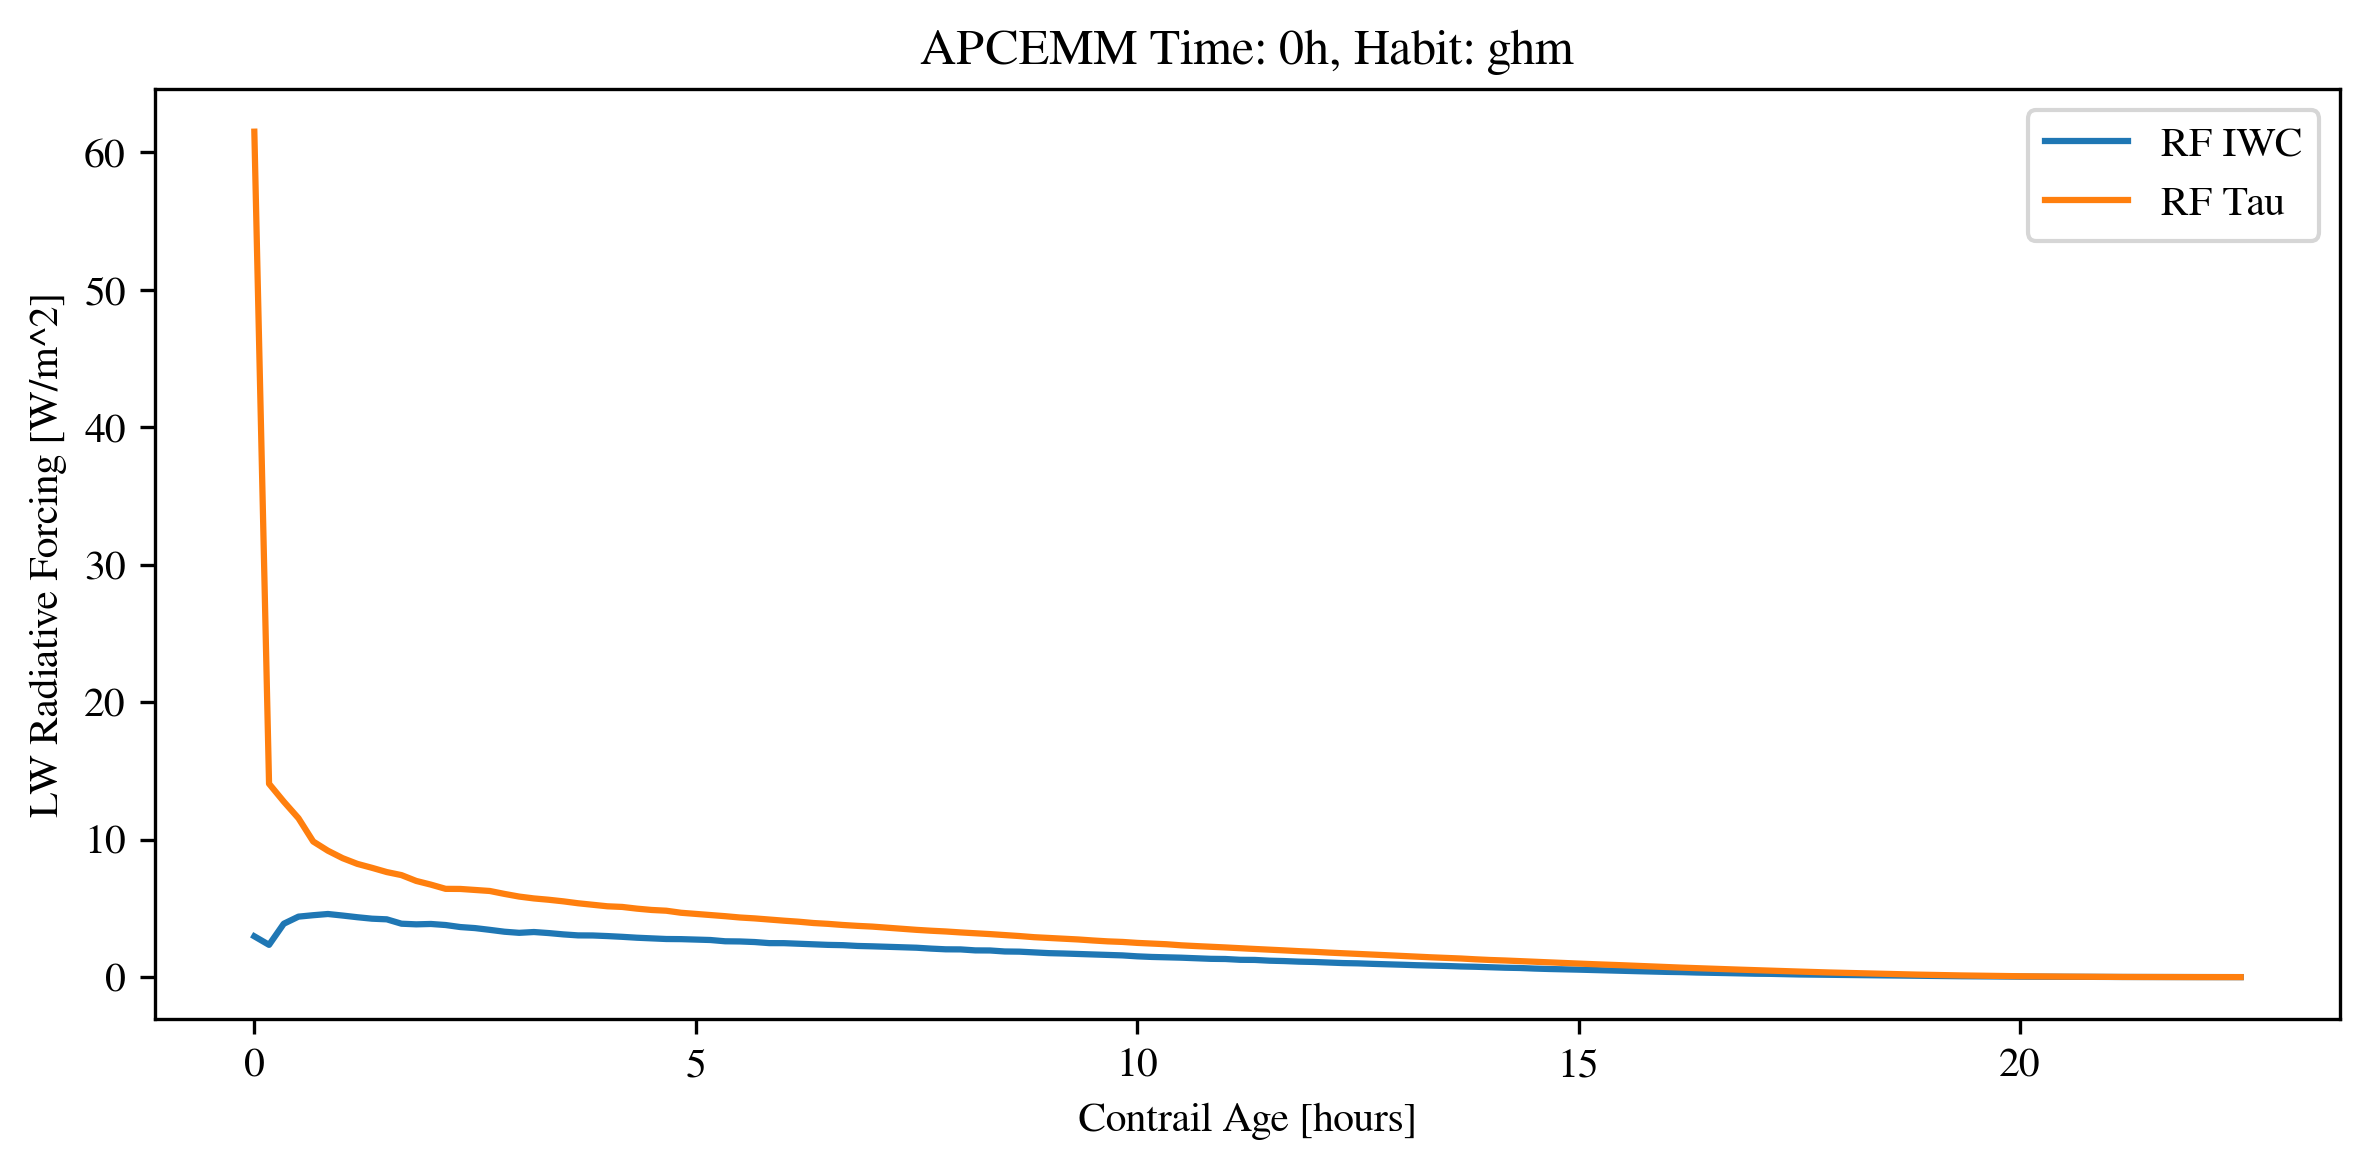

In [14]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)

for idx, hour in enumerate([0]):
    # Load IWC and non-IWC data for habit 'ghm'
    iwc_file = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/epm_bypass/110T218L25/LW_RF_APCEMM_ghm_{hour}h_IWC.csv"
    noniwc_file = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/epm_bypass/110T218L25/LW_RF_APCEMM_ghm_{hour}h.csv"

    iwc_df = pd.read_csv(iwc_file)
    noniwc_df = pd.read_csv(noniwc_file)

    ax.plot(iwc_df["Contrail_Age_hours"], iwc_df["LW_Radiative_Forcing_W_m2"], label="RF IWC", color="tab:blue")
    ax.plot(noniwc_df["Contrail_Age_hours"], noniwc_df["LW_Radiative_Forcing_W_m2"], label="RF Tau", color="tab:orange")
    ax.set_title(f"APCEMM Time: {hour}h, Habit: ghm")
    ax.set_xlabel("Contrail Age [hours]")
    ax.set_ylabel("LW Radiative Forcing [W/m^2]")
    ax.legend()


plt.tight_layout()
plt.show()

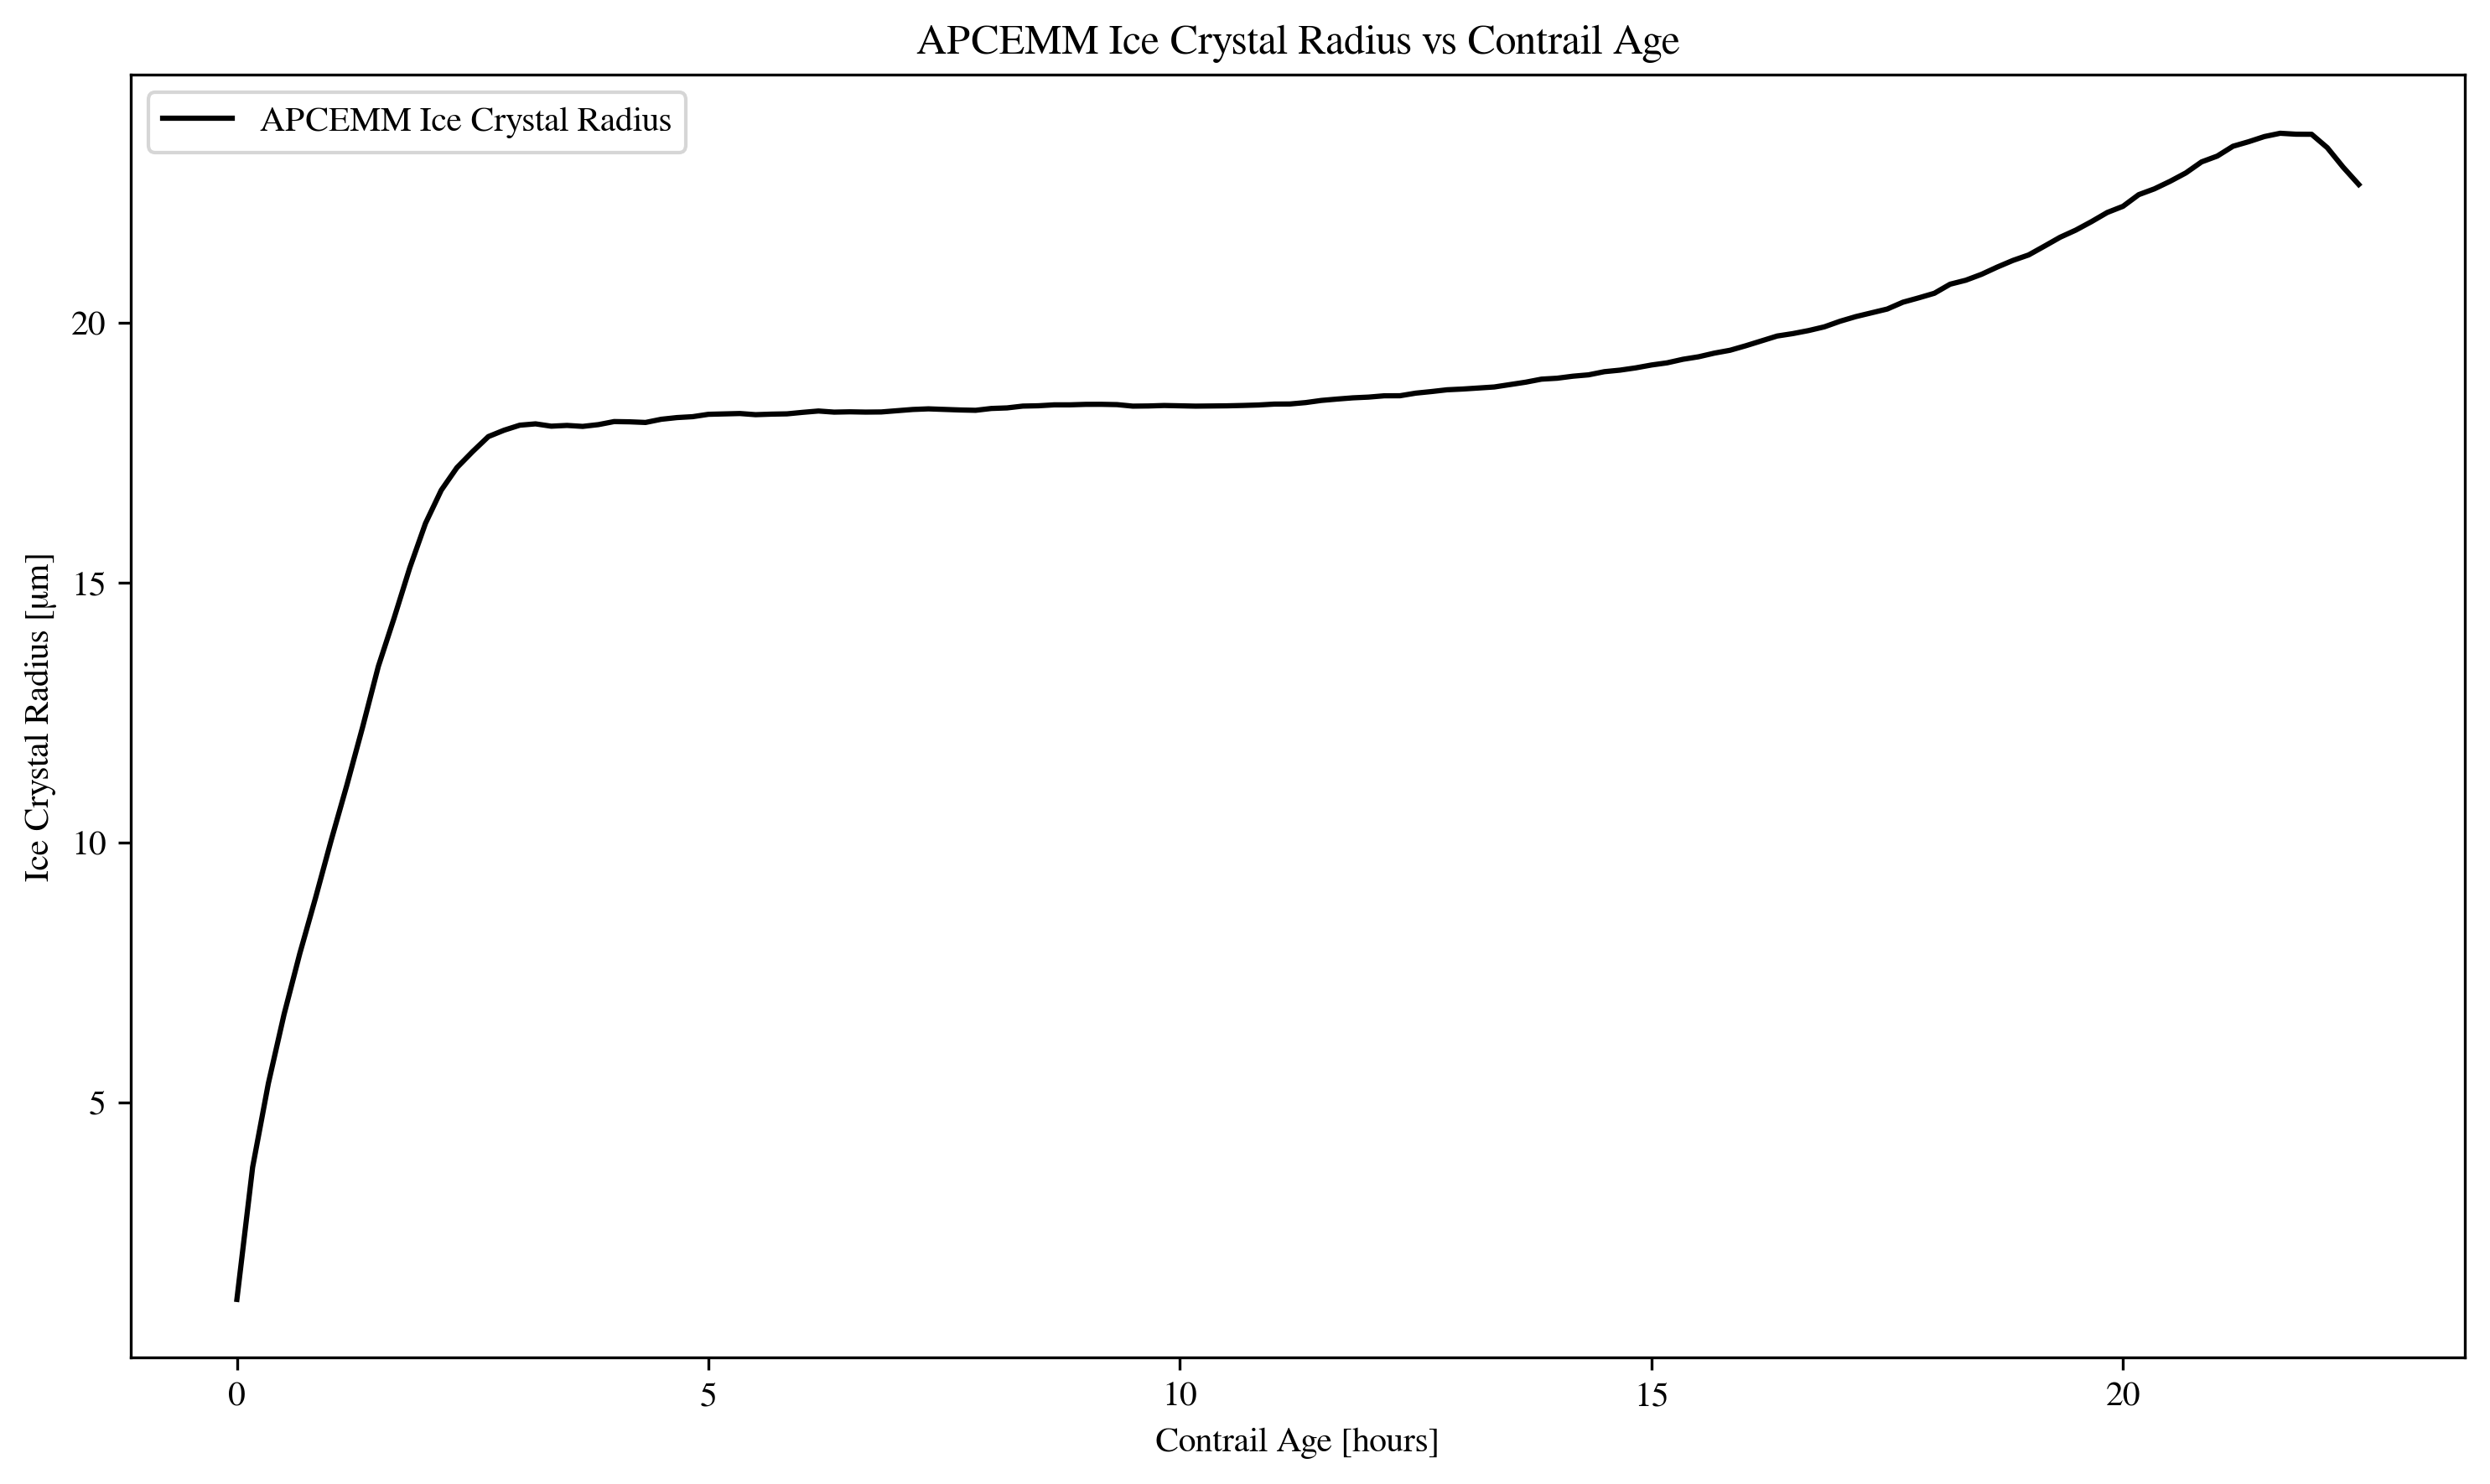

In [15]:
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(APCEMM_times, APCEMM_radii, label="APCEMM Ice Crystal Radius", color="black")
plt.xlabel("Contrail Age [hours]")
plt.ylabel("Ice Crystal Radius [μm]")
plt.title("APCEMM Ice Crystal Radius vs Contrail Age")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
pred_IWC = predict_IWC(218, 110)
print(f"Predicted IWC at 218K, 110% RHi: {pred_IWC:.5f} g/m³")

Predicted IWC at 218K, 110% RHi: 0.00208 g/m³


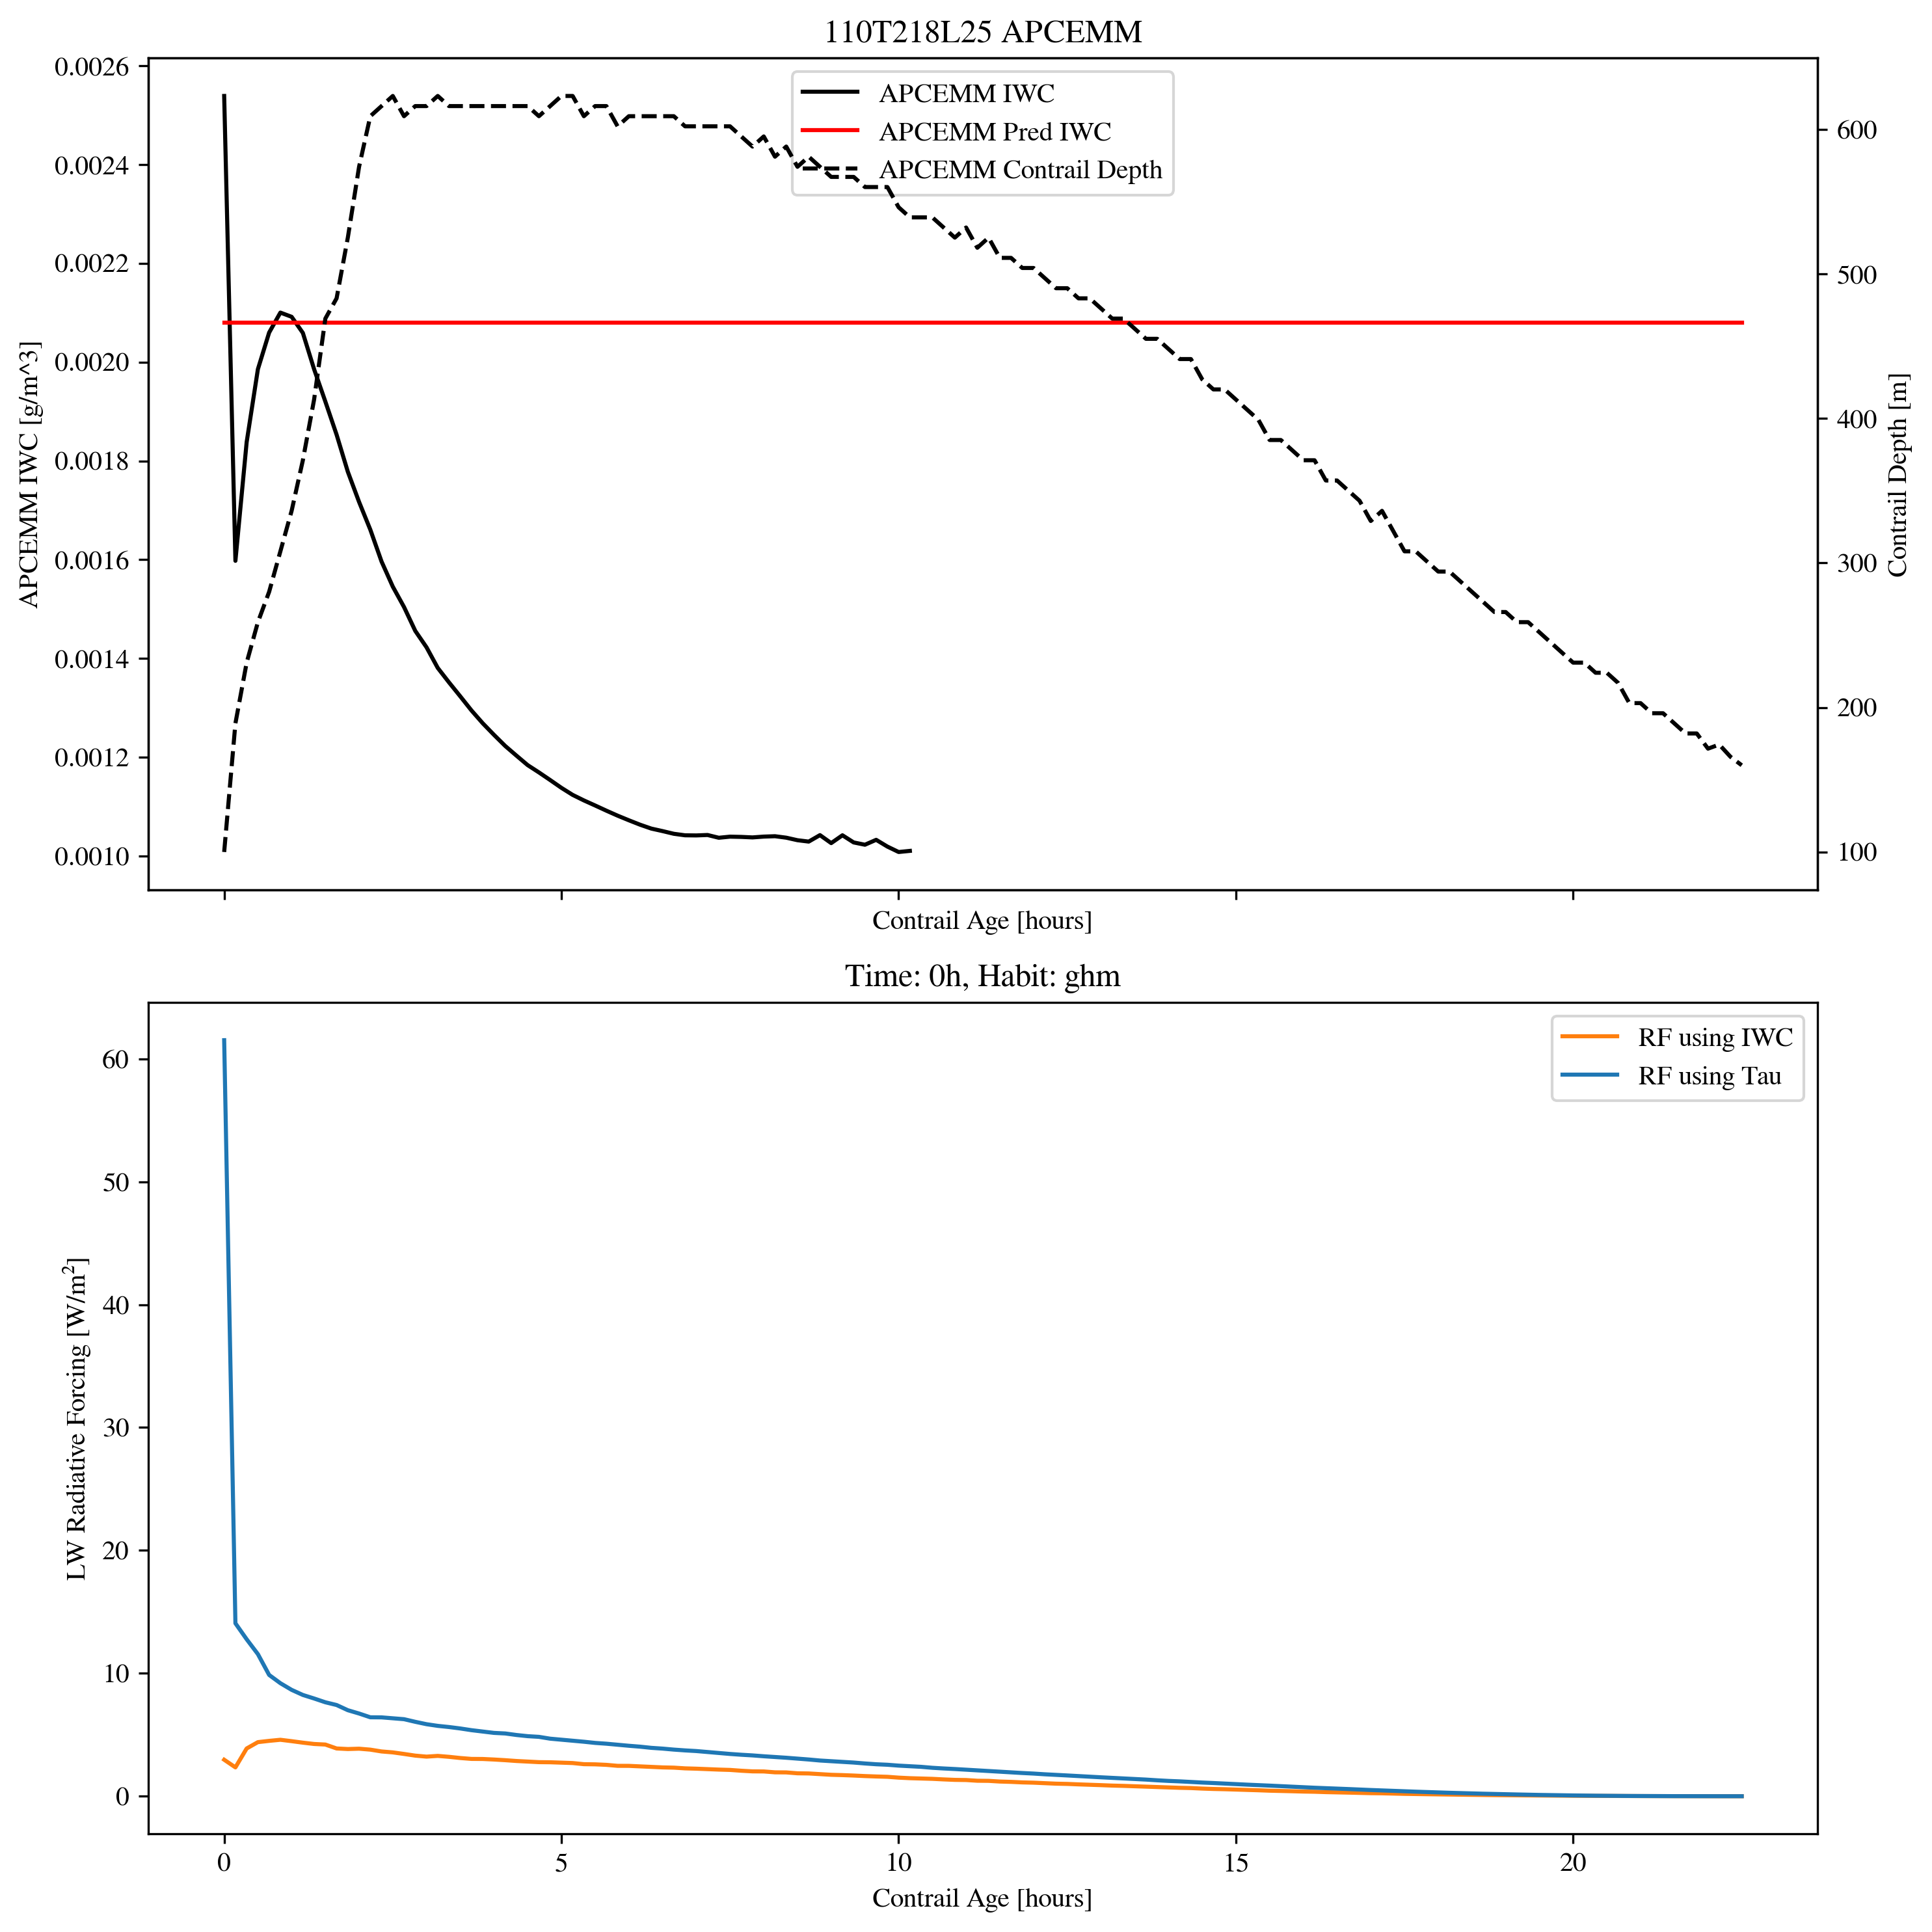

In [17]:
fig, axs = plt.subplots(2, 1, figsize=(10, 10), dpi=300, sharex=True)

# First plot: APCEMM IWC (average) with contrail depth
ax1 = axs[0]
ax1.plot(APCEMM_times, APCEMM_IWC_avg, label="APCEMM IWC", color="black", ls='-')
ax1.plot(APCEMM_times, [pred_IWC]*len(APCEMM_times), label="APCEMM Pred IWC", color="red", ls='-')
ax1.set_xlabel("Contrail Age [hours]")
ax1.set_ylabel("APCEMM IWC [g/m^3]", color="black")
ax1.tick_params(axis='y', labelcolor="black")
ax1.set_title(f'{test_id} APCEMM')

# Second y-axis for contrail depth
ax2 = ax1.twinx()
ax2.plot(APCEMM_times, APCEMM_depth, label="APCEMM Contrail Depth", color="black", ls='--')
ax2.set_ylabel("Contrail Depth [m]", color="black")
ax2.tick_params(axis='y', labelcolor="black")

# Legends for first plot
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper center")

# Second plot: IWC and non-IWC RF
ax = axs[1]
for idx, hour in enumerate([0]):
    iwc_file = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/epm_bypass/110T218L25/LW_RF_APCEMM_ghm_{hour}h_IWC.csv"
    noniwc_file = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/epm_bypass/110T218L25/LW_RF_APCEMM_ghm_{hour}h.csv"
    iwc_df = pd.read_csv(iwc_file)
    noniwc_df = pd.read_csv(noniwc_file)
    ax.plot(iwc_df["Contrail_Age_hours"], iwc_df["LW_Radiative_Forcing_W_m2"], label="RF using IWC", color="tab:orange")
    ax.plot(noniwc_df["Contrail_Age_hours"], noniwc_df["LW_Radiative_Forcing_W_m2"], label="RF using Tau", color="tab:blue")
ax.set_title(f"Time: {hour}h, Habit: ghm")
ax.set_xlabel("Contrail Age [hours]")
ax.set_ylabel("LW Radiative Forcing [W/m²]")
ax.legend()

plt.tight_layout()
plt.show()


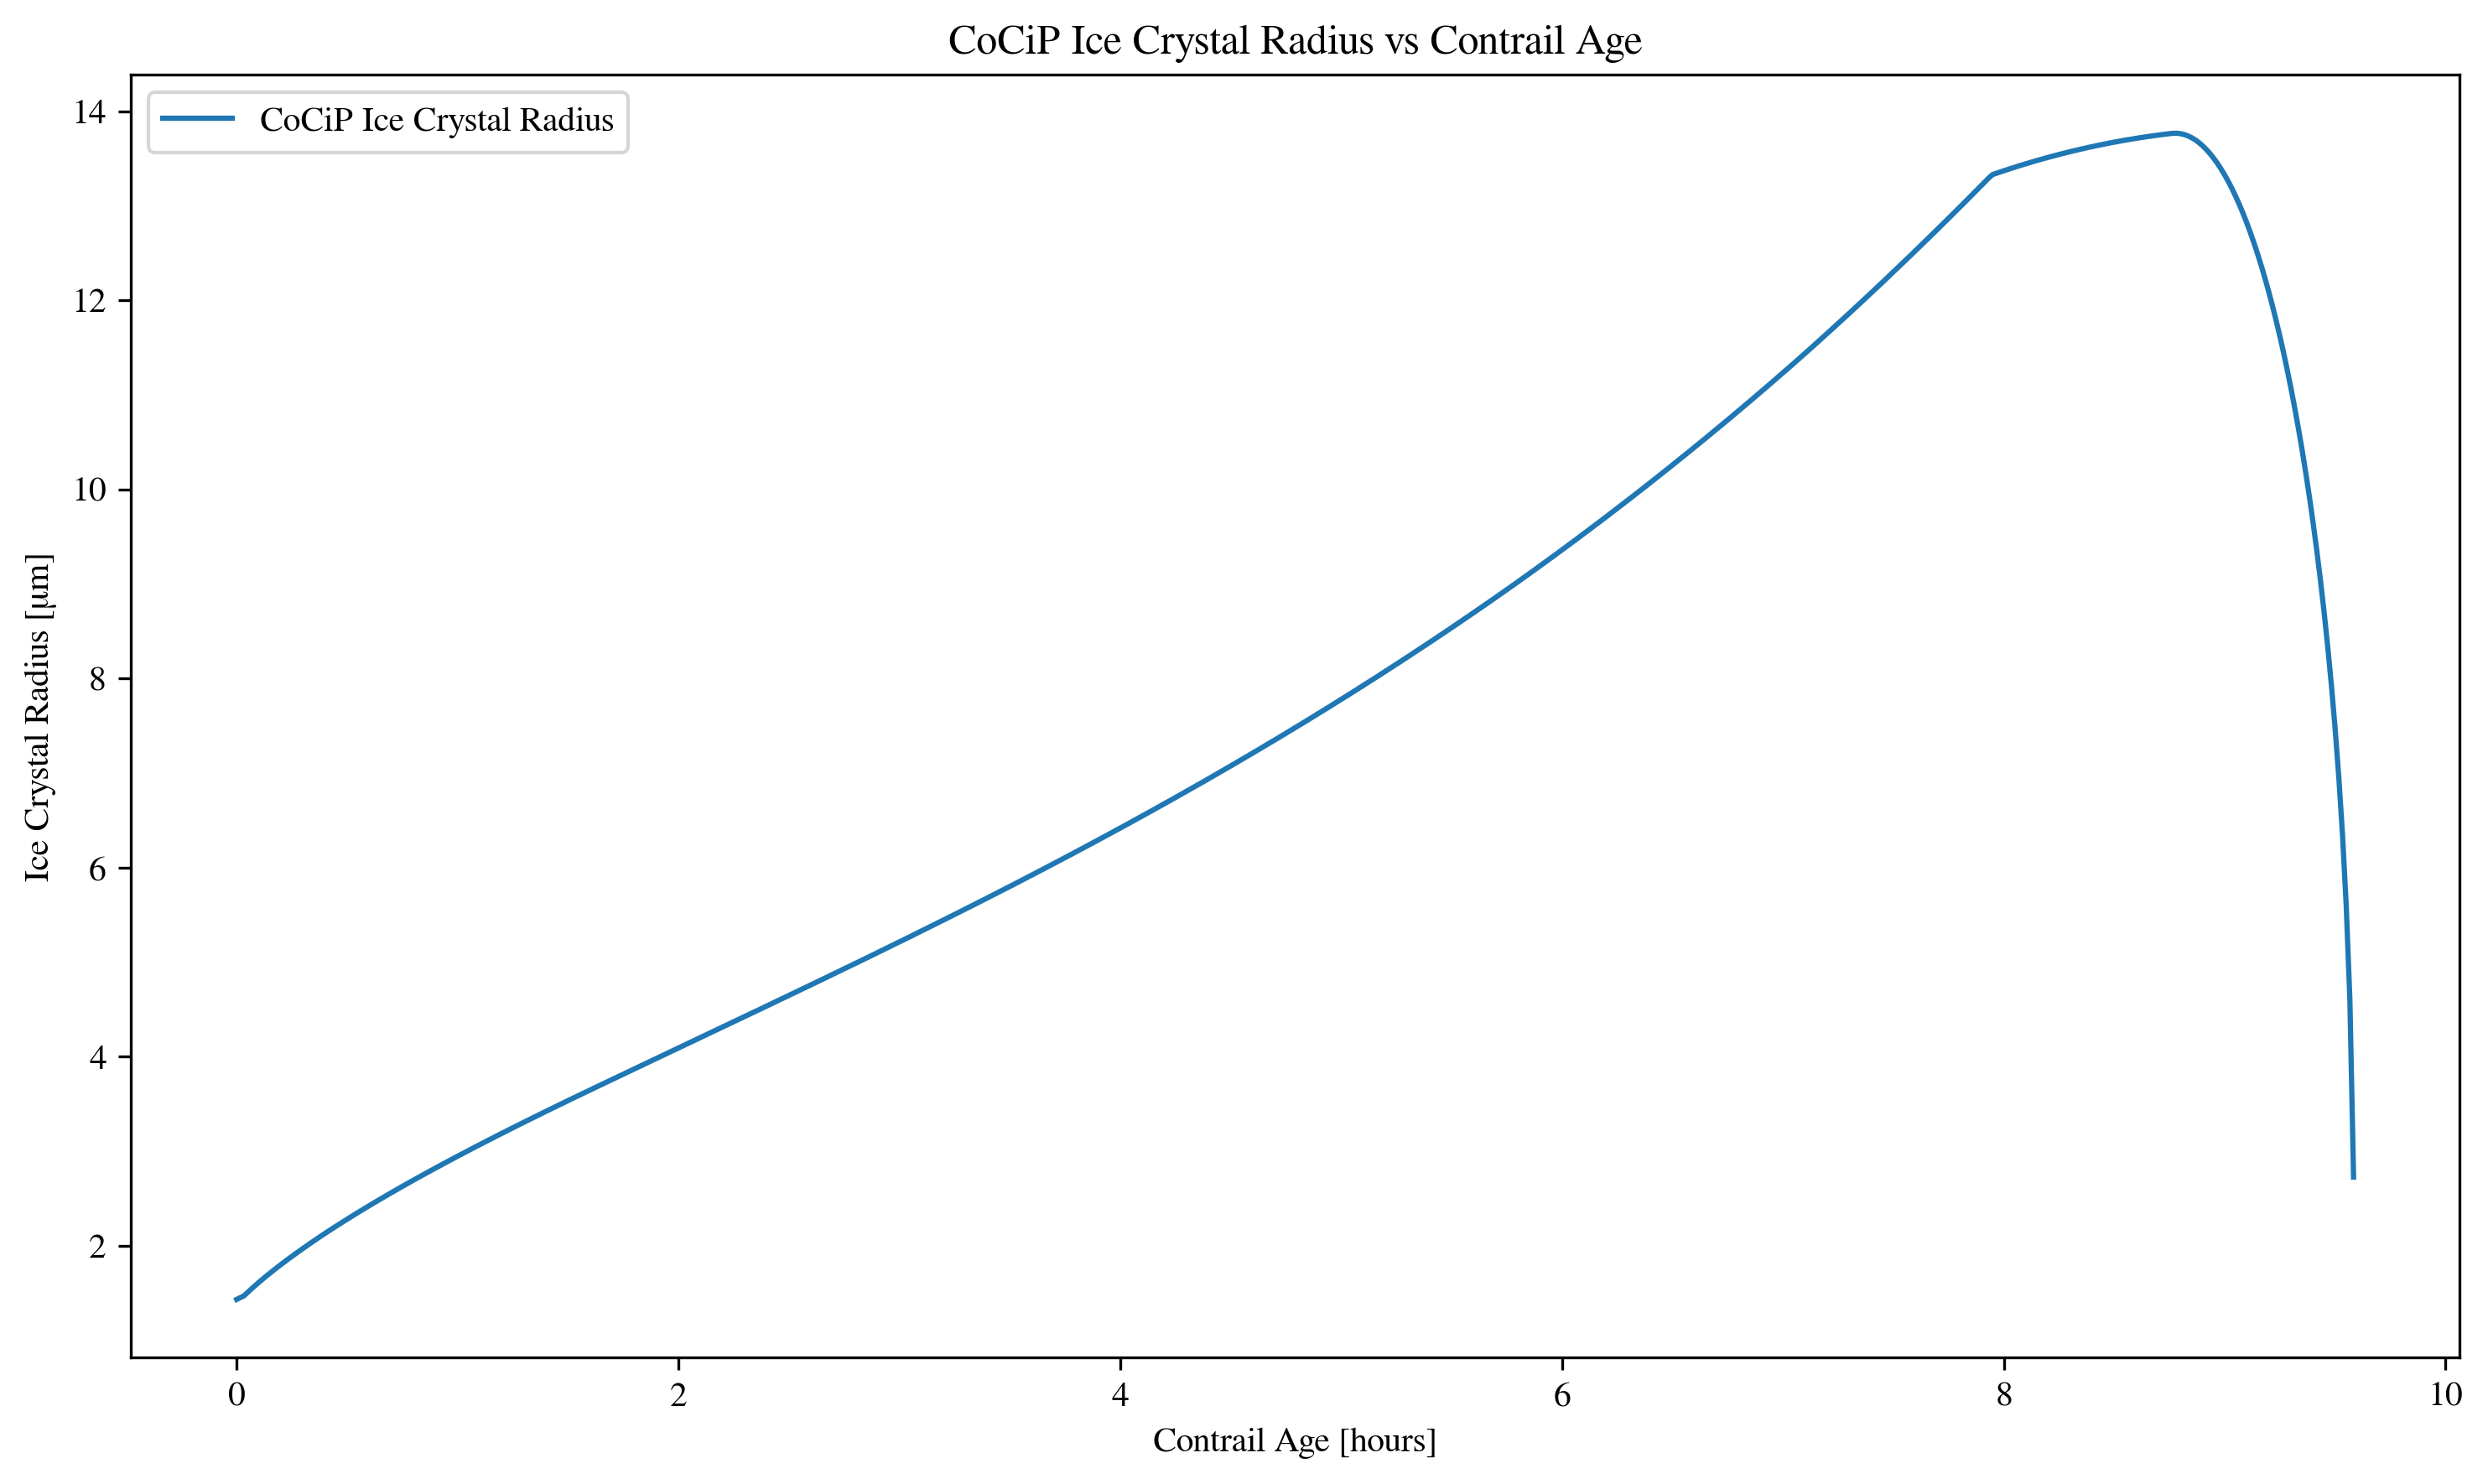

In [18]:
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(cocip_times, cocip_radii, label="CoCiP Ice Crystal Radius", color="tab:blue")
plt.xlabel("Contrail Age [hours]")
plt.ylabel("Ice Crystal Radius [μm]")
plt.title("CoCiP Ice Crystal Radius vs Contrail Age")
plt.legend()
plt.tight_layout()
plt.show()

## CoCiP IWC vs Tau vs Internal RF

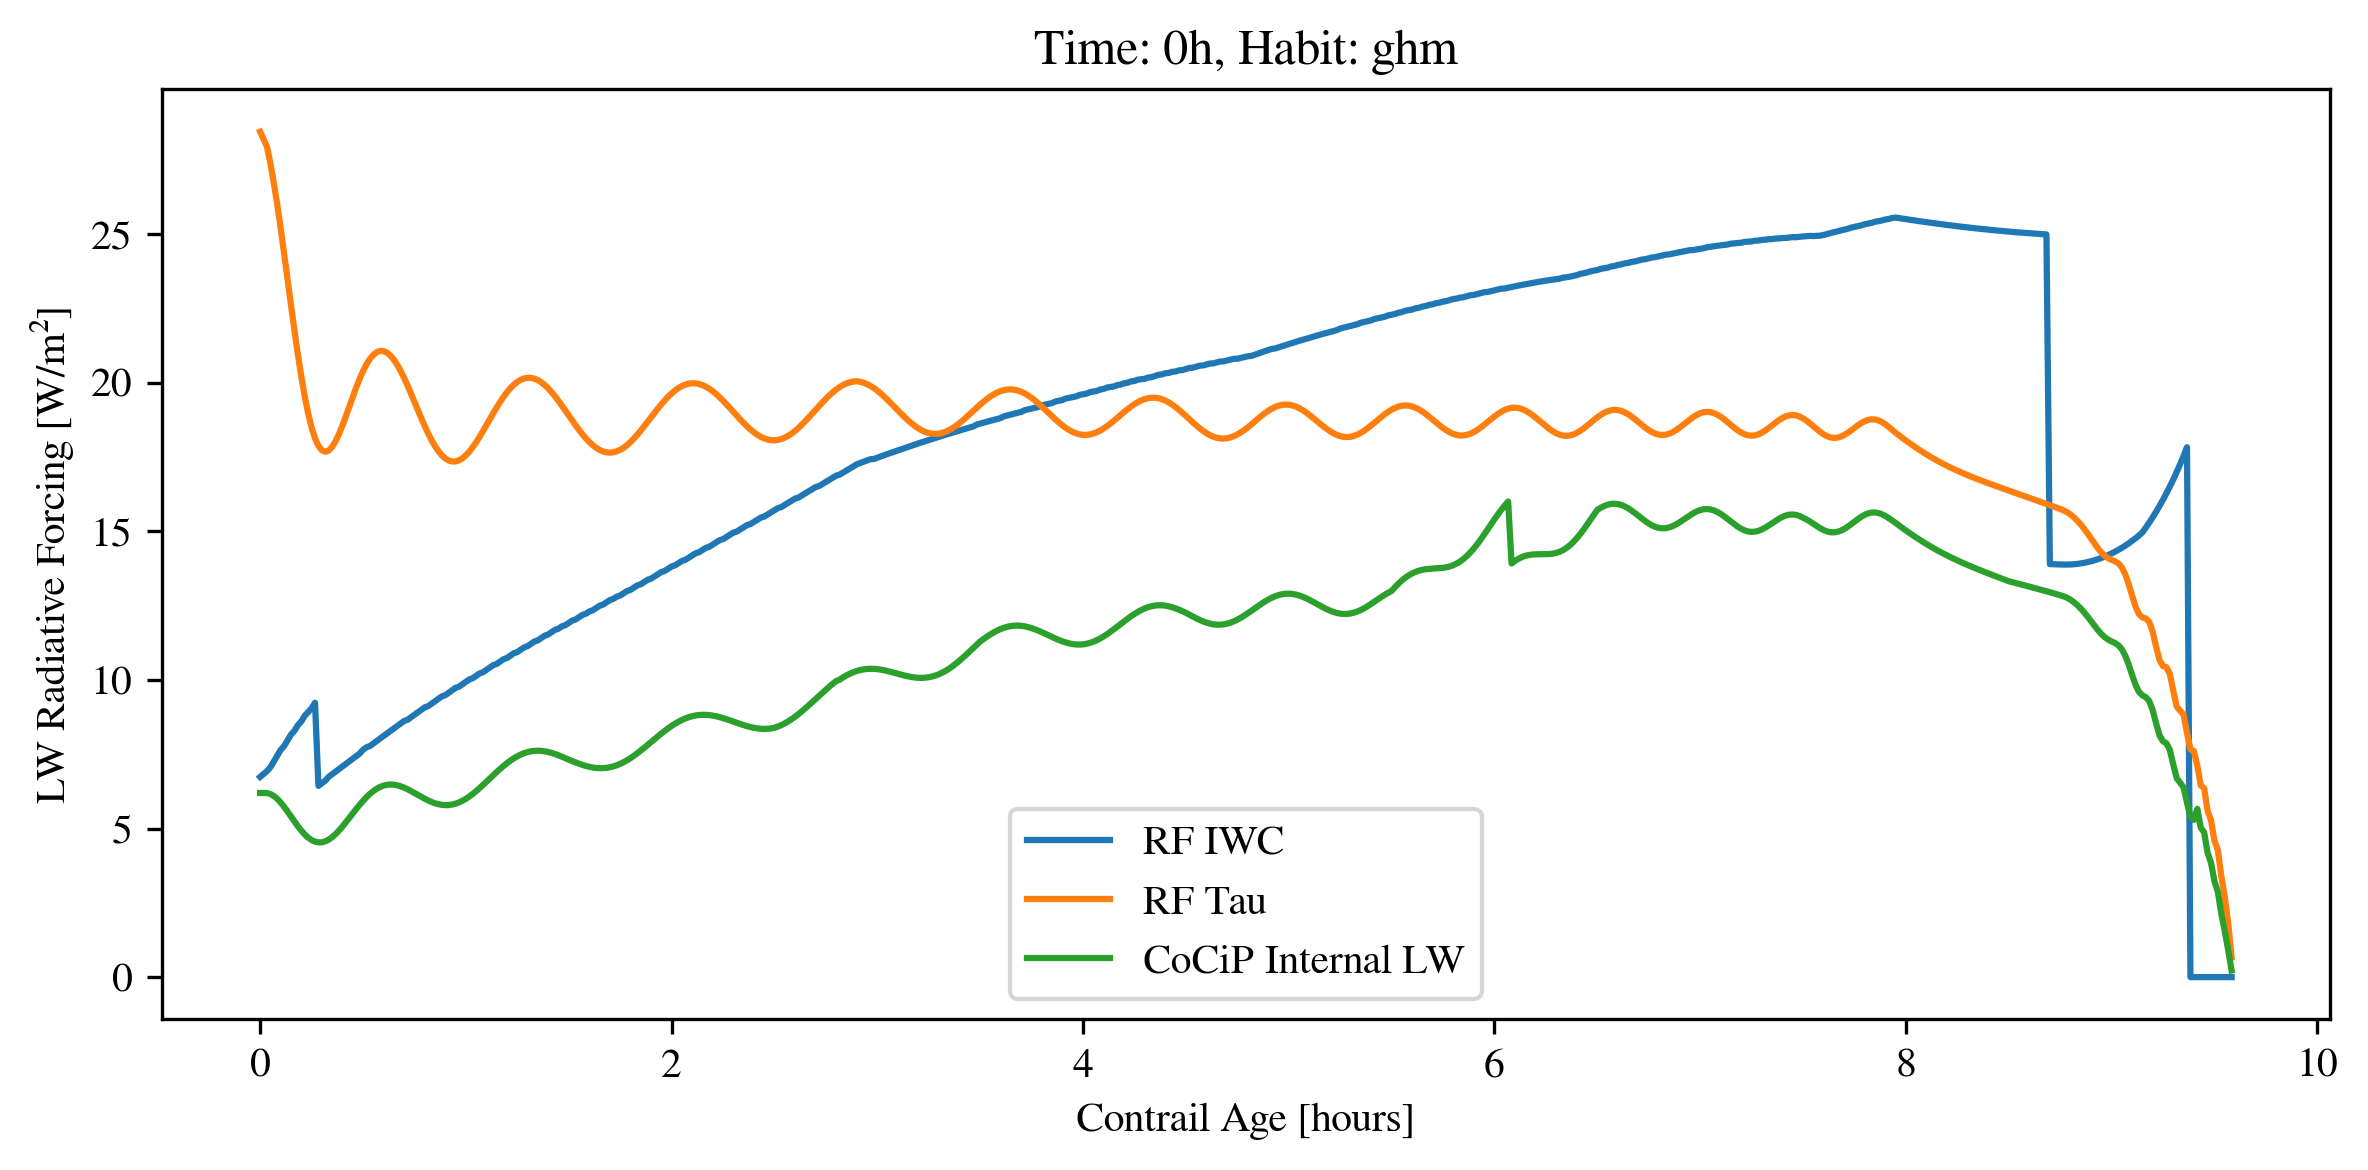

In [19]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)

for idx, hour in enumerate([0]):
    # Load IWC and non-IWC data for habit 'ghm'
    iwc_file = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T218L25/testing/LW_RF_cocip_ghm_{hour}h_IWC.csv"
    noniwc_file = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T218L25/testing/LW_RF_cocip_ghm_{hour}h.csv"

    iwc_df = pd.read_csv(iwc_file)
    noniwc_df = pd.read_csv(noniwc_file)

    ax.plot(iwc_df["Contrail_Age_hours"], iwc_df["LW_Radiative_Forcing_W_m2"], label="RF IWC", color="tab:blue")
    ax.plot(noniwc_df["Contrail_Age_hours"], noniwc_df["LW_Radiative_Forcing_W_m2"], label="RF Tau", color="tab:orange")
    ax.plot(cocip_times,cocip_internal_RF_LW, label="CoCiP Internal LW", color="tab:green")
    ax.set_title(f"Time: {hour}h, Habit: ghm")
    ax.set_xlabel("Contrail Age [hours]")
    ax.set_ylabel("LW Radiative Forcing [W/m²]")
    ax.legend()

plt.tight_layout()
plt.show()

## CoCiP Investigative Plots

In [20]:
# Import cocip met file
cocip_met = xr.open_dataset("/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T218L25/110T218L25-met.nc")
cocip_met

<xarray.Dataset>
Dimensions:                              (longitude: 1440, latitude: 161,
                                          level: 125, time: 60)
Coordinates:
  * longitude                            (longitude) float64 -180.0 ... 179.8
  * latitude                             (latitude) float64 30.0 30.25 ... 70.0
  * level                                (level) float64 181.5 ... 1.013e+03
  * time                                 (time) datetime64[ns] 2023-01-01 ......
    altitude                             (level) float32 ...
    air_pressure                         (level) float64 ...
Data variables:
    air_temperature                      (longitude, latitude, level, time) float32 ...
    specific_humidity                    (longitude, latitude, level, time) float32 ...
    eastward_wind                        (longitude, latitude, level, time) float32 ...
    northward_wind                       (longitude, latitude, level, time) float32 ...
    lagrangian_tendency_of_air_pressure  (longitude, latitude, level, time) float32 ...
    specific_cloud_ice_water_content     (longitude, latitude, level, time) float32 ...
    relative_humidity                    (longitude, latitude, level, time) float32 ...

In [21]:
cocip_specific_humidity = cocip_met['specific_humidity'][0][0][:][0].values  # [kg/kg]

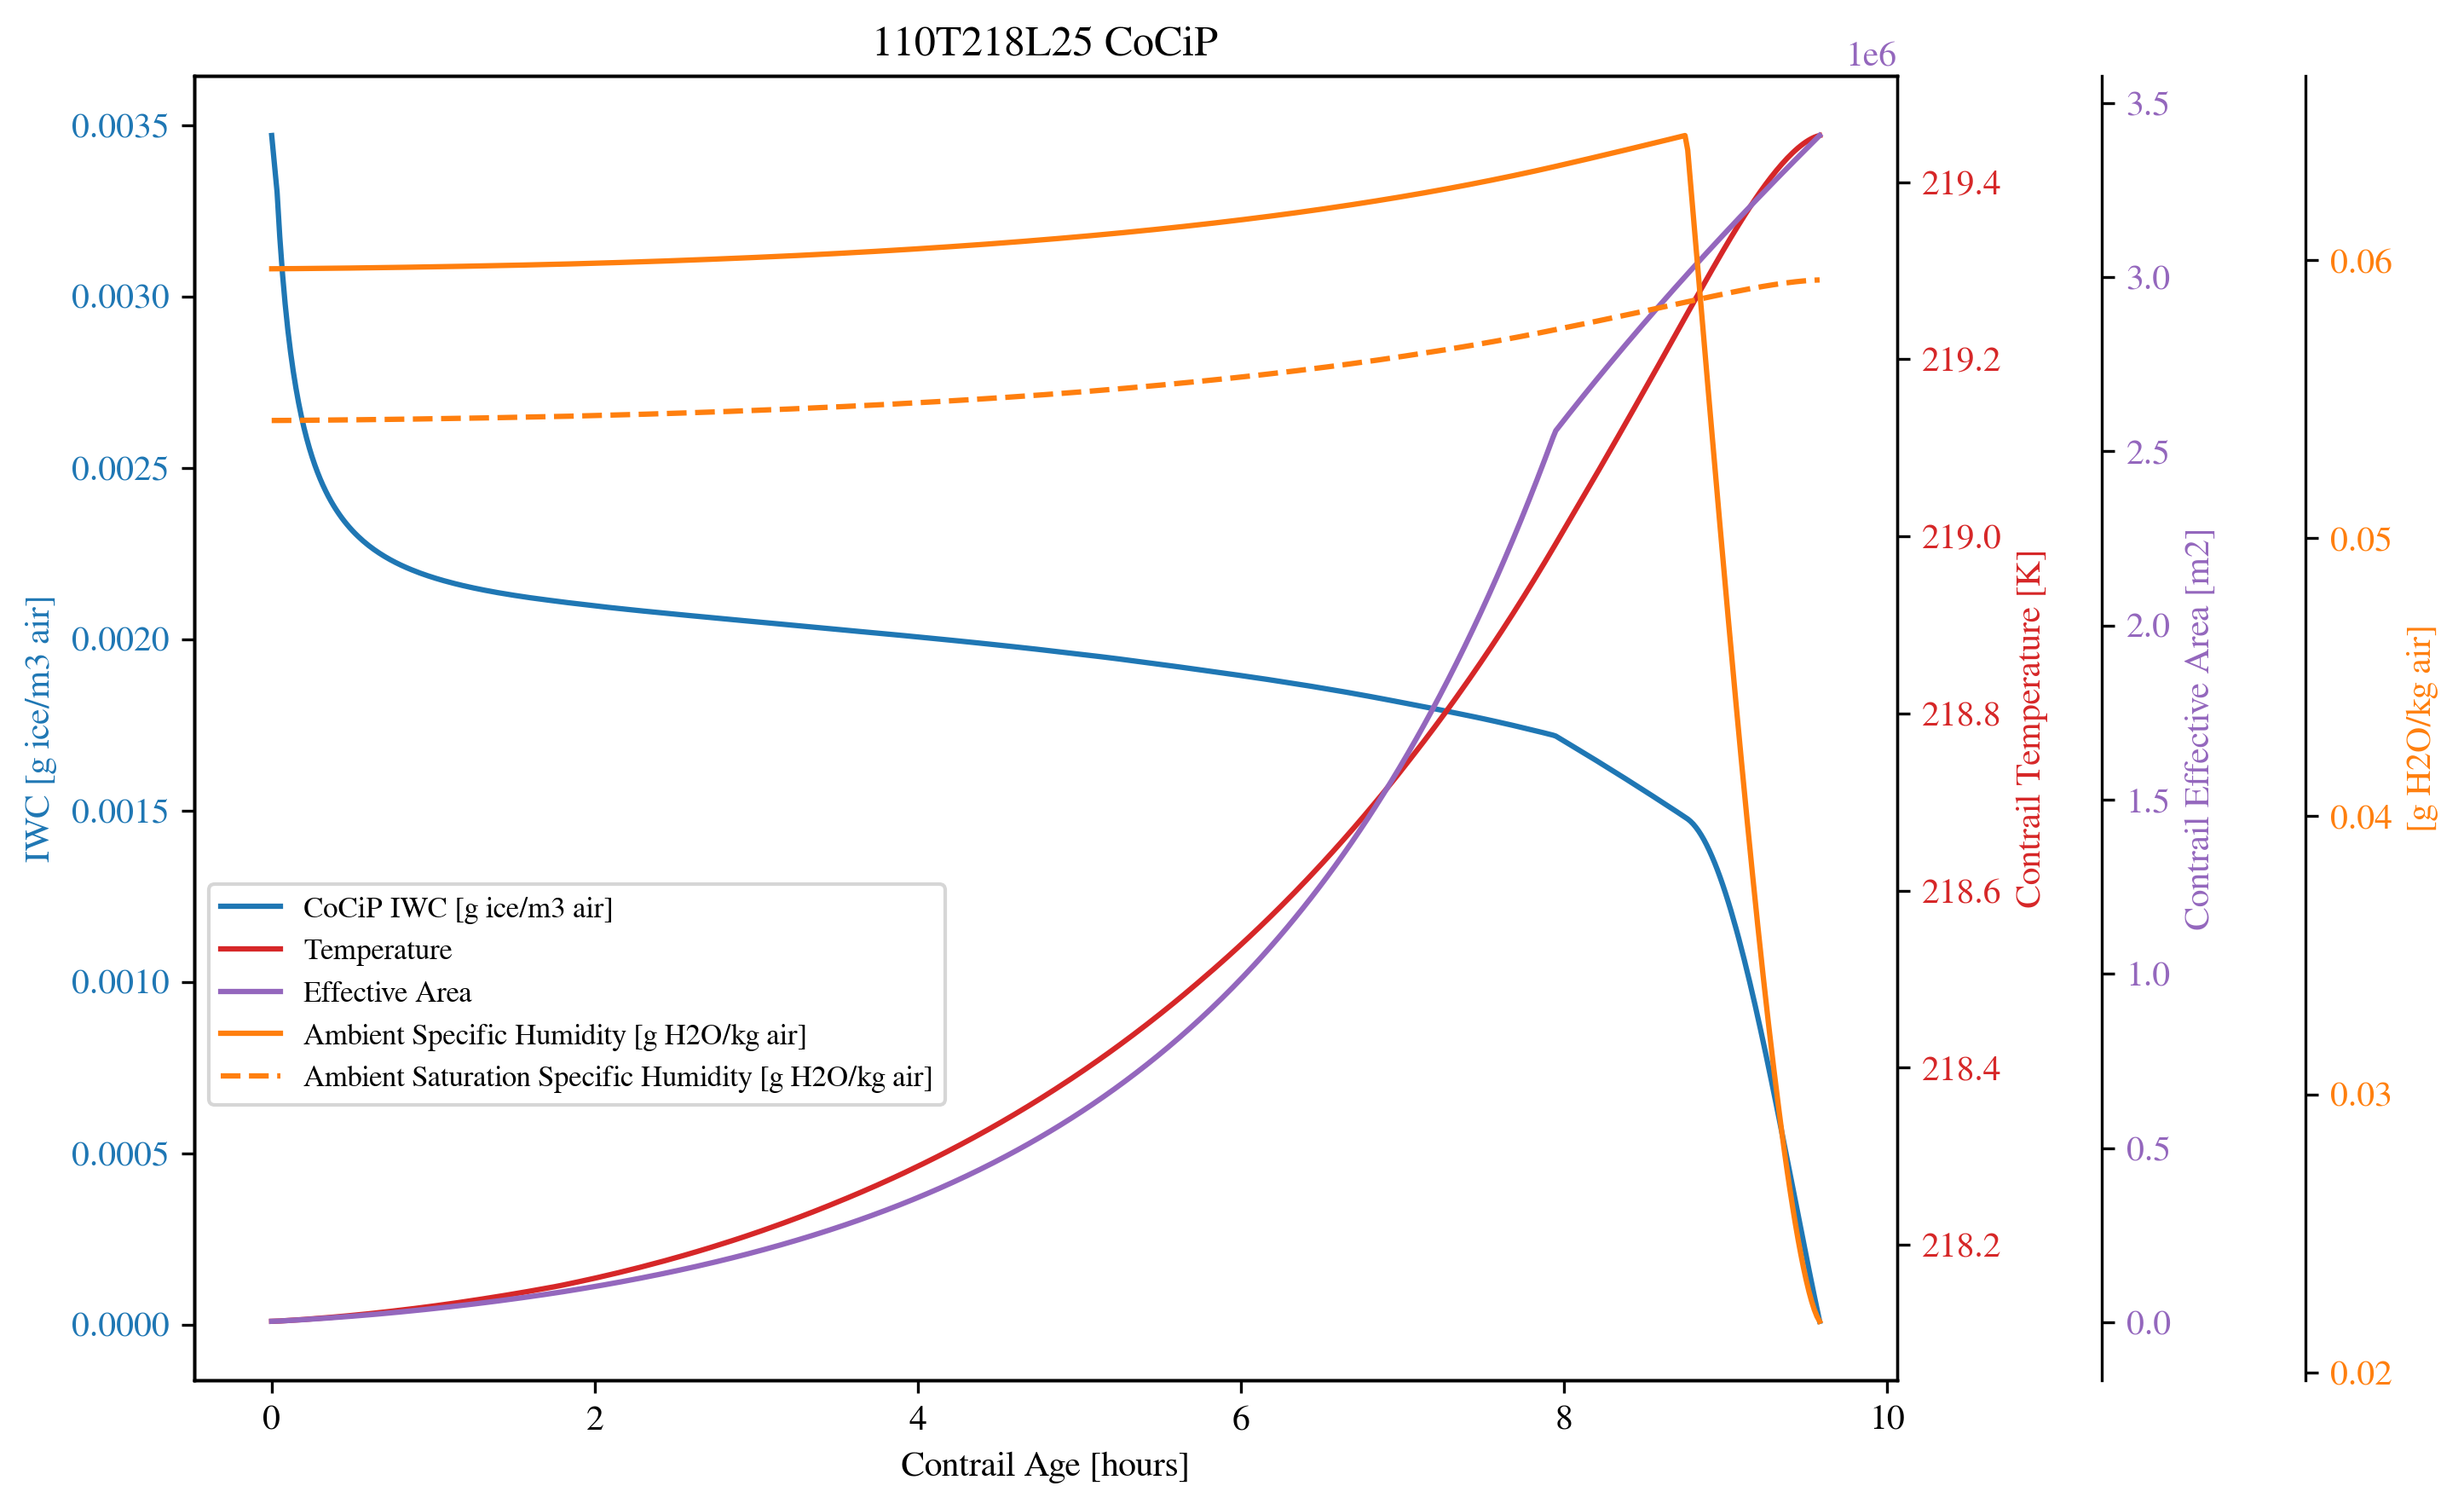

In [22]:
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)

# Plot CoCiP IWC
ax1.plot(cocip_ds["age_hours"], cocip_iwc, label="CoCiP IWC [g ice/m3 air]", color="tab:blue")
ax1.set_xlabel("Contrail Age [hours]")
ax1.set_ylabel("IWC [g ice/m3 air]", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.set_title(f'{test_id} CoCiP')

# Second y-axis for contrail temperature (offset to the right)
ax2 = ax1.twinx()
ax2.spines["right"].set_position(("axes", 1))
ax2.plot(cocip_times, cocip_temperature, label="Temperature", color="tab:red")
ax2.set_ylabel("Contrail Temperature [K]", color="tab:red")
ax2.tick_params(axis='y', labelcolor="tab:red")

# Third y-axis for contrail effective area (further offset)
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.12))
ax3.plot(cocip_times, cocip_area_eff, label="Effective Area", color="tab:purple")
ax3.set_ylabel("Contrail Effective Area [m2]", color="tab:purple")
ax3.tick_params(axis='y', labelcolor="tab:purple")

ax4 = ax1.twinx()
ax4.spines["right"].set_position(("axes", 1.24))
ax4.plot(cocip_times, cocip_q * 1e3, label="Ambient Specific Humidity [g H2O/kg air]", color="tab:orange")
ax4.plot(cocip_times, cocip_qsat * 1e3, label="Ambient Saturation Specific Humidity [g H2O/kg air]", color="tab:orange", ls='--')
ax4.set_ylabel("[g H2O/kg air]", color="tab:orange")
ax4.tick_params(axis='y', labelcolor="tab:orange")

# Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
lines_3, labels_3 = ax3.get_legend_handles_labels()
lines_4, labels_4 = ax4.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2 + lines_3 + lines_4, labels_1 + labels_2 + labels_3 + labels_4, loc="lower left", bbox_to_anchor=(0, 0.2), fontsize="small")

plt.tight_layout()
plt.show()

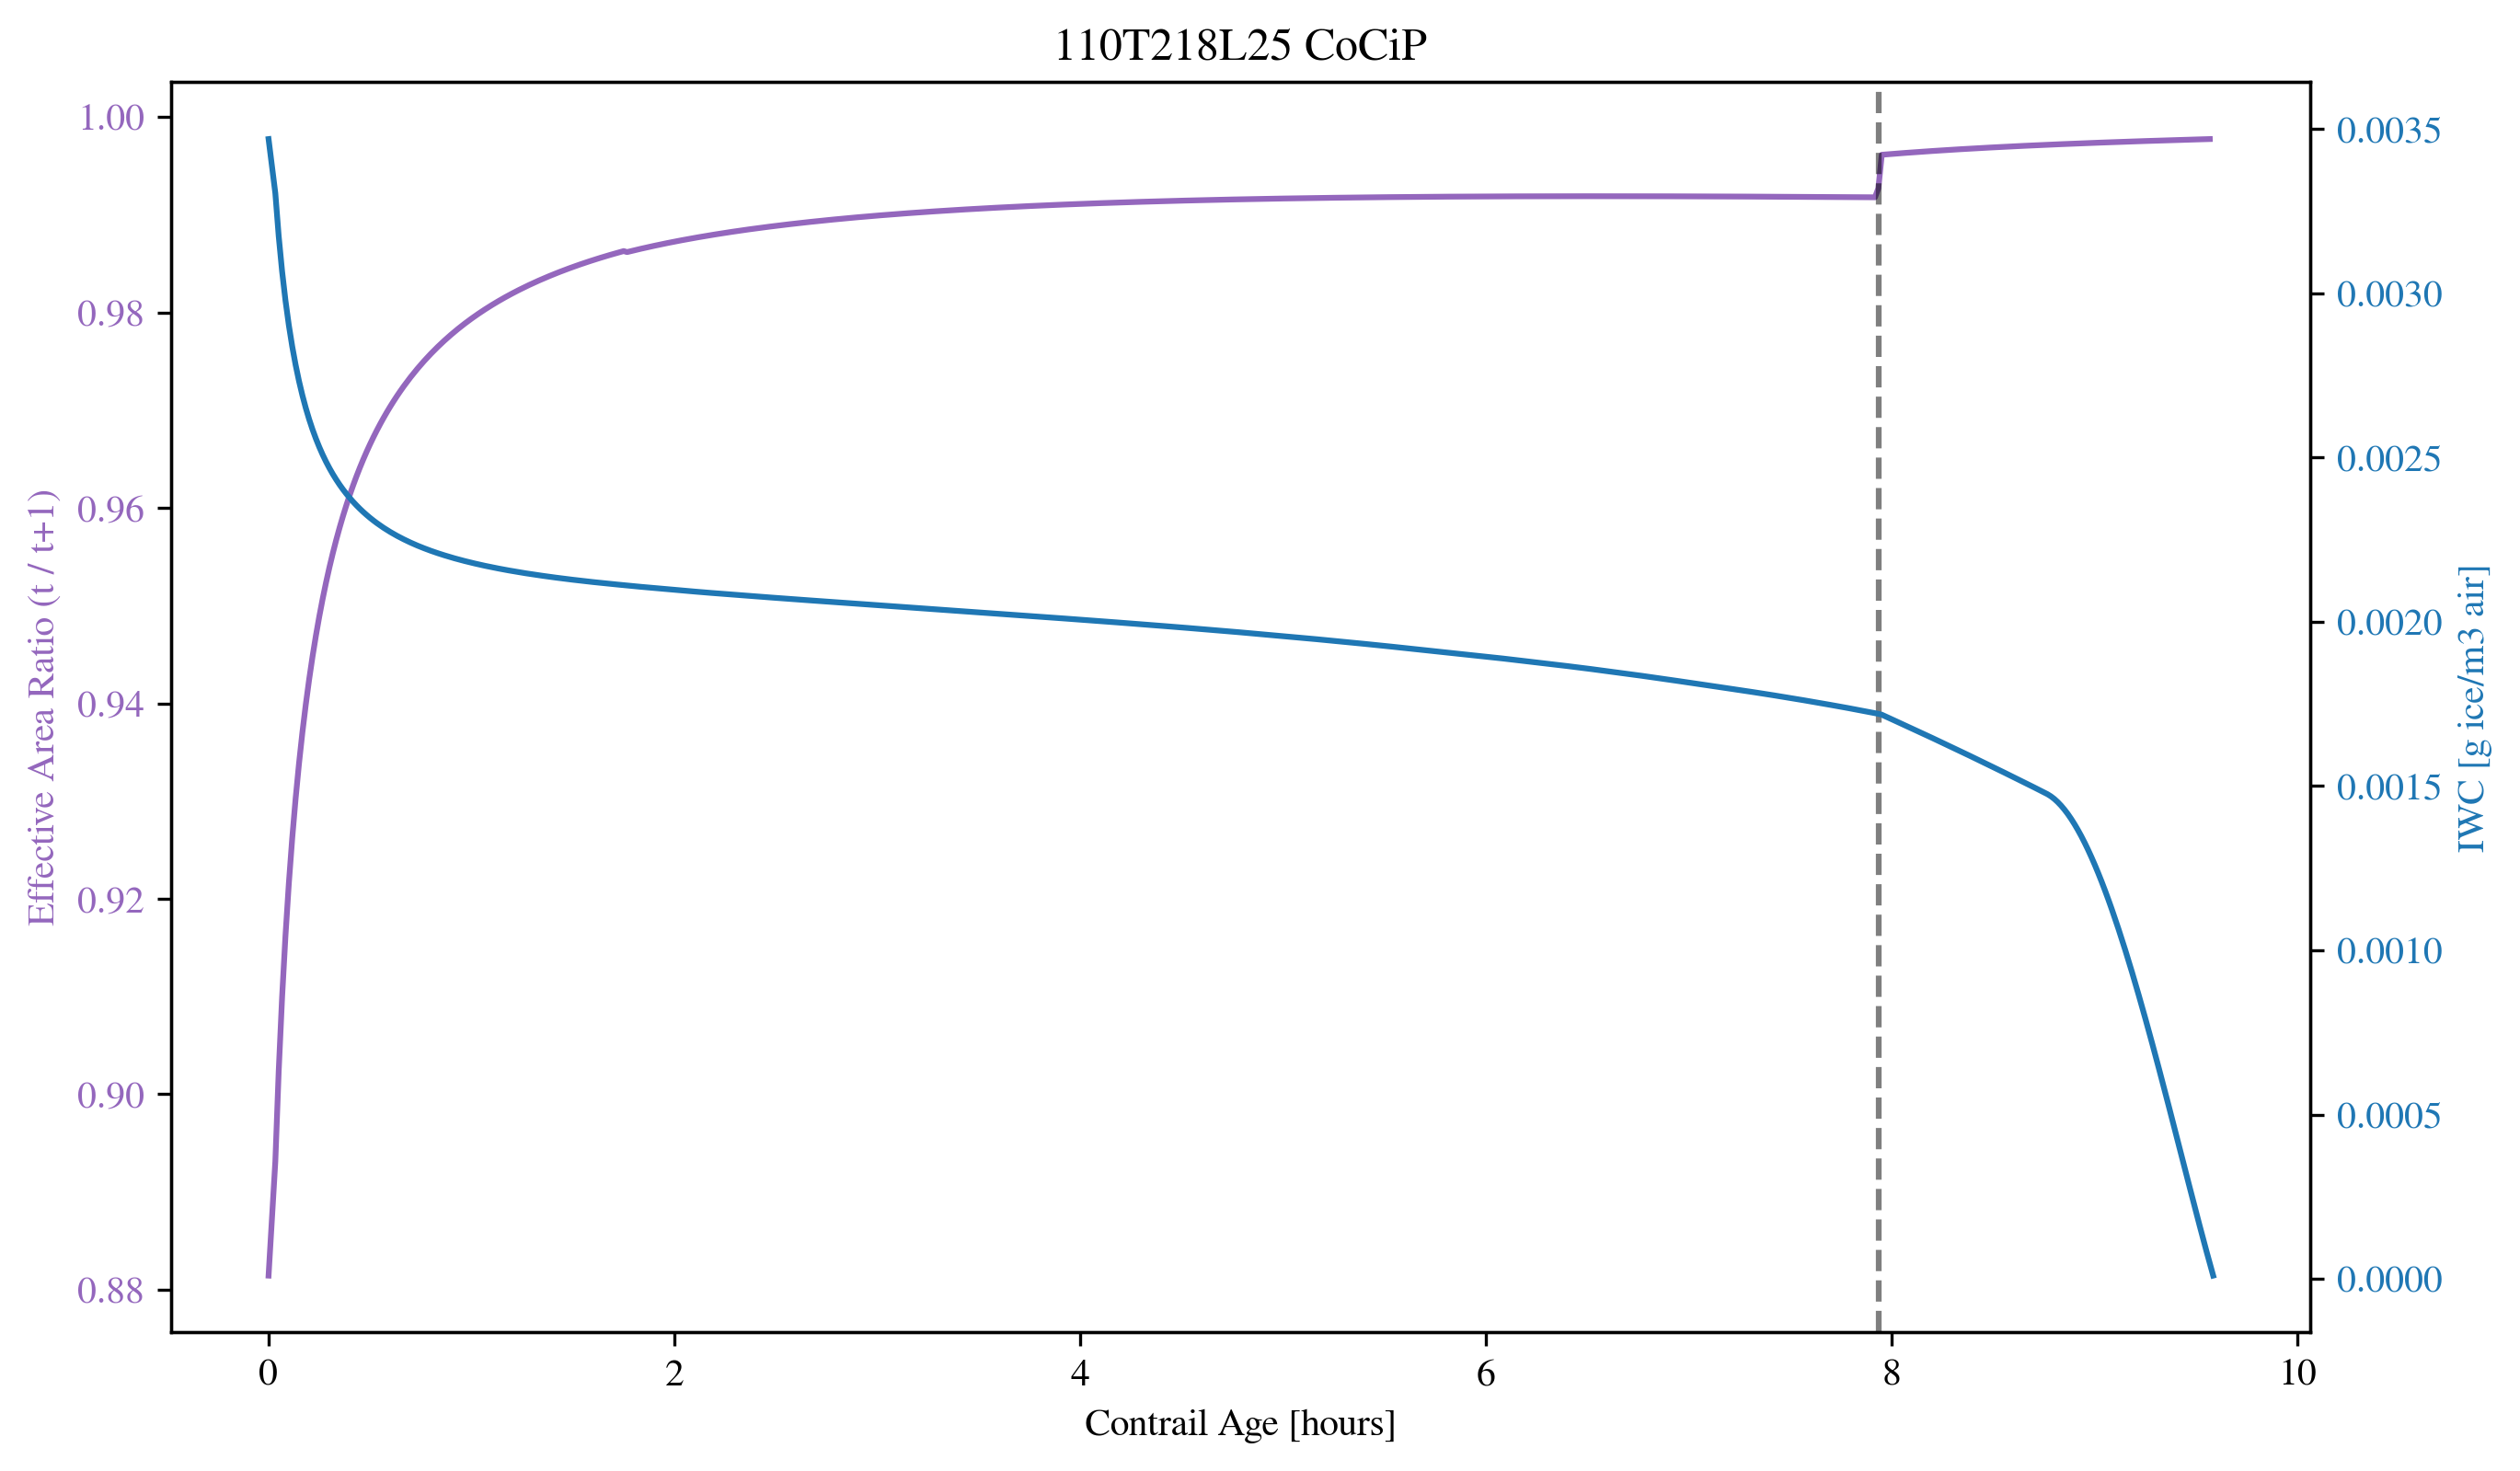

In [23]:
Aeff_ratios = np.zeros(len(cocip_times)-1)
for i in range(len(cocip_times)-1):
    Aeff_1 = cocip_area_eff[i]
    Aeff_2 = cocip_area_eff[i+1]

    Aeff_ratios[i] = Aeff_1/Aeff_2

fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)
ax1.plot(cocip_times[:-1], Aeff_ratios, label="Aeff Ratios", color="tab:purple")
ax1.set_ylabel("Effective Area Ratio (t / t+1)", color="tab:purple")
ax1.tick_params(axis='y', labelcolor="tab:purple")

ax1.set_title(f'{test_id} CoCiP')
ax1.set_xlabel("Contrail Age [hours]")

ax2 = ax1.twinx()
ax2.plot(cocip_times, cocip_iwc, label="CoCiP IWC [g ice/m3 air]", color="tab:blue")
ax2.set_ylabel("IWC [g ice/m3 air]", color="tab:blue")
ax2.tick_params(axis='y', labelcolor="tab:blue")
ax1.axvline(476/60, color='black', linestyle='--', alpha=0.5, label="Centroid at subsat layer")


In [24]:
# Calculate the slope (difference) of cocip_depth
depth_slope = np.diff(cocip_depth)

# Find indices where the slope is exactly zero
zero_slope_indices = np.where(depth_slope == 0)[0]

print("Indices where cocip_depth slope is 0:", zero_slope_indices)

Indices where cocip_depth slope is 0: [476 477 478 479 480 481 482 483 484 485 486 487 488 489 490 491 492 493
 494 495 496 497 498 499 500 501 502 503 504 505 506 507 508 509 510 511
 512 513 514 515 516 517 518 519 520 521 522 523 524 525 526 527 528 529
 530 531 532 533 534 535 536 537 538 539 540 541 542 543 544 545 546 547
 548 549 550 551 552 553 554 555 556 557 558 559 560 561 562 563 564 565
 566 567 568 569 570 571 572 573]


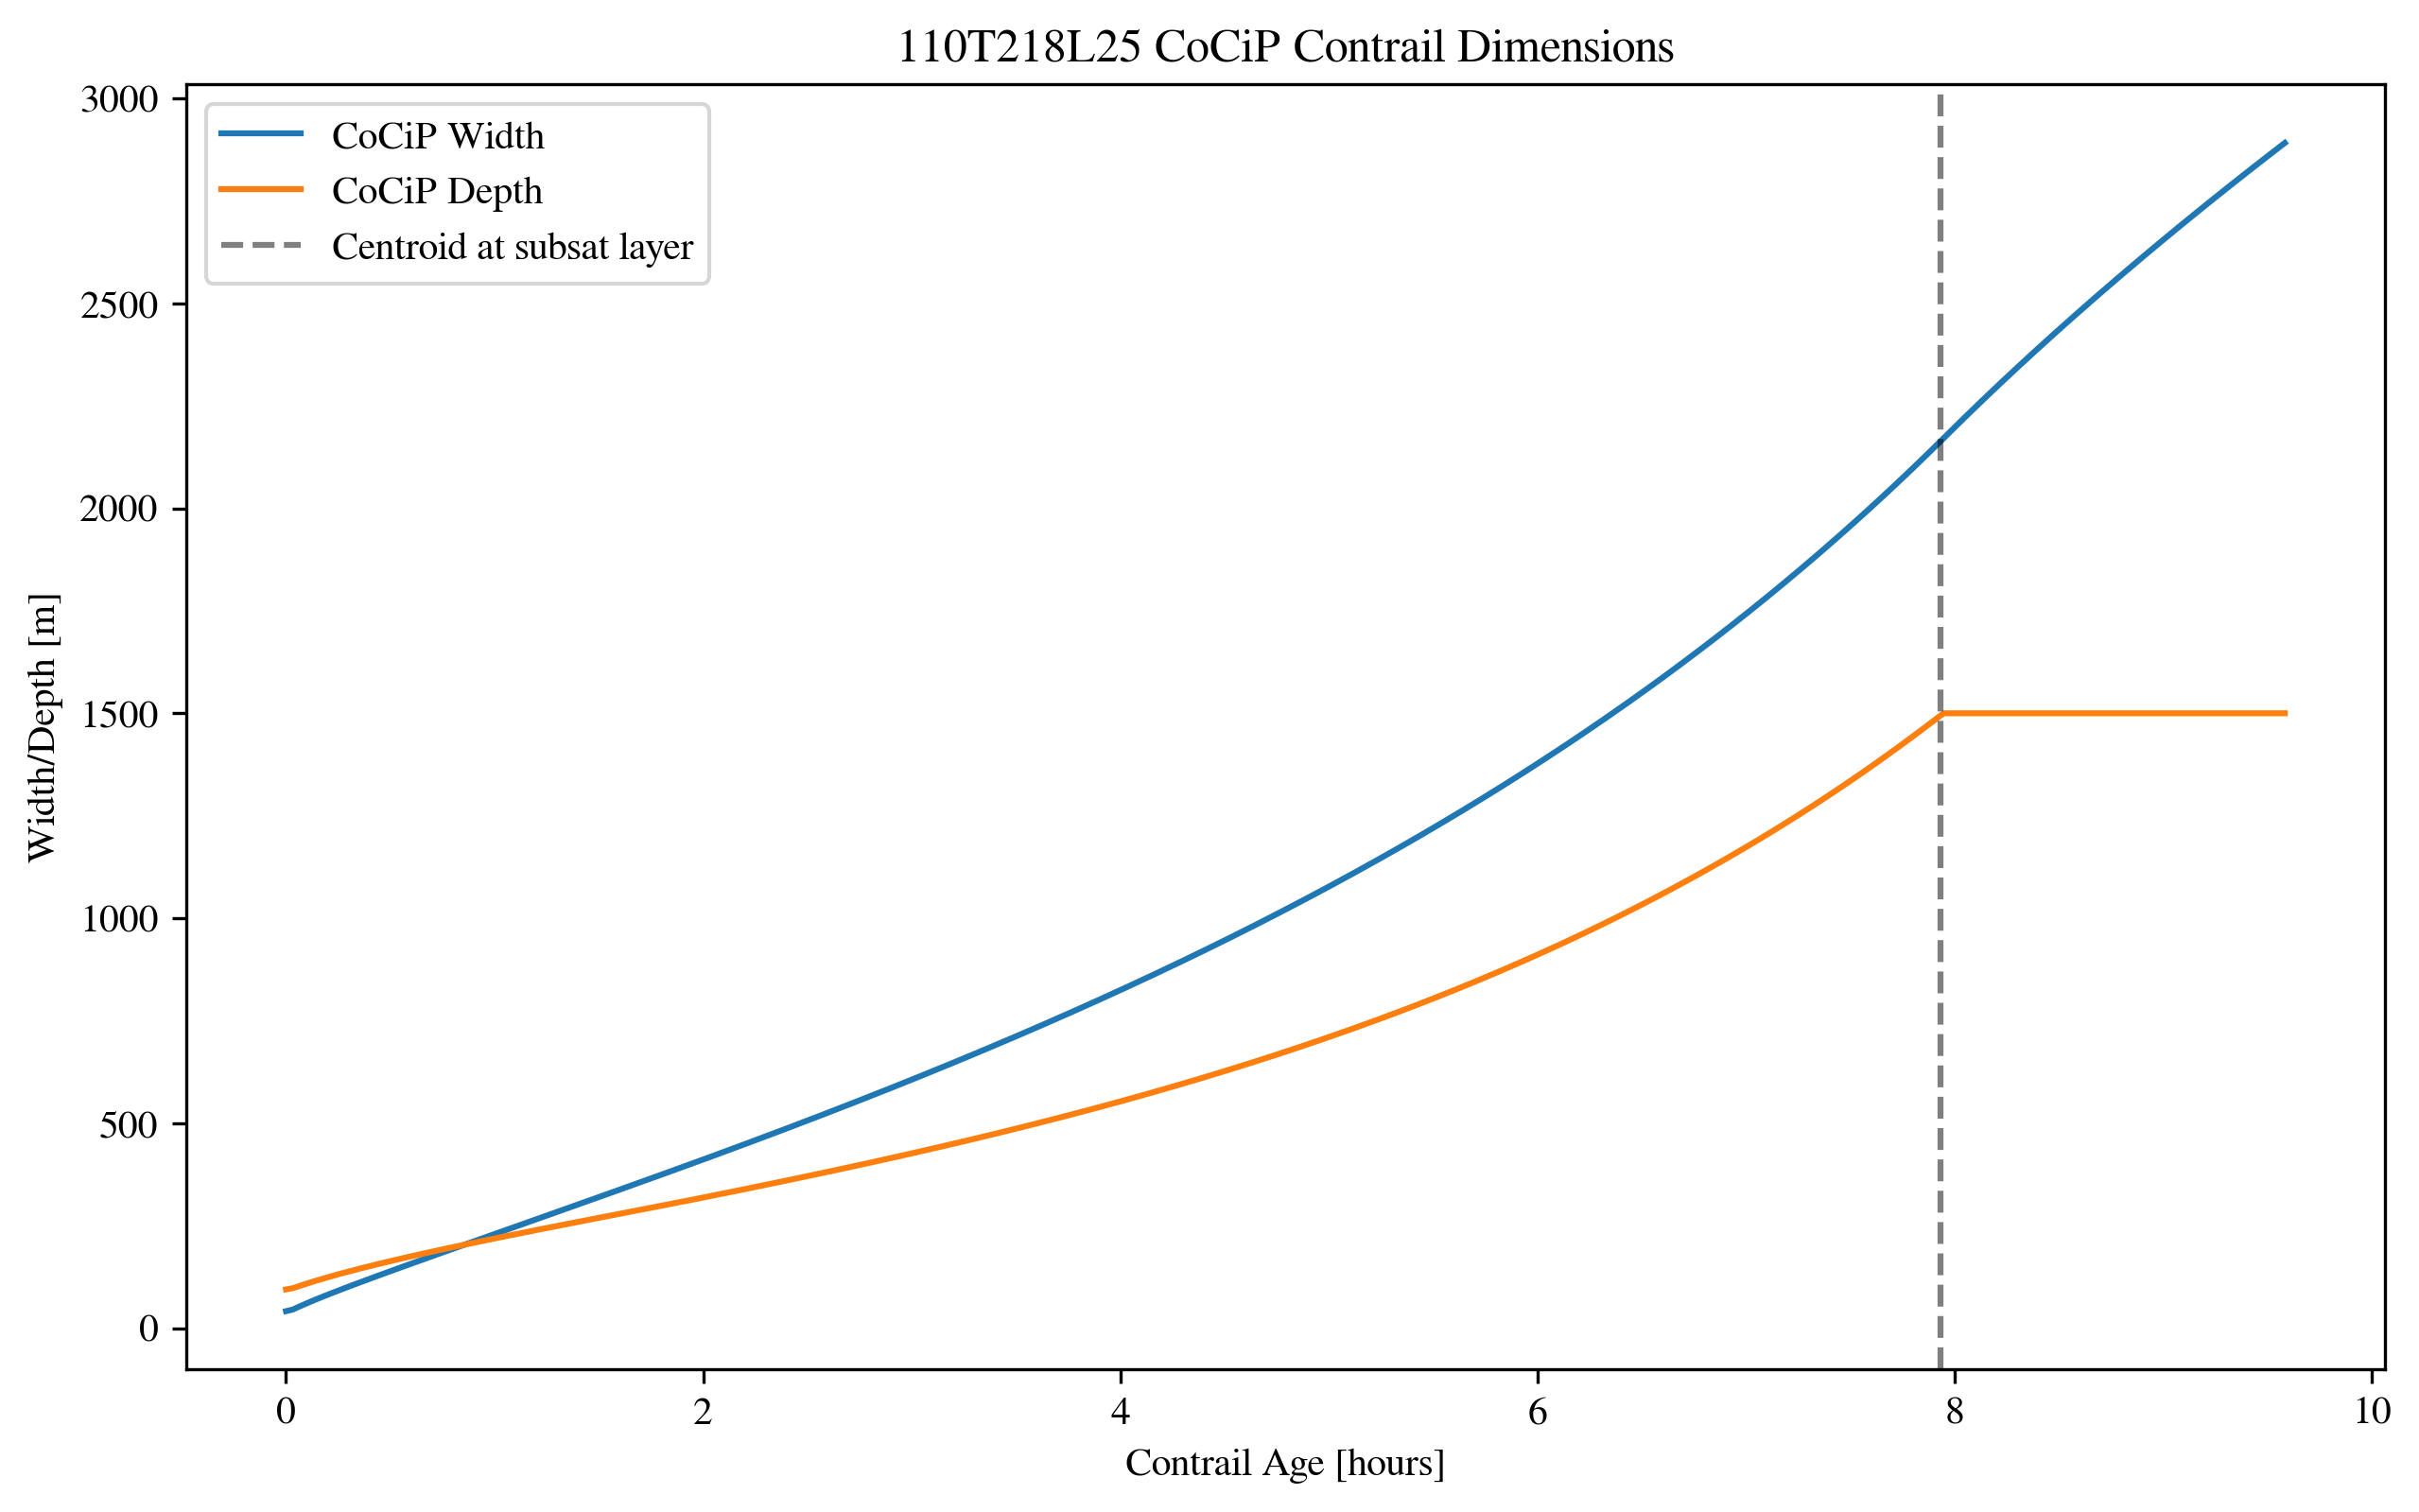

In [25]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
ax.plot(cocip_times, cocip_width, label="CoCiP Width", color="tab:blue")
ax.plot(cocip_times, cocip_depth, label="CoCiP Depth", color="tab:orange")
ax.set_xlabel("Contrail Age [hours]")
ax.set_ylabel("Width/Depth [m]")
ax.set_title(f'{test_id} CoCiP Contrail Dimensions')
ax.axvline(476/60, color='black', linestyle='--', alpha=0.5, label="Centroid at subsat layer")
ax.legend()

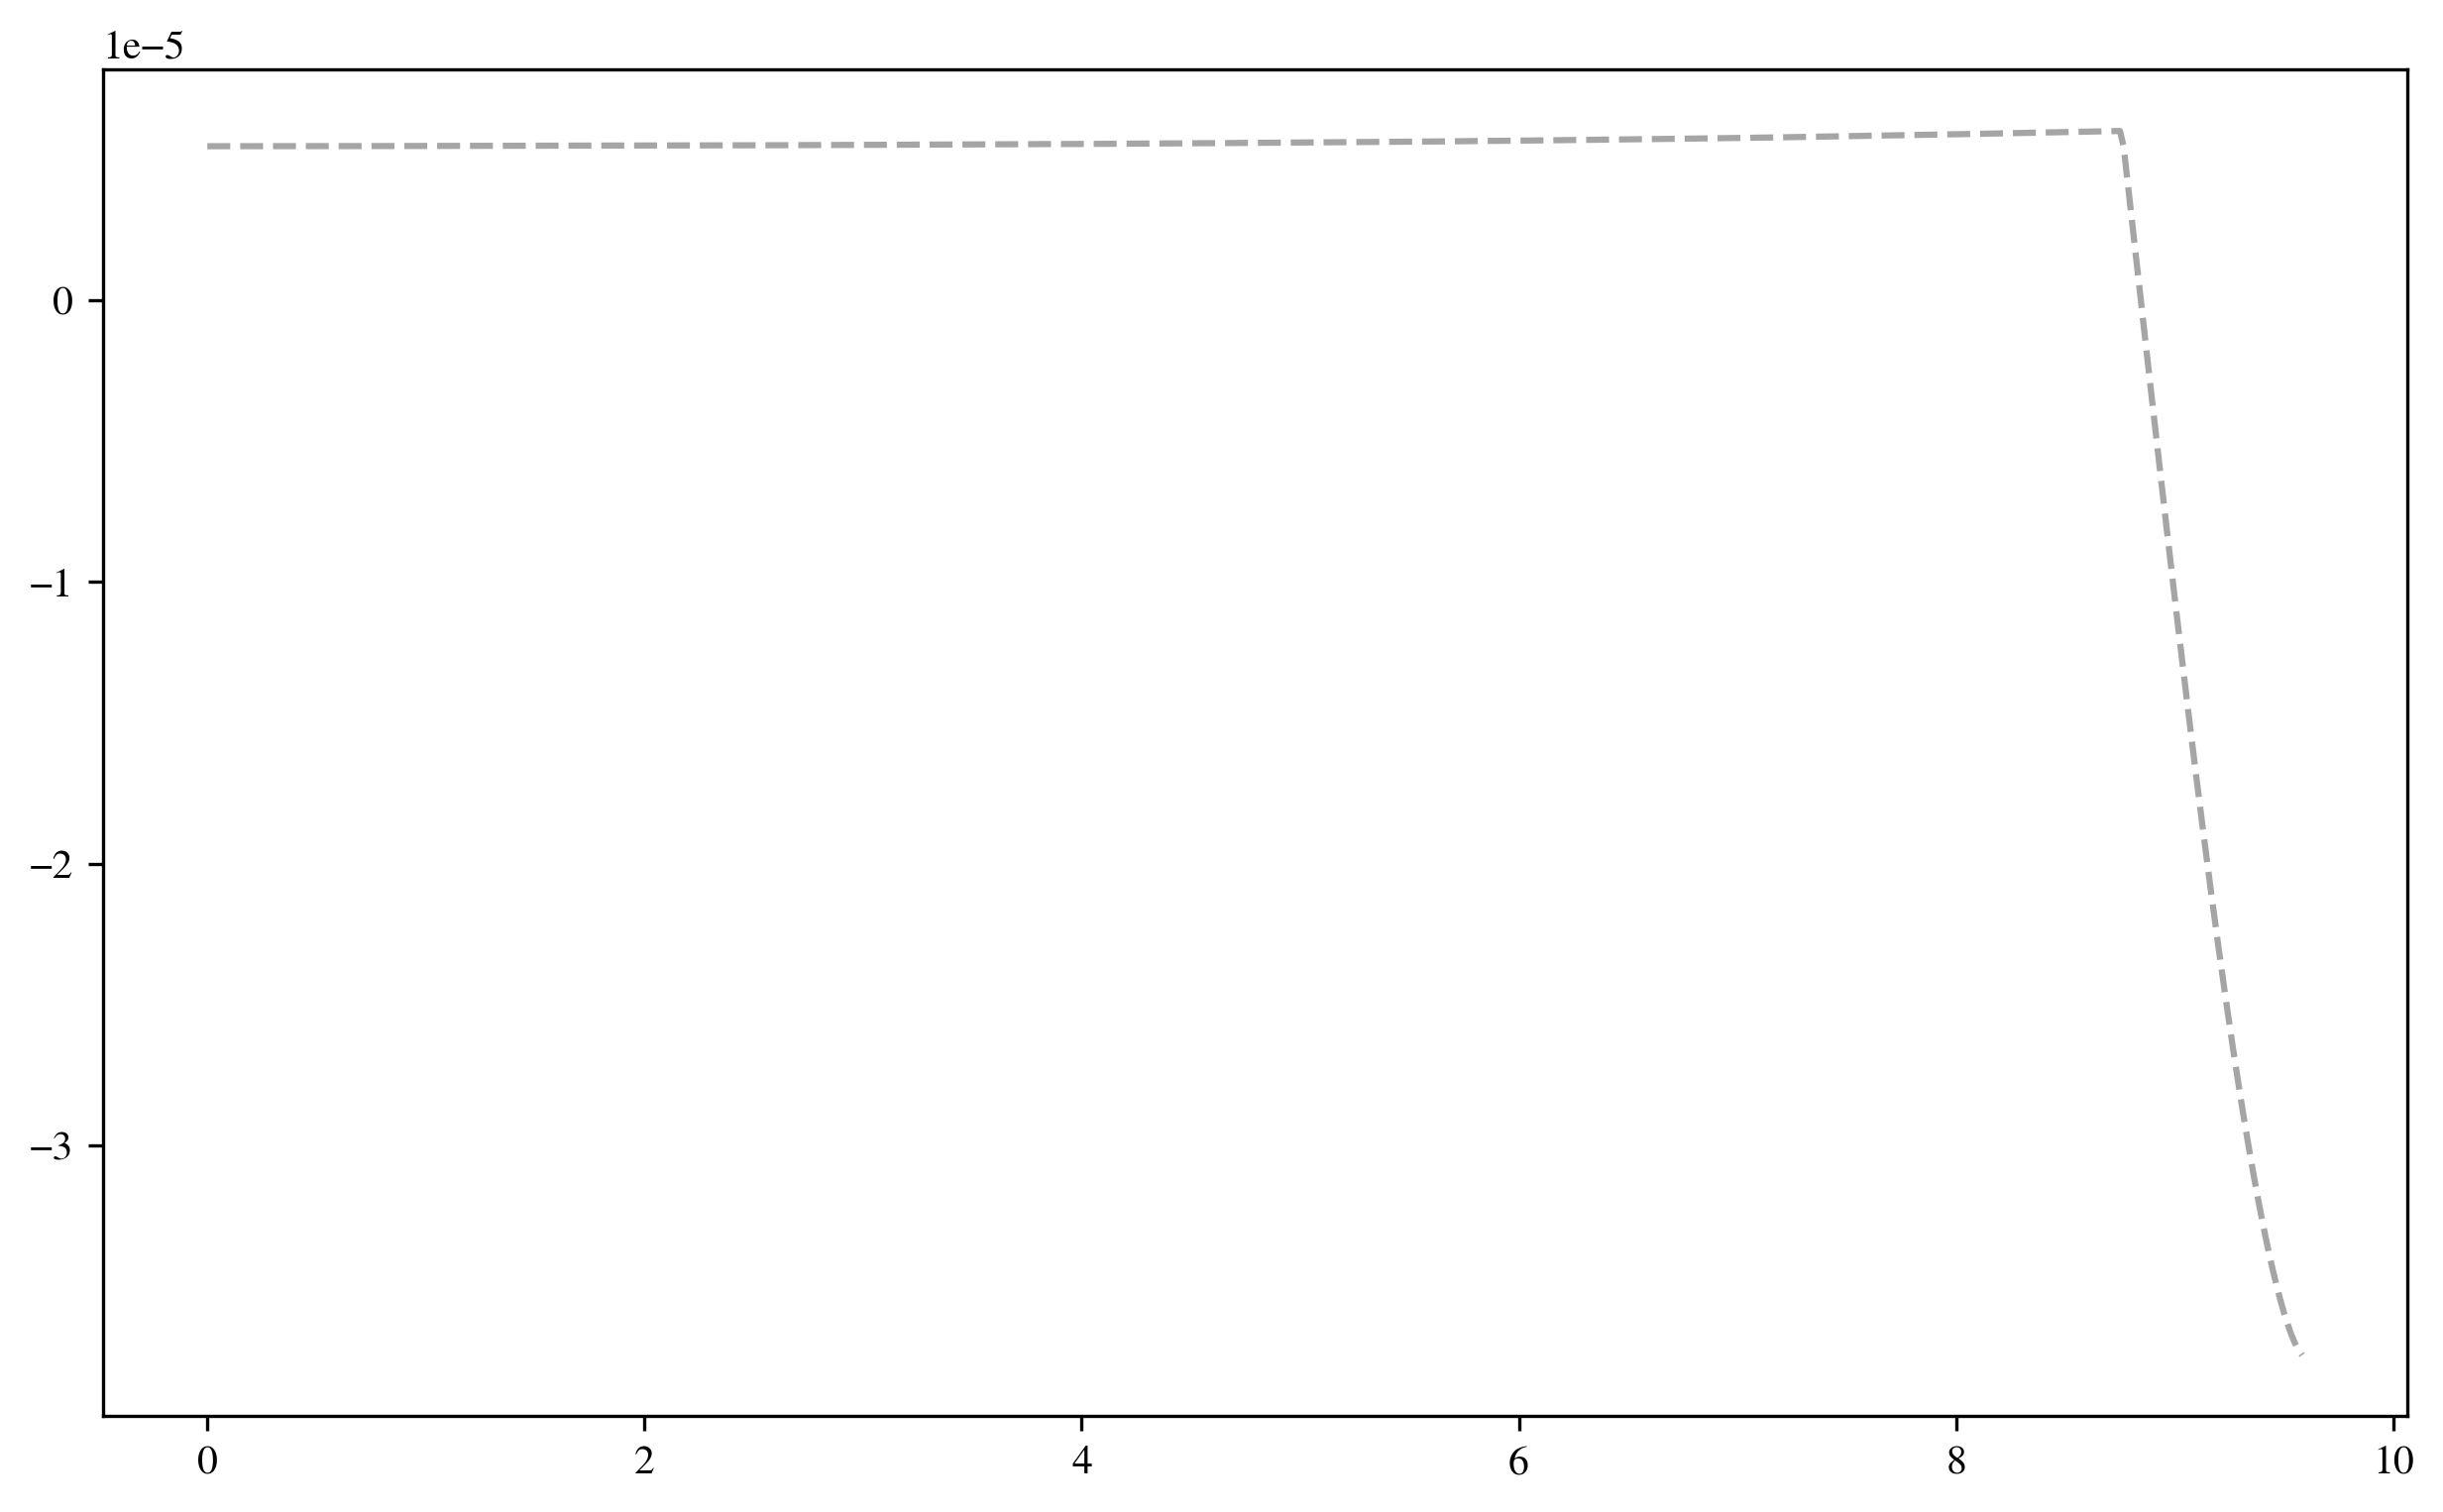

In [26]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
ax.plot(cocip_times, cocip_q - cocip_qsat, label="q mean - q sat", color="tab:gray", alpha=0.7, ls='--')

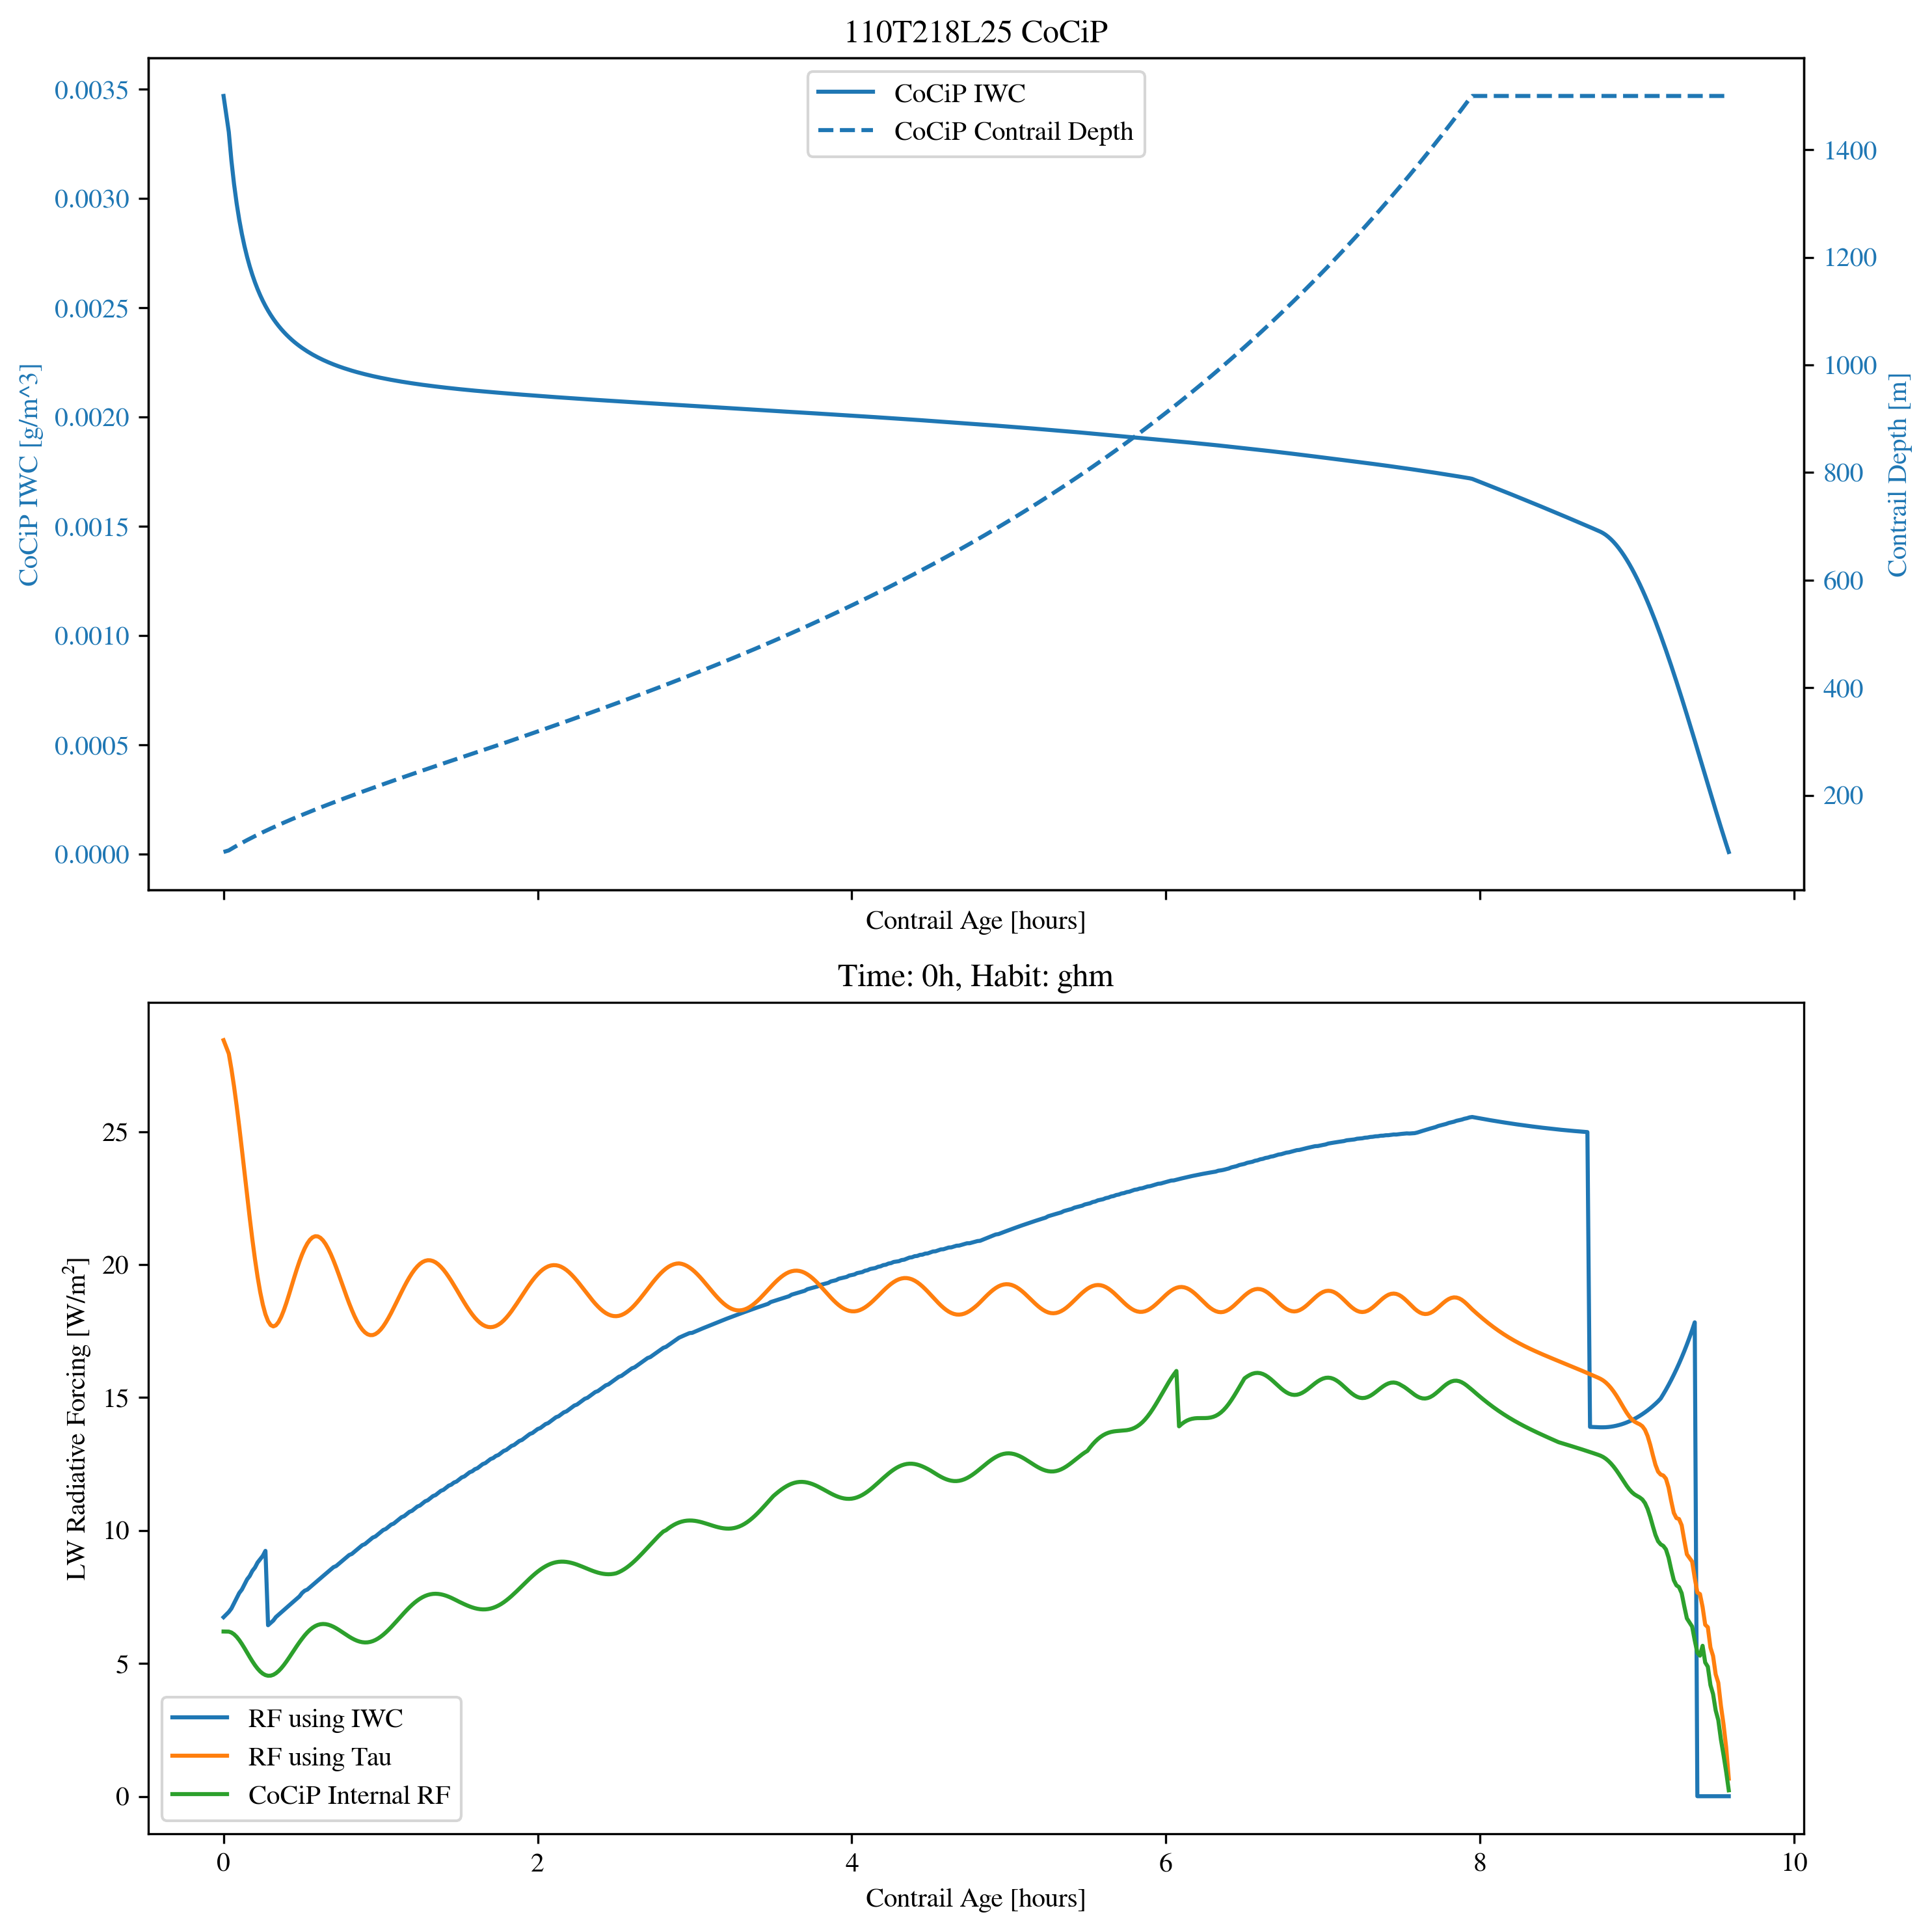

In [27]:
fig, axs = plt.subplots(2, 1, figsize=(10, 10), dpi=300, sharex=True)

# First plot: CoCiP IWC with Contrail Depth
ax1 = axs[0]
ax1.plot(cocip_ds["age_hours"], cocip_iwc, label="CoCiP IWC", color="tab:blue")
ax1.set_xlabel("Contrail Age [hours]")
ax1.set_ylabel("CoCiP IWC [g/m^3]", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.set_title(f'{test_id} CoCiP')

# Second y-axis for contrail depth
ax2 = ax1.twinx()
ax2.plot(cocip_times, cocip_depth, label="CoCiP Contrail Depth", color="tab:blue", ls='--')
ax2.set_ylabel("Contrail Depth [m]", color="tab:blue")
ax2.tick_params(axis='y', labelcolor="tab:blue")

# Legends for first plot
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper center")

# Second plot: IWC and non-IWC RF, plus internal LW
ax = axs[1]
for idx, hour in enumerate([0]):
    iwc_file = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T218L25/testing/LW_RF_cocip_ghm_{hour}h_IWC.csv"
    noniwc_file = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T218L25/testing/LW_RF_cocip_ghm_{hour}h.csv"
    iwc_df = pd.read_csv(iwc_file)
    noniwc_df = pd.read_csv(noniwc_file)
    ax.plot(iwc_df["Contrail_Age_hours"], iwc_df["LW_Radiative_Forcing_W_m2"], label="RF using IWC", color="tab:blue")
    ax.plot(noniwc_df["Contrail_Age_hours"], noniwc_df["LW_Radiative_Forcing_W_m2"], label="RF using Tau", color="tab:orange")
    ax.plot(cocip_times, cocip_internal_RF_LW, label="CoCiP Internal RF", color="tab:green")
ax.set_title(f"Time: {hour}h, Habit: ghm")
ax.set_xlabel("Contrail Age [hours]")
ax.set_ylabel("LW Radiative Forcing [W/m²]")
ax.legend()

plt.tight_layout()
plt.show()


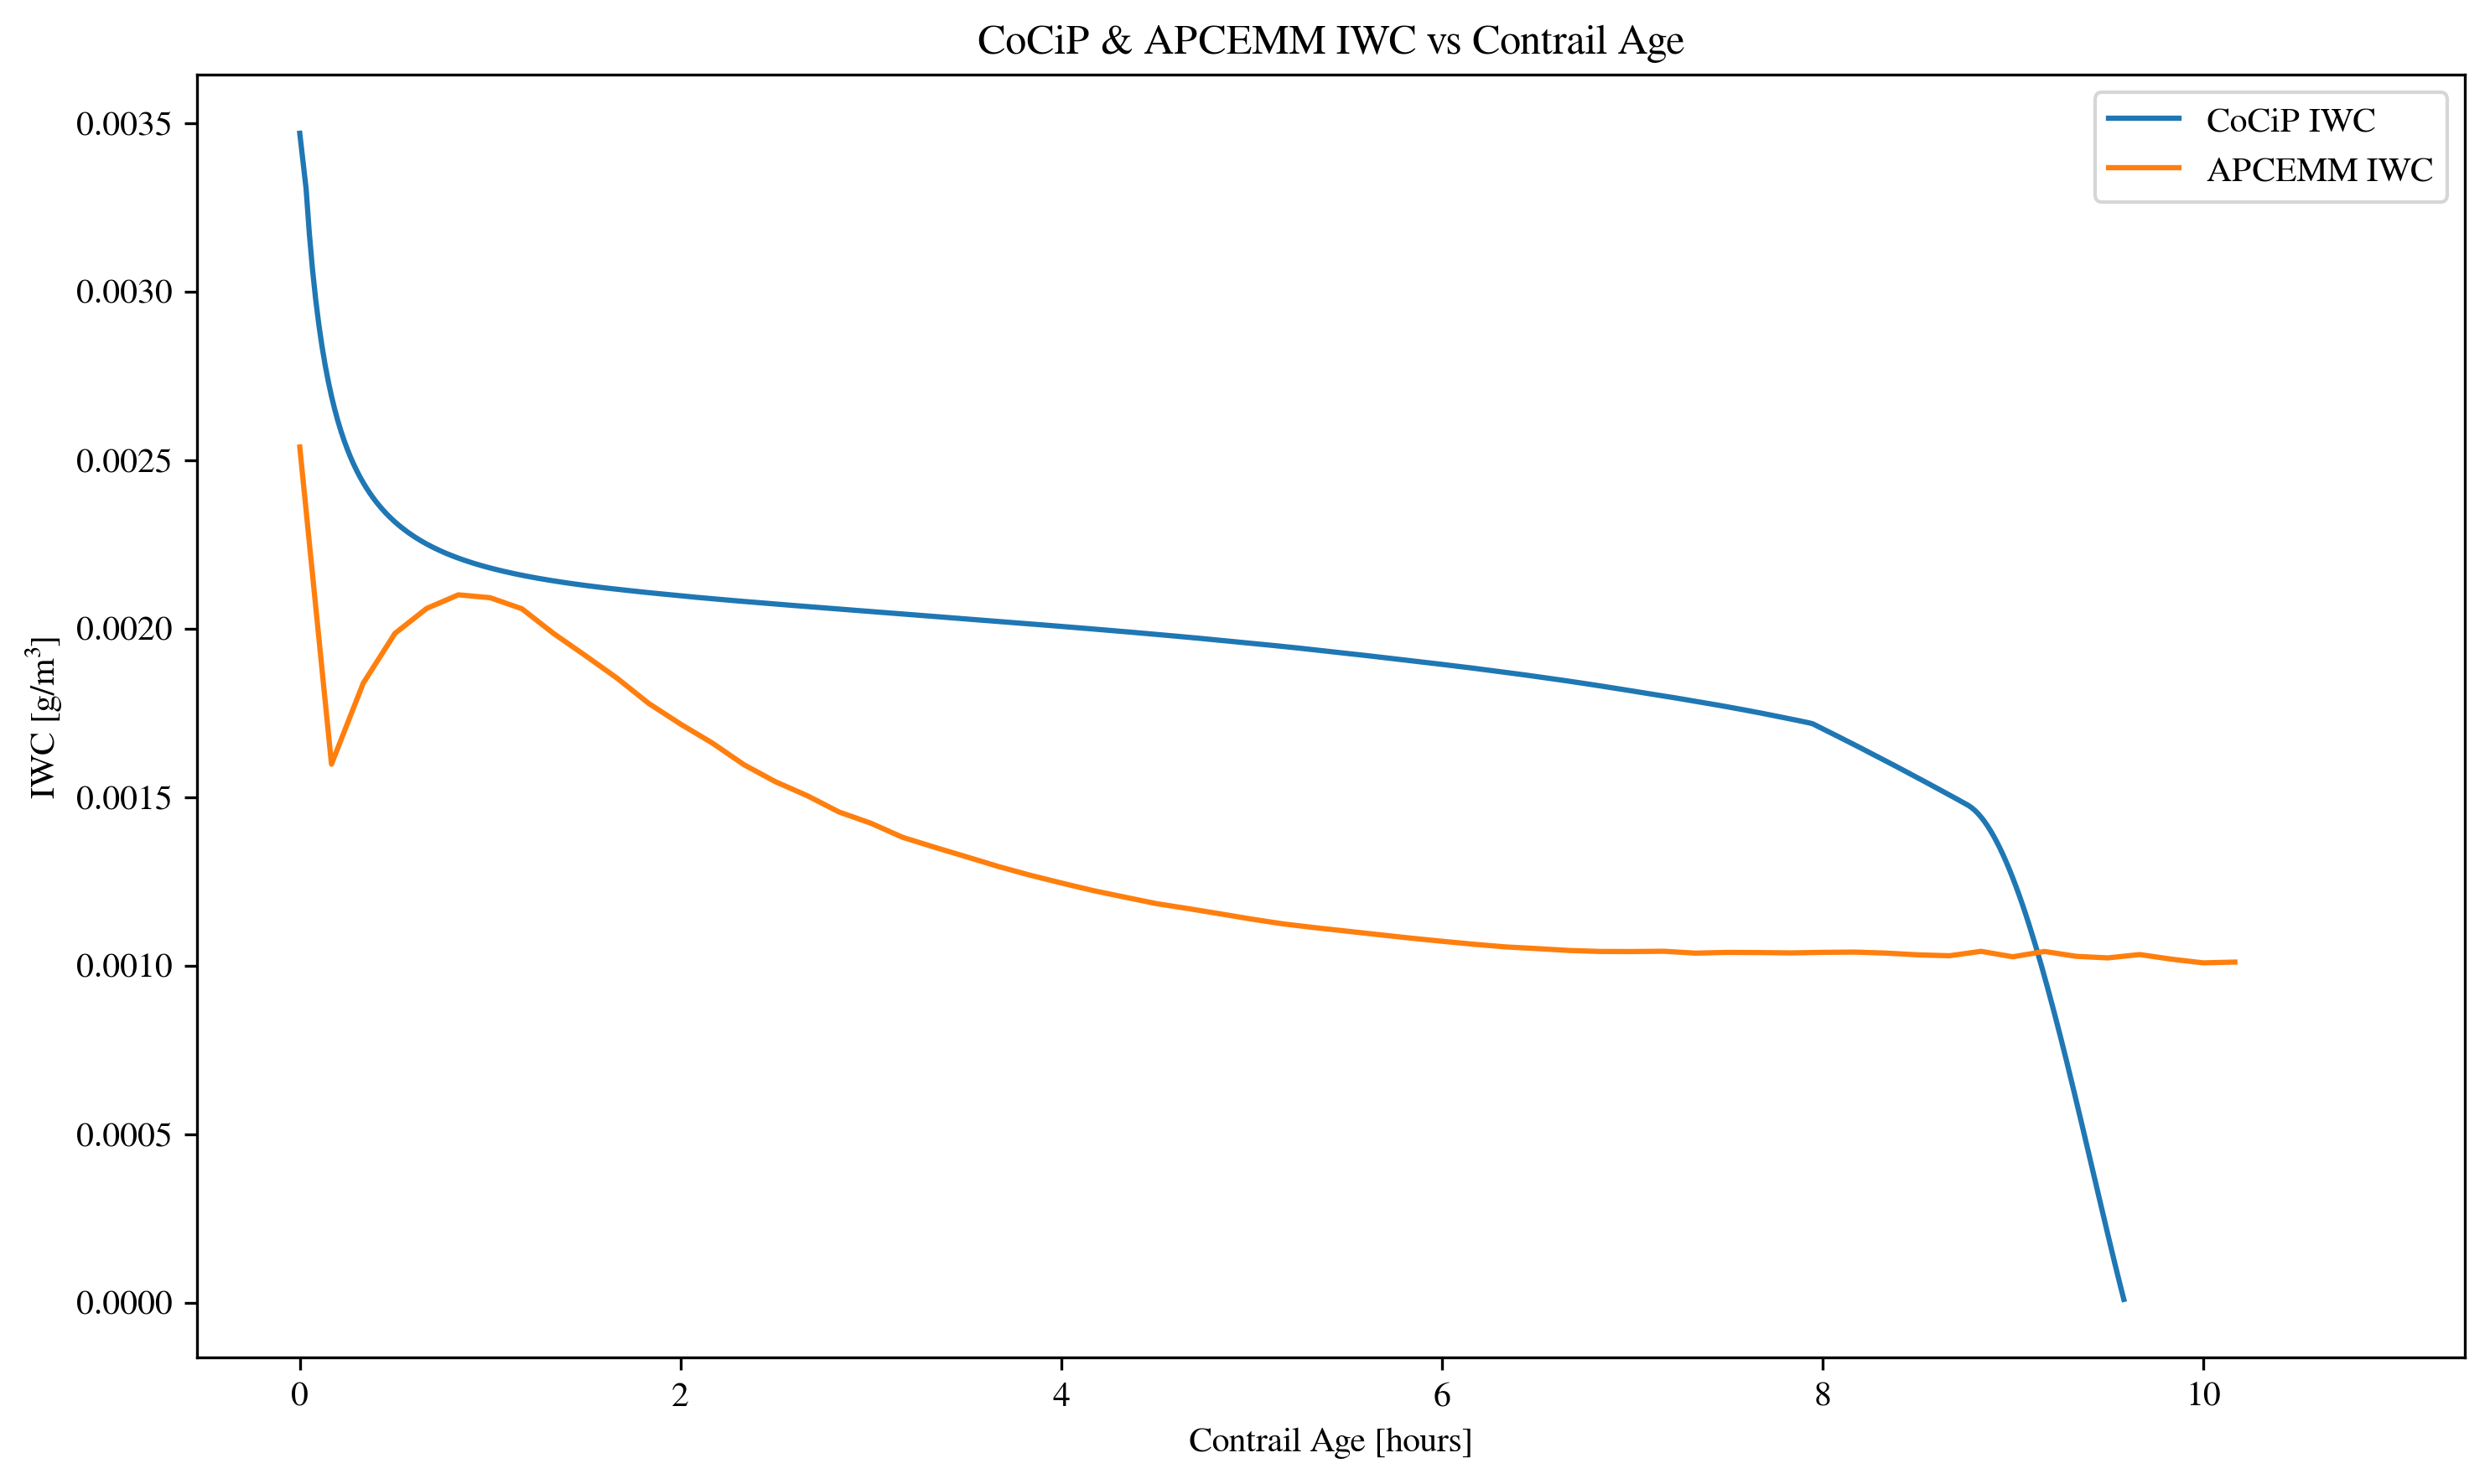

In [28]:
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(cocip_times, cocip_iwc, label="CoCiP IWC", color="tab:blue")
plt.plot(APCEMM_times, APCEMM_IWC_avg, label="APCEMM IWC", color="tab:orange")
plt.xlabel("Contrail Age [hours]")
plt.ylabel("IWC [g/m³]")
plt.title("CoCiP & APCEMM IWC vs Contrail Age")
plt.legend()
plt.tight_layout()
plt.show()

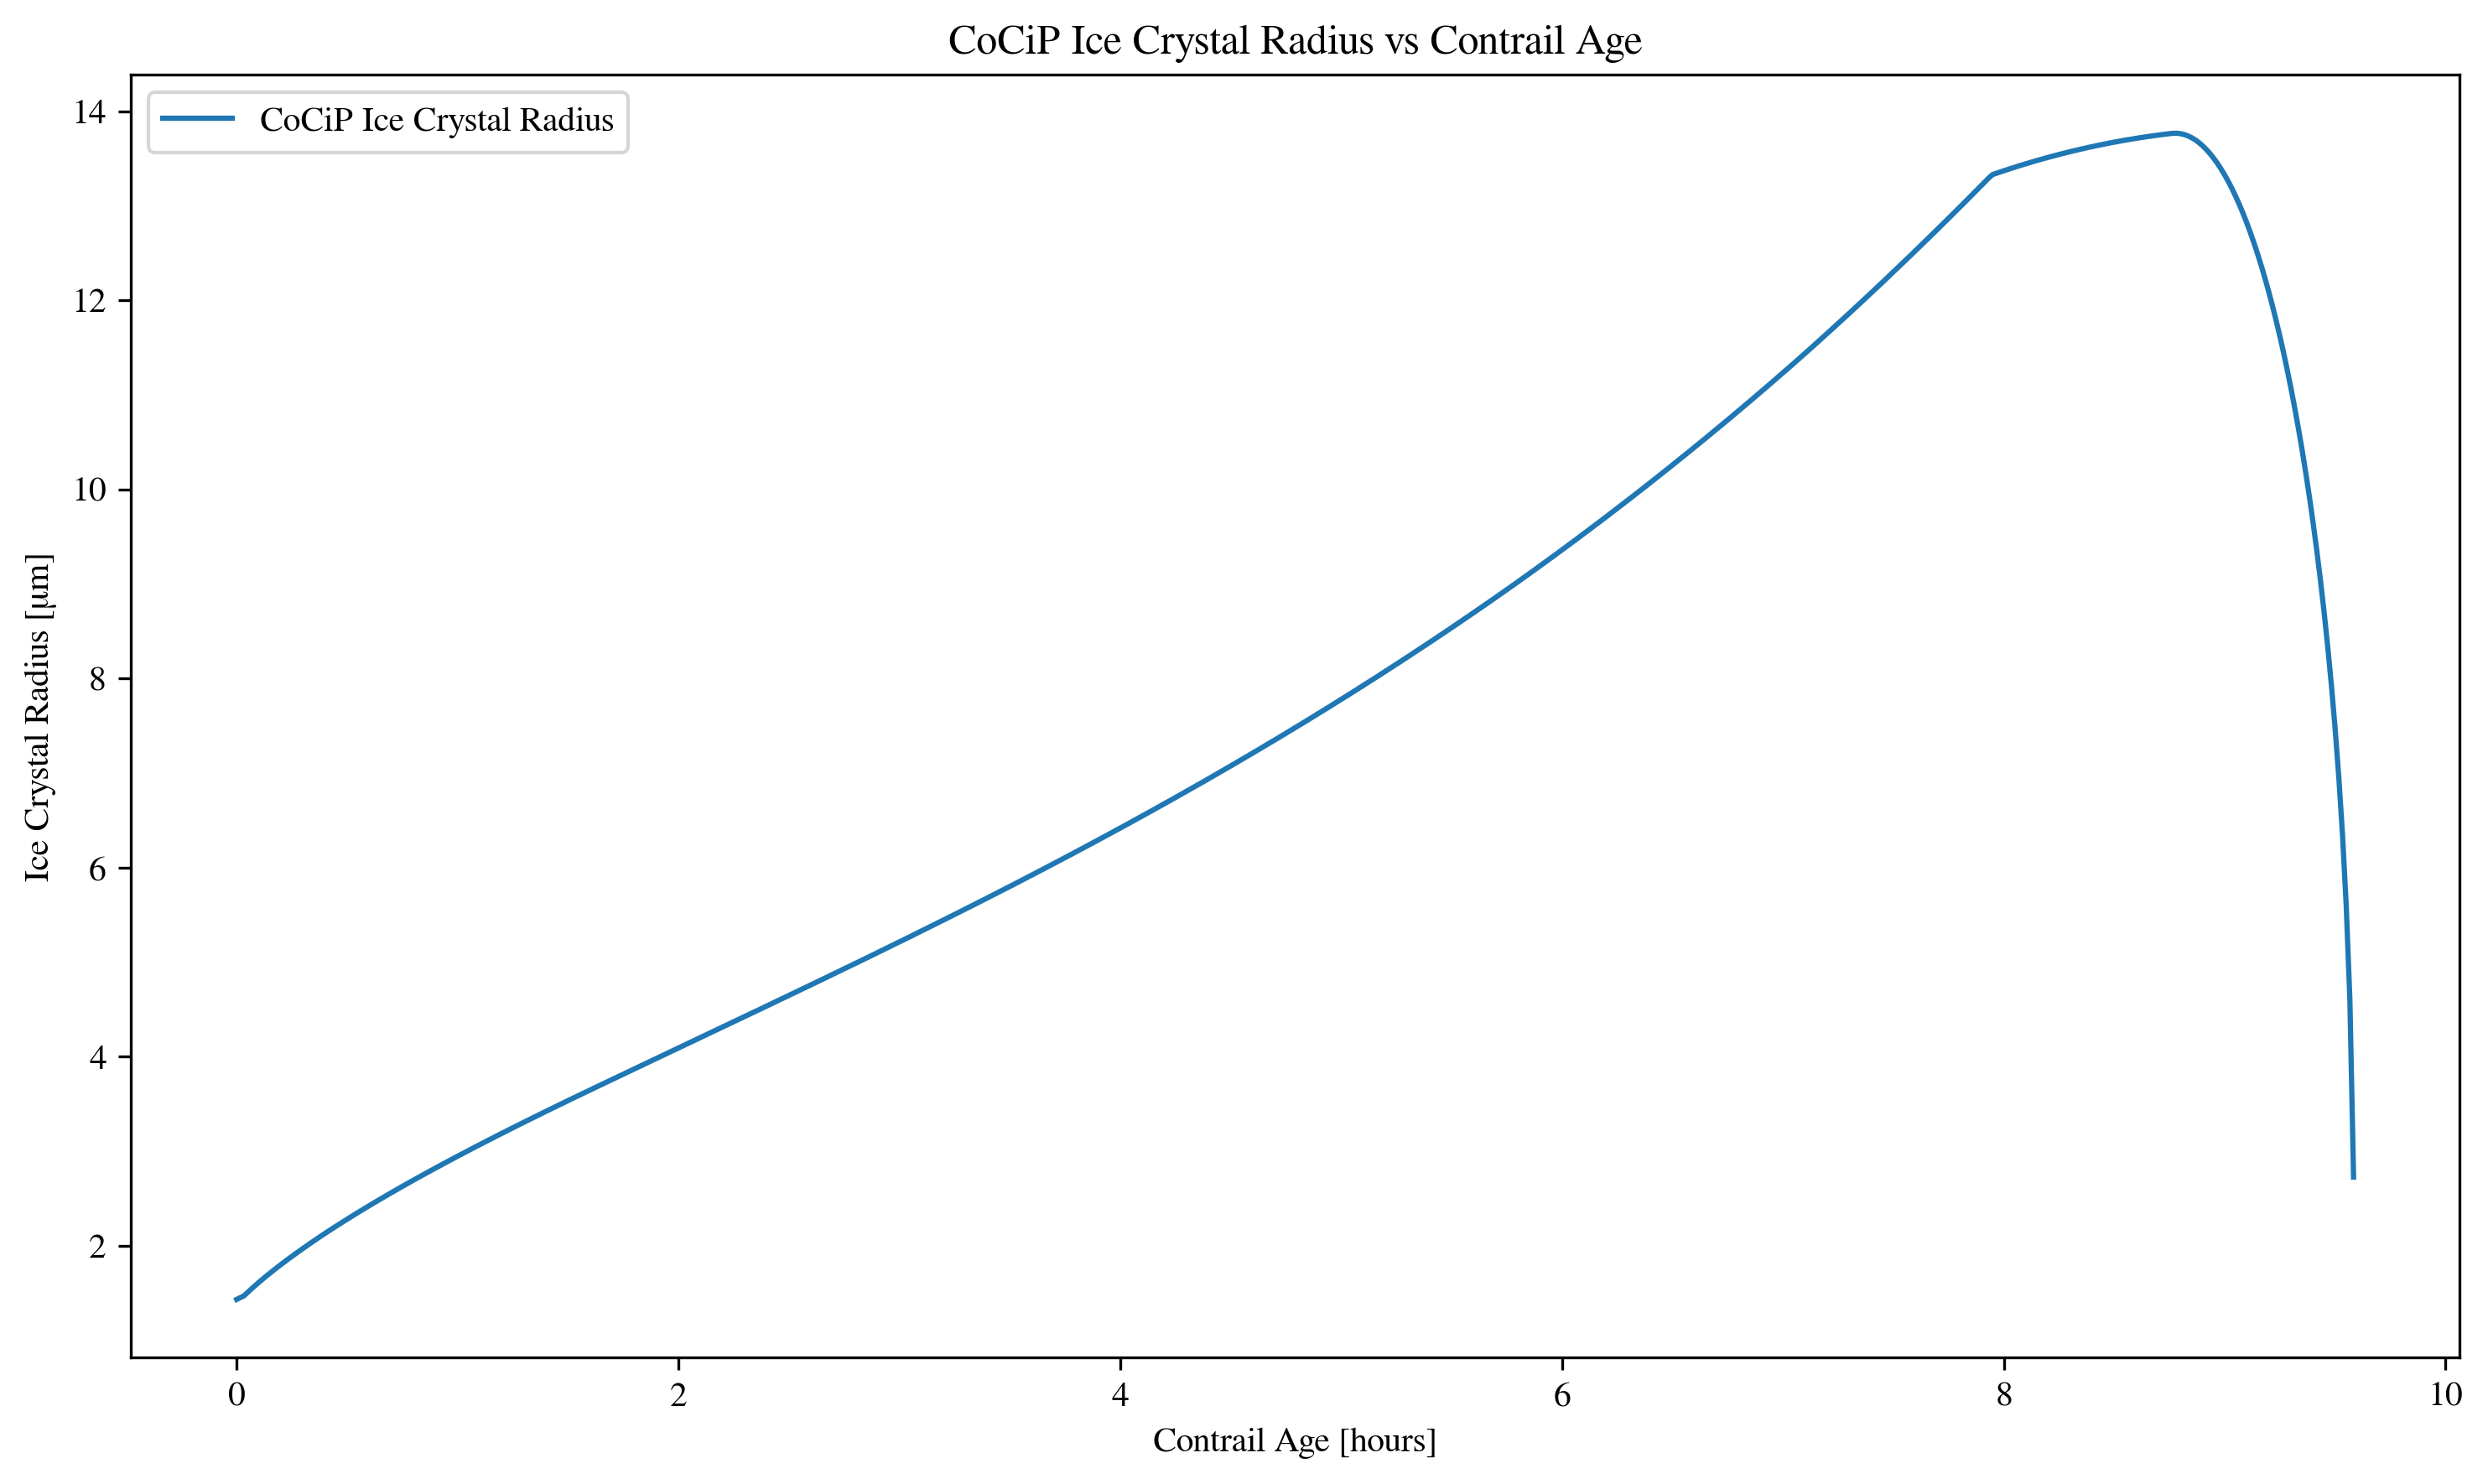

In [29]:
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(cocip_times, cocip_radii, label="CoCiP Ice Crystal Radius", color="tab:blue")
plt.xlabel("Contrail Age [hours]")
plt.ylabel("Ice Crystal Radius [μm]")
plt.title("CoCiP Ice Crystal Radius vs Contrail Age")
plt.legend()
plt.tight_layout()
plt.show()

## RF of LLES with IWC

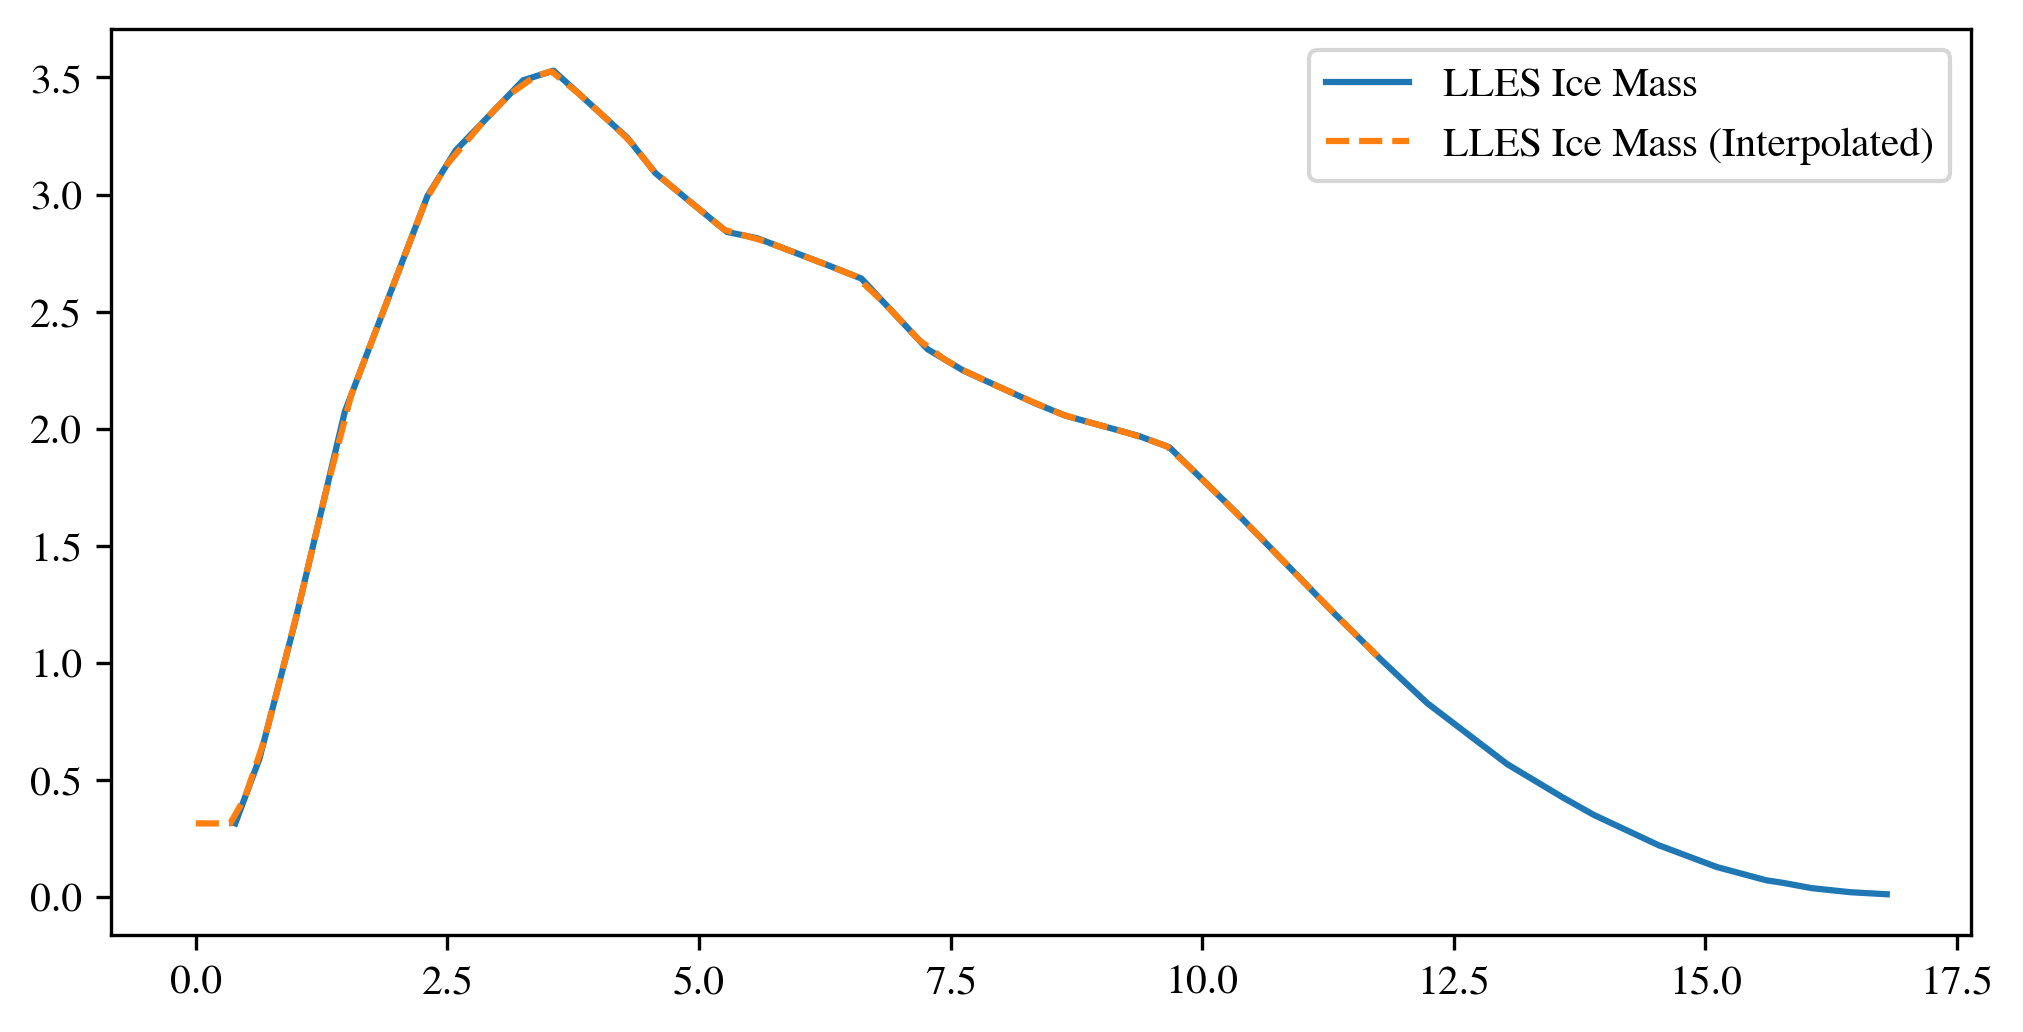

In [30]:
LLES_times = ice_surface_area[0]
LLES_times = LLES_times[LLES_times <= 12]  # Limit to 12 hours

fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
ax.plot(LLES_ice_mass[0], LLES_ice_mass[1], label="LLES Ice Mass", color="tab:blue")

# Interpolate LLES ice mass to 75 points (to match LLES_times)
interp_func = interp1d(LLES_ice_mass[0], LLES_ice_mass[1], kind='linear', fill_value="extrapolate")
LLES_ice_mass_interp = np.clip(interp_func(LLES_times), LLES_ice_mass[1][0], None)

ax.plot(LLES_times, LLES_ice_mass_interp, label="LLES Ice Mass (Interpolated)", color="tab:orange", linestyle="--")
ax.legend()

In [31]:
# Calculate the approximate contrail volume
LLES_volume = np.pi * 0.5*(LLES_widths_fitted * LLES_depths_fitted) # [m]*[m]*[m] Assuming 1m thick slice and ellipse

# Calculate the average IWC
LLES_IWC = 1000 * LLES_ice_mass_interp/LLES_volume # [g]/[m3]

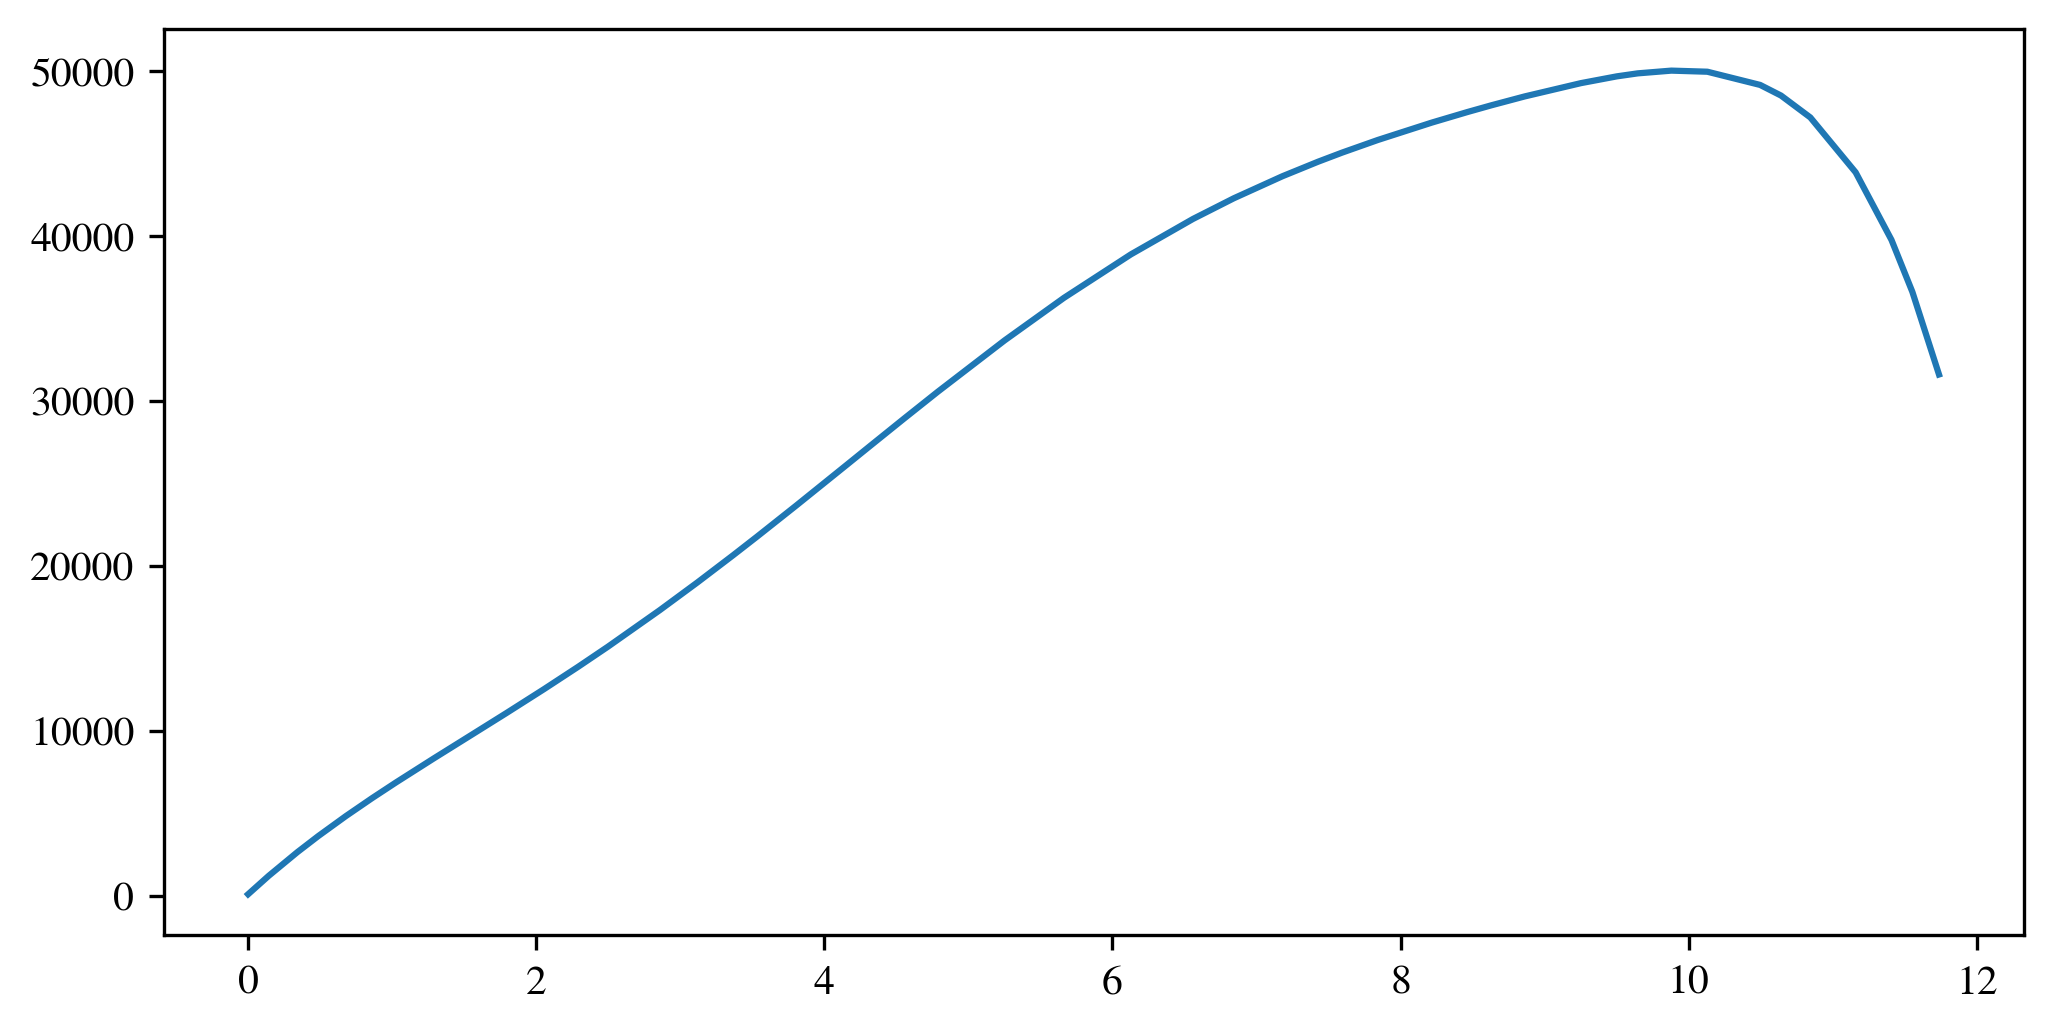

In [32]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
ax.plot(LLES_times, LLES_widths_fitted, label="LLES Width", color="tab:blue")


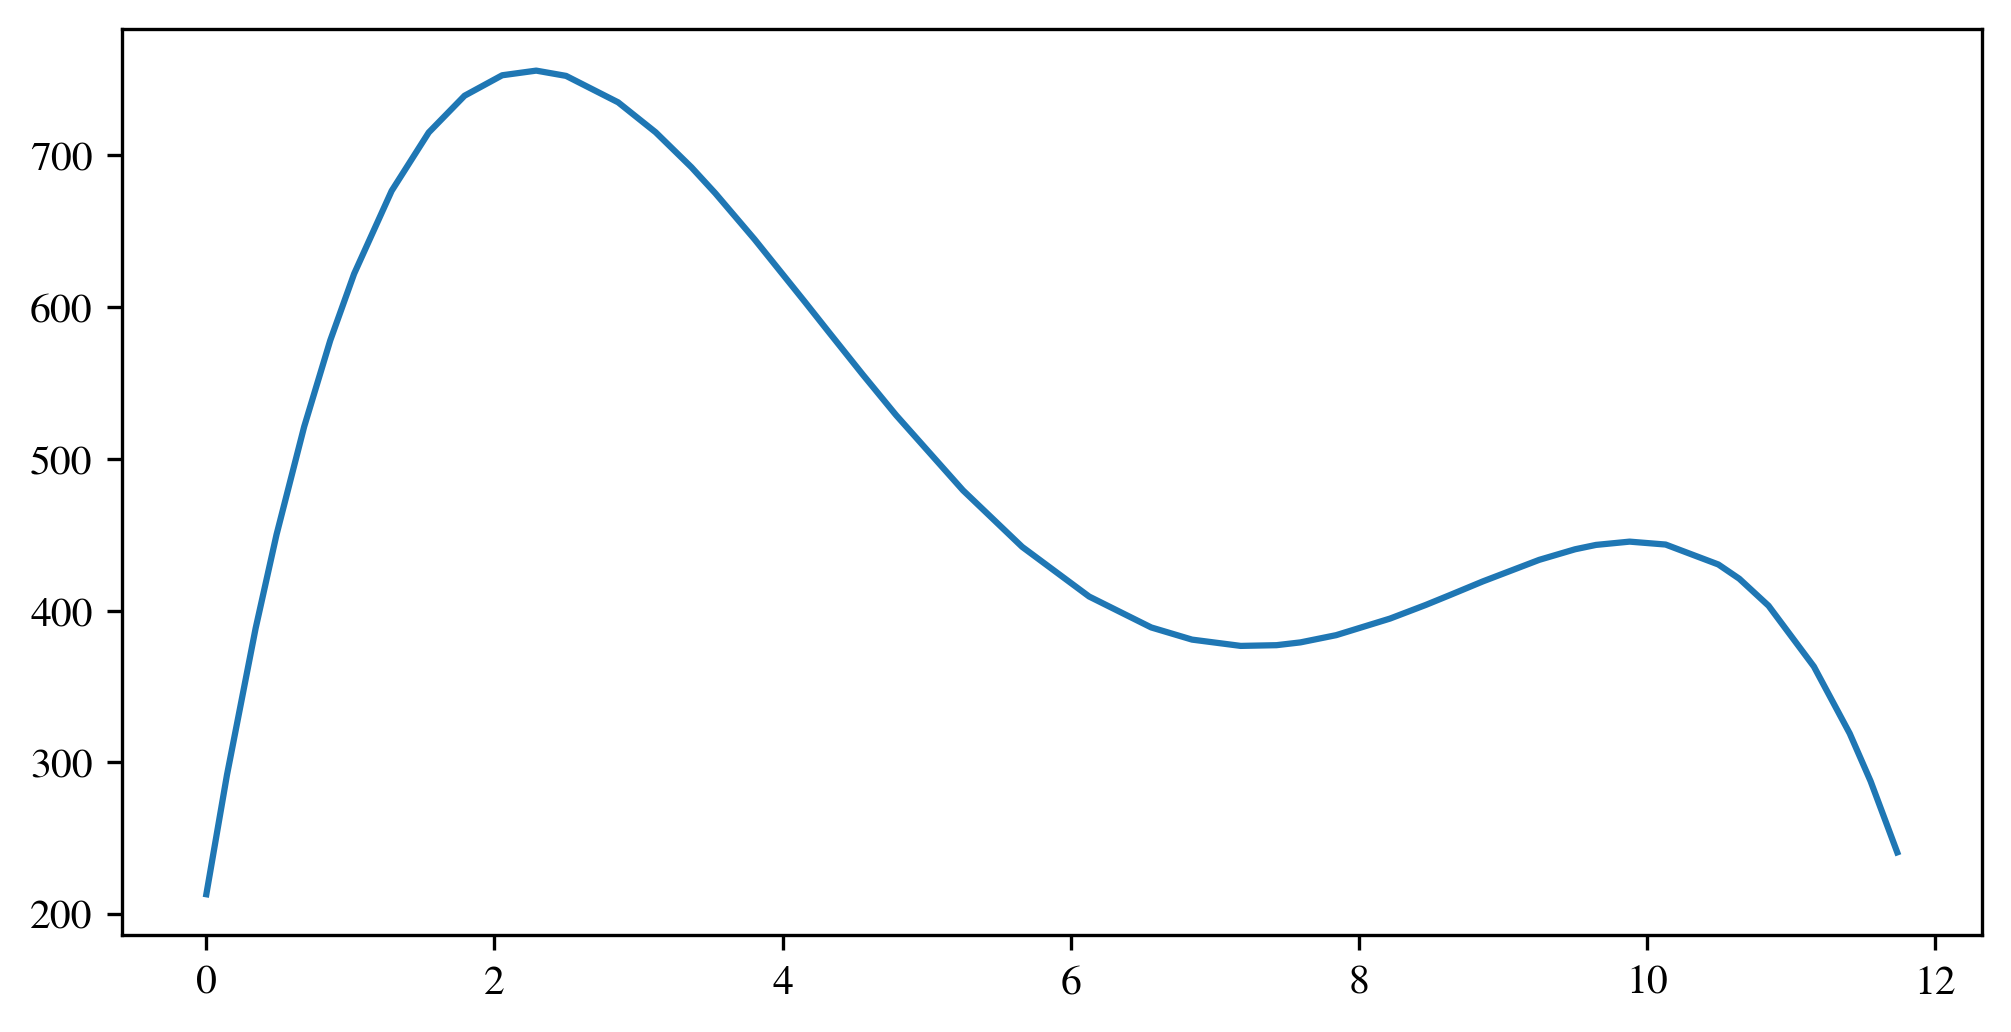

In [33]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
ax.plot(LLES_times, LLES_depths_fitted, label="LLES depth", color="tab:blue")

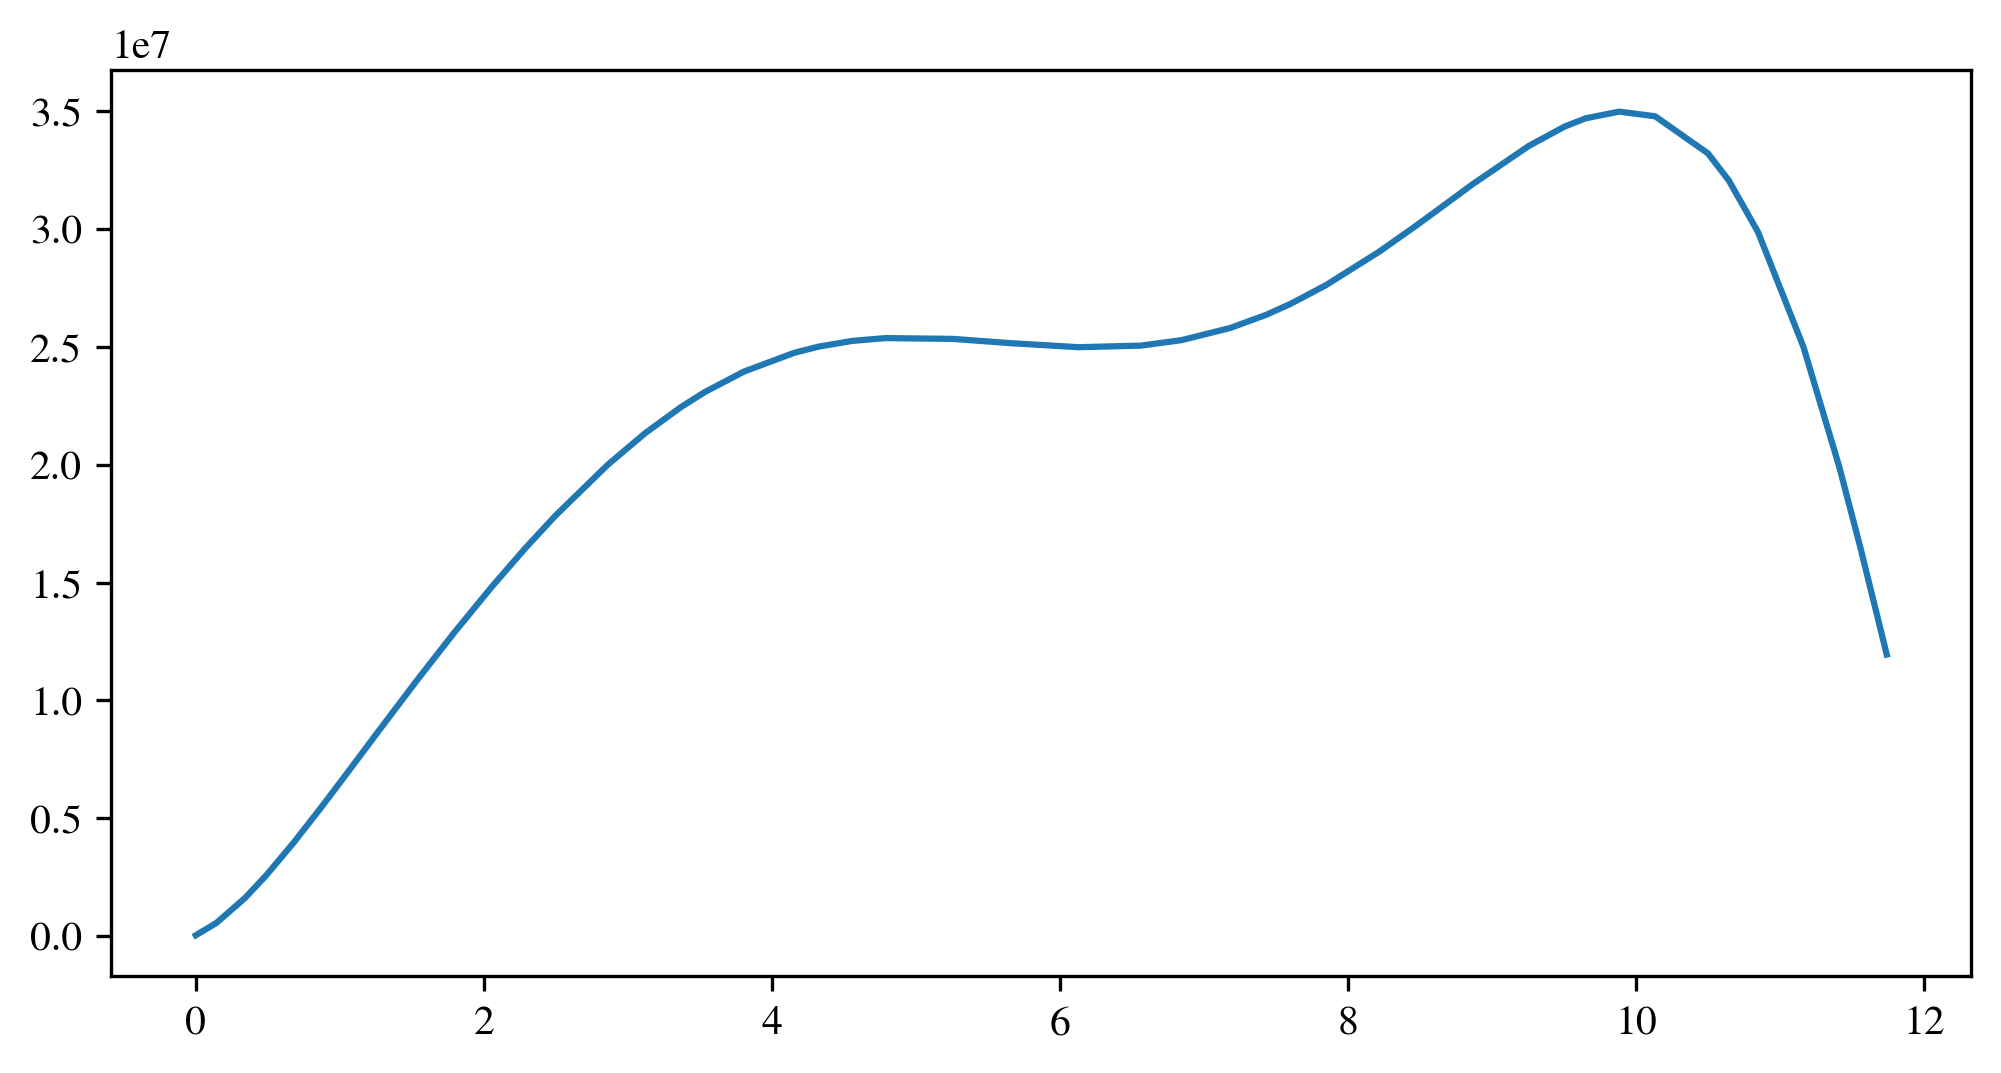

In [34]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
ax.plot(LLES_times, LLES_volume, label="LLES Volume", color="tab:blue")

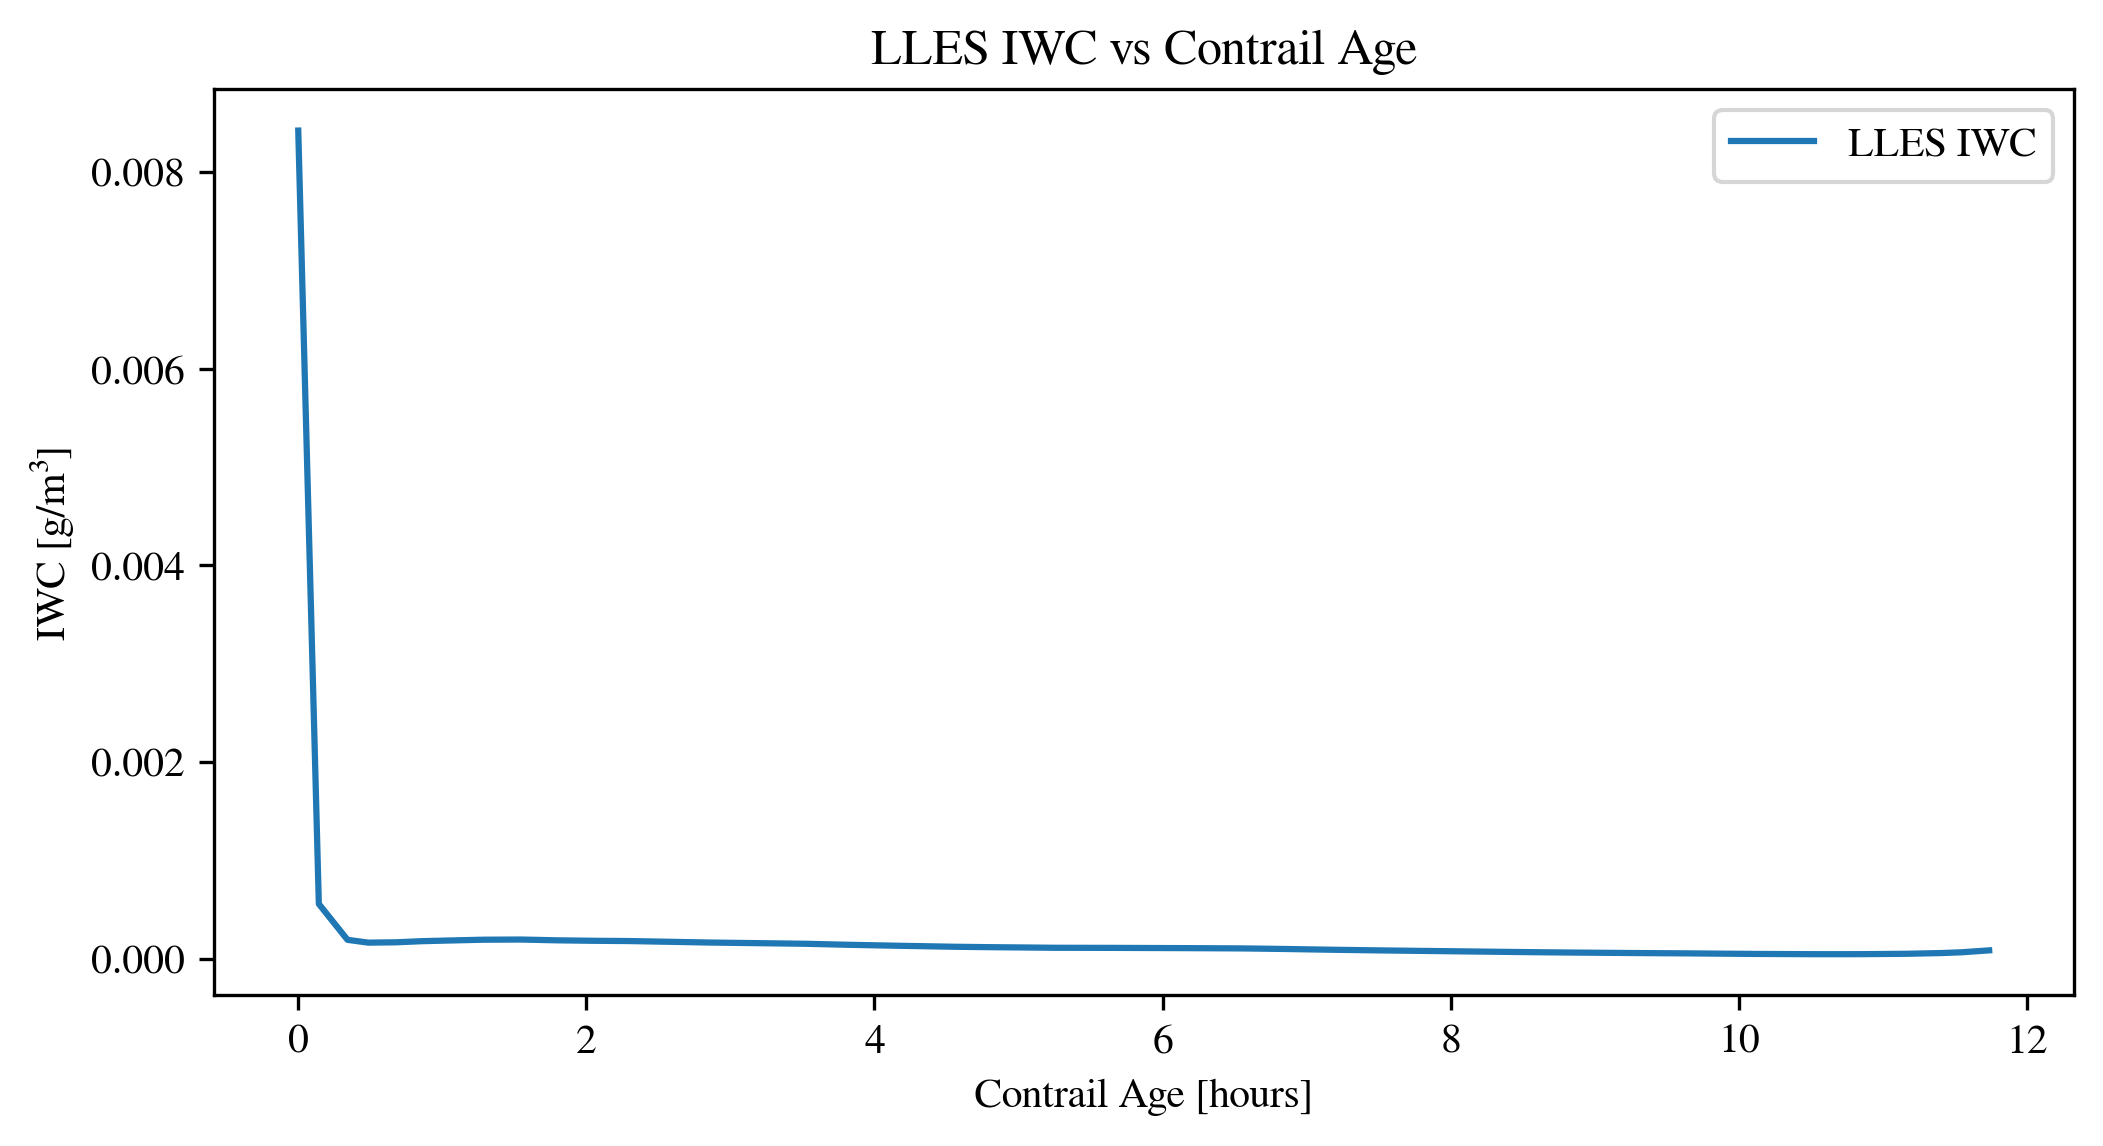

In [35]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
ax.plot(LLES_times, LLES_IWC, label="LLES IWC", color="tab:blue") # Convert to g/m3
ax.set_xlabel("Contrail Age [hours]")
ax.set_ylabel("IWC [g/m³]")
ax.set_title("LLES IWC vs Contrail Age")
ax.legend()

(0.0, 0.004)

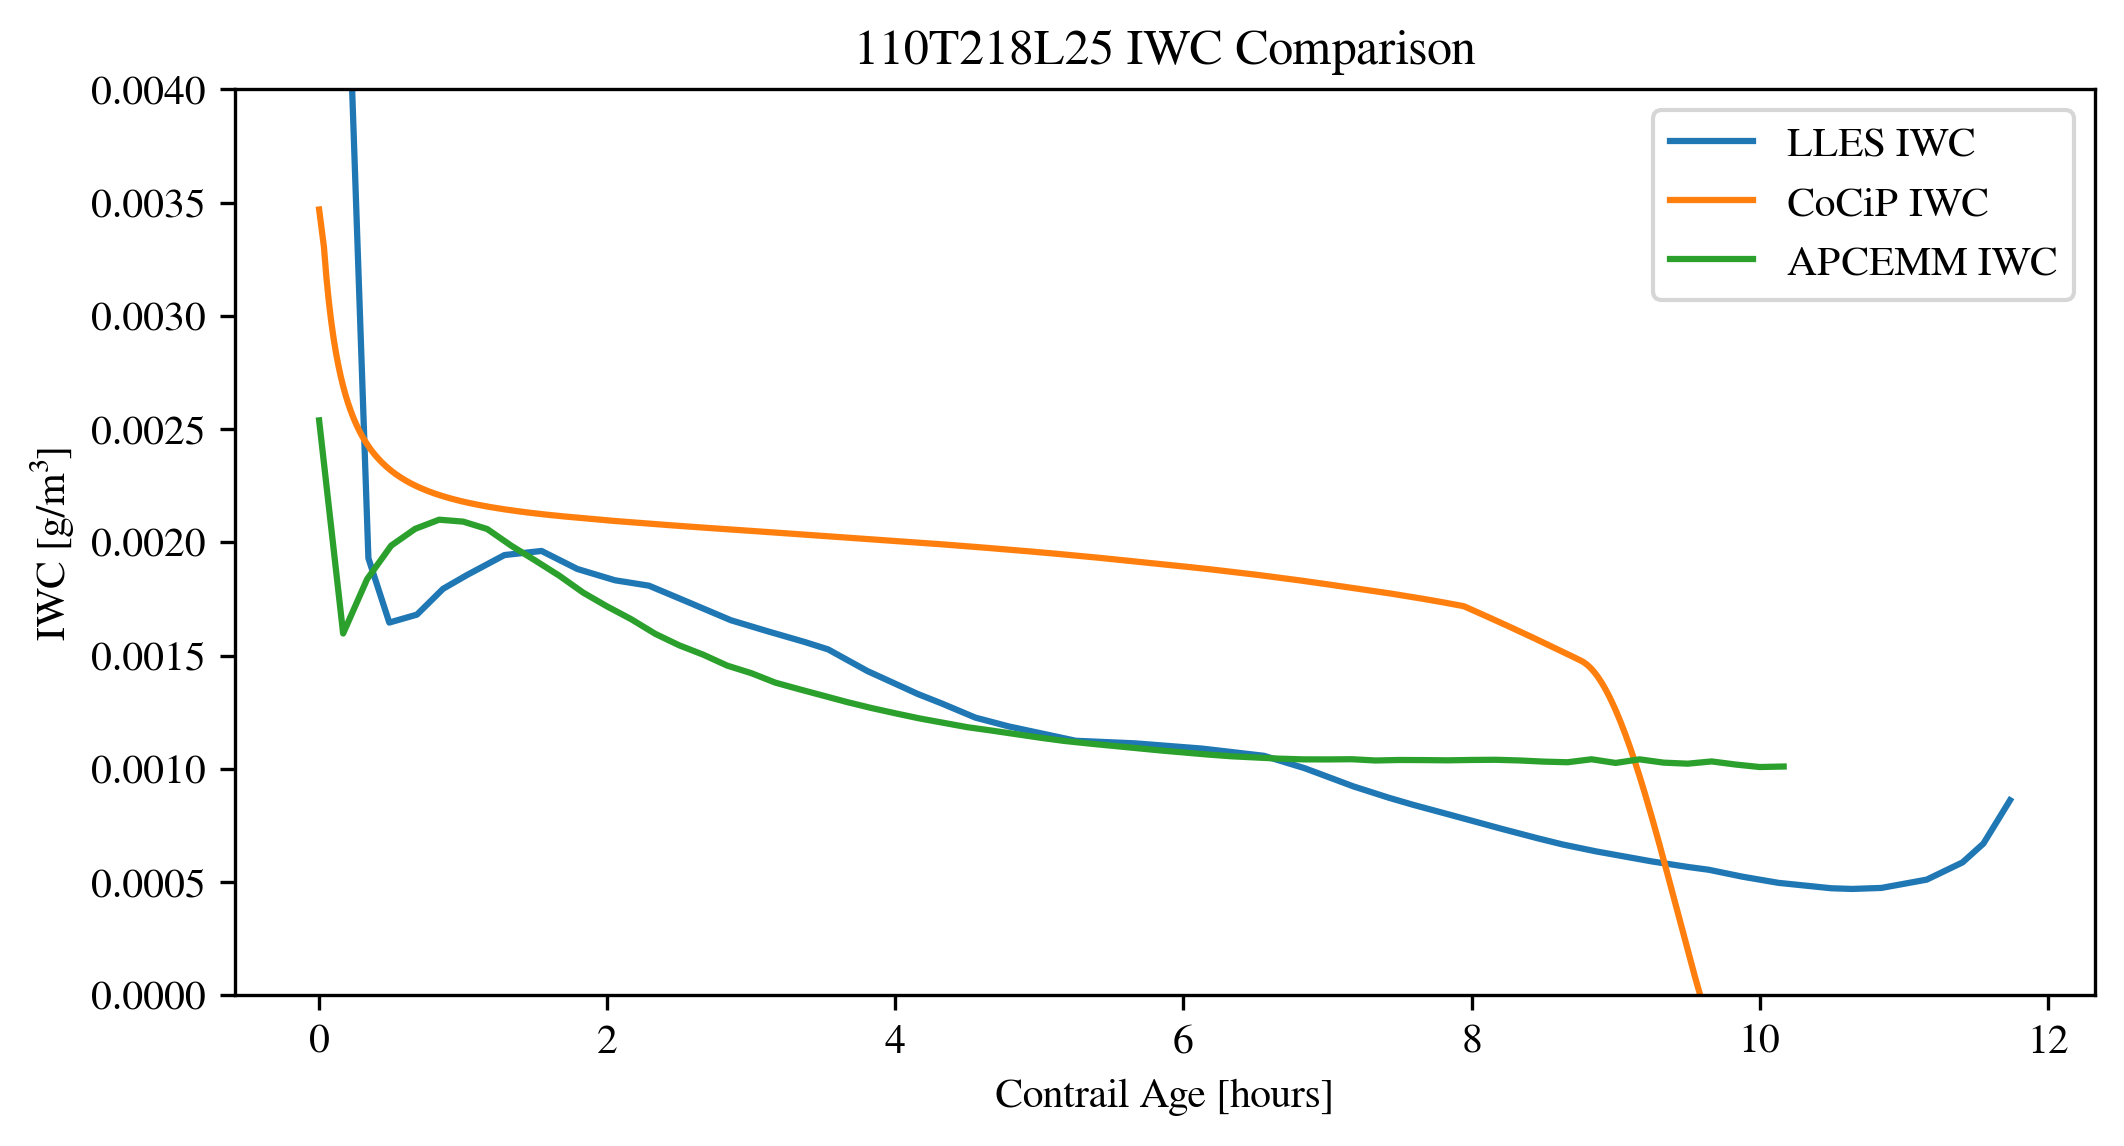

In [40]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
ax.plot(LLES_times, LLES_IWC*10, label="LLES IWC", color="tab:blue")
ax.plot(cocip_times, cocip_iwc, label="CoCiP IWC", color="tab:orange")
ax.plot(APCEMM_times, APCEMM_IWC_avg, label="APCEMM IWC", color="tab:green")
ax.set_title(f'{test_id} IWC Comparison')
ax.legend()
ax.set_xlabel("Contrail Age [hours]")
ax.set_ylabel("IWC [g/m³]")
ax.set_ylim(0, 0.004)